# Q1: Estimated need vs. food shelf activity

- **Part 1 (sections 1–7):** Do the two sets of numbers tell the same story?
- **Part 2 (sections 8–15):** Which food shelf metrics have stronger or weaker correlations with Feeding America's need estimates?
- **Part 3 (sections 16–25):** Which counties break the pattern?
- **Part 4 (sections 26–36):** What county characteristics might explain the mismatches?
- **Final Q1 synthesis (section 37)**

**MinneMUDAC 2026 · The Food Group**

## 1. Question / goal

Question 1 of the brief asks:

> *"Do these two sets of numbers tell the same story for the three food shelf metrics (e.g. Visits, Pounds distributed, and Individuals served)?"*

The **two sets of numbers** are:

| | Source | What it measures |
|---|---|---|
| **Need** | Feeding America *Map the Meal Gap* (MMG) | a **model estimate** of how many people in each county are food insecure |
| **Activity** | The Food Group food shelf reports (`org_FSStats`, cleaned) | what food shelves **actually recorded**: visits, pounds, individuals |

In plain words: **if Feeding America says a county has a lot of need, do food shelves there also see a lot of activity?**

"Telling the same story" does **not** mean the numbers are equal. They have different units (people vs. trips vs. pounds), so we never subtract one from the other. Instead we ask whether they **move together**: do the same counties rank high on both, and do both go up or down over time?

**Scope of Part 1.** Only the first part of Q1. In Part 1 we do **not**:
- formally decide which metric correlates most strongly with MMG (that is Part 2),
- name and investigate the counties where the relationship breaks down,
- explain mismatches with poverty, SNAP, vehicle access, etc.

Where we notice patterns that matter for those later steps, we note them and stop.

*Map the Meal Gap data: Feeding America, Map the Meal Gap 2025 and 2026 releases. Must be cited whenever used.*

## 2. Imports and paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

# Works whether the notebook is run from the repo root or from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED = ROOT / "Data" / "processed"
print(PROCESSED)

# One consistent look for every chart. Colors: one fixed color per metric, used everywhere.
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e6e5e0",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#8a8984",
    "axes.labelcolor": "#2b2b2b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "font.size": 10,
})
METRICS = ["visits", "pounds", "individuals"]
LABEL = {"visits": "Visits (household trips)", "pounds": "Pounds distributed", "individuals": "Individuals served"}
COLOR = {"visits": "#2a78d6", "pounds": "#eb6834", "individuals": "#1baf7a", "need": "#3d3d3a"}

C:\Users\eirfa\Documents\UW_Madison_Edu\MINNEMUDAC_2026\Data\processed


## 3. Load the data

We use the cleaned files in `Data/processed/` (see `Data/processed/README.md` and `docs/02_clean_foodshelf.md`). We read `fips` as text so codes like `27001` stay intact.

In [2]:
fs_month = pd.read_csv(PROCESSED / "foodshelf_county_month.csv", dtype={"fips": str}, parse_dates=["month"])
issues   = pd.read_csv(PROCESSED / "foodshelf_issues_log.csv")
mmg      = pd.read_csv(PROCESSED / "mmg_mn_county_2022_2024.csv", dtype={"fips": str})

for name, df in [("foodshelf_county_month", fs_month), ("foodshelf_issues_log", issues), ("mmg_mn_county_2022_2024", mmg)]:
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print("  columns:", list(df.columns), "\n")

foodshelf_county_month: 4,785 rows x 12 columns
  columns: ['fips', 'county', 'month', 'visits', 'pounds', 'individuals', 'adults', 'children', 'seniors', 'n_sites', 'n_sites_reported', 'n_sites_missing'] 

foodshelf_issues_log: 430 rows x 9 columns
  columns: ['site_id', 'year', 'month_num', 'county_original', 'visits', 'individuals', 'pounds', 'issue', 'action'] 

mmg_mn_county_2022_2024: 261 rows x 21 columns
  columns: ['fips', 'county', 'year', 'fi_rate', 'fi_persons', 'child_fi_rate', 'fi_children', 'fi_rate_black', 'fi_rate_hispanic', 'fi_rate_white_nh', 'snap_threshold', 'pct_fi_below_snap_threshold', 'pct_fi_above_snap_threshold', 'pct_fi_children_below_185fpl', 'pct_fi_children_above_185fpl', 'cost_per_meal', 'weekly_dollars_needed_per_fi', 'annual_food_budget_shortfall', 'rucc_2023', 'source_file', 'rural'] 



In [3]:
fs_month.head()

,fips,county,month,visits,pounds,individuals,adults,children,seniors,n_sites,n_sites_reported,n_sites_missing
0,27001,Aitkin,2022-01-01,222.0,11249.0,547.0,238.0,114.0,195.0,6,6,0
1,27001,Aitkin,2022-02-01,222.0,11249.0,547.0,238.0,114.0,195.0,6,6,0
2,27001,Aitkin,2022-03-01,234.0,12729.0,562.0,224.0,126.0,212.0,5,5,0
3,27001,Aitkin,2022-04-01,297.0,14382.0,597.0,221.0,140.0,236.0,5,5,0
4,27001,Aitkin,2022-05-01,236.0,13290.0,593.0,250.0,131.0,212.0,5,5,0


In [4]:
mmg.head()

,fips,county,year,fi_rate,fi_persons,child_fi_rate,fi_children,fi_rate_black,fi_rate_hispanic,fi_rate_white_nh,snap_threshold,pct_fi_below_snap_threshold,pct_fi_above_snap_threshold,pct_fi_children_below_185fpl,pct_fi_children_above_185fpl,cost_per_meal,weekly_dollars_needed_per_fi,annual_food_budget_shortfall,rucc_2023,source_file,rural
0,27001,Aitkin,2022,0.130,2060.0,0.199,510.0,NaN,NaN,0.100,2.0,0.754,0.246,0.76,0.24,4.37,27.07,1692000.0,8.0,MMG2025_2019-2023_Data_To_Share_v2.xlsx,True
1,27001,Aitkin,2023,0.137,2190.0,0.204,520.0,NaN,NaN,0.110,2.0,0.706,0.294,0.67,0.33,3.80,23.76,1579000.0,8.0,MMG2025_2019-2023_Data_To_Share_v2.xlsx,True
2,27001,Aitkin,2024,0.150,2420.0,0.220,550.0,NaN,NaN,0.110,2.0,0.740,0.260,0.68,0.32,3.86,24.15,1773000.0,8.0,MMG2026_2024_Data_To_Share.xlsx,True
3,27003,Anoka,2022,0.072,26300.0,0.126,10820.0,0.23,0.19,0.060,2.0,0.565,0.435,0.60,0.40,4.40,27.25,21743000.0,1.0,MMG2025_2019-2023_Data_To_Share_v2.xlsx,False
4,27003,Anoka,2023,0.085,31330.0,0.133,11620.0,0.27,0.22,0.068,2.0,0.540,0.460,0.63,0.37,3.83,23.96,22770000.0,1.0,MMG2025_2019-2023_Data_To_Share_v2.xlsx,False


In [5]:
issues.head()

,site_id,year,month_num,county_original,visits,individuals,pounds,issue,action
0,1148.0,2023,15,Polk,33.0,69.0,2043.0,invalid month number (0 or 15),removed
1,14810.0,2023,0,St. Louis,54.0,129.0,1785.0,invalid month number (0 or 15),removed
2,1072.0,2023,0,St. Louis,183.0,421.0,8778.0,invalid month number (0 or 15),removed
3,14717.0,2023,0,Carlton,332.0,755.0,11625.0,invalid month number (0 or 15),removed
4,1103.0,2023,0,St. Louis,274.0,691.0,12128.0,invalid month number (0 or 15),removed


We do **not** load `foodshelf_site_month.csv` here. The county-month file is built directly from it (summing sites, excluding meal programs), and every county-level number we need is already in it. Site-level detail will matter later when we look at individual mismatch counties.

### Population (denominator only)

To compare counties of very different size we need a population for each county-year. We take **only the `population` column** from the cleaned Census ACS file (`poverty_2022_2024_clean.csv`). We do **not** use any poverty rate in this notebook; that belongs to the later "explain the mismatches" step.

In [6]:
pop = (pd.read_csv(PROCESSED / "poverty_2022_2024_clean.csv", dtype={"county_geoid": str})
         .rename(columns={"county_geoid": "fips"})[["fips", "year", "population"]])
print(pop.shape)
pop.head()

(261, 3)


,fips,year,population
0,27001,2022,15627
1,27003,2022,360581
2,27005,2022,34515
3,27007,2022,44355
4,27009,2022,40545


## 4. Understand the variables

### What one row means

| File | One row = | Years |
|---|---|---|
| `foodshelf_county_month.csv` | one county × one month (all 87 counties, every month) | Jan 2022 – Jul 2026 |
| `mmg_mn_county_2022_2024.csv` | one county × one year | 2022, 2023, 2024 |

### Need measures (Feeding America)

| Column | Meaning | Use |
|---|---|---|
| `fi_persons` | estimated number of food-insecure people | compare with **total** activity |
| `fi_rate` | estimated share of residents who are food insecure | compare with activity **per resident** |

### Activity measures (The Food Group)

| Brief's name | Column | Unit | Comes from raw column |
|---|---|---|---|
| Visits | `visits` | household trips | `HouseholdsReg` |
| Pounds distributed | `pounds` | pounds of food | `PoundsReg` |
| Individuals served | `individuals` | people served (adults + children + seniors) | `IndividualsReg` |

Important: **`individuals` is not a count of unique people.** A person who visits every month is counted 12 times a year. So "individuals served" in a year can easily be larger than the number of food-insecure people, and that is not a contradiction.

In [7]:
# Quick check of years and coverage in each file
fs_month["year"] = fs_month["month"].dt.year
print("Food shelf months:", fs_month["month"].min().date(), "to", fs_month["month"].max().date())
print("Food shelf counties:", fs_month["fips"].nunique())
print(fs_month.groupby("year")["month"].nunique().rename("months per year").to_string(), "\n")
print("MMG years:", sorted(mmg["year"].unique()), "| counties:", mmg["fips"].nunique())
print(mmg.groupby("year")["source_file"].unique().to_string())

Food shelf months: 2022-01-01 to 2026-07-01
Food shelf counties: 87
year
2022    12
2023    12
2024    12
2025    12
2026     7 

MMG years: [2022, 2023, 2024] | counties: 87
year
2022    [MMG2025_2019-2023_Data_To_Share_v2.xlsx]
2023    [MMG2025_2019-2023_Data_To_Share_v2.xlsx]
2024            [MMG2026_2024_Data_To_Share.xlsx]


In [8]:
# Check that individuals = adults + children + seniors (documented in the cleaning notes)
diff = (fs_month["individuals"] - fs_month[["adults", "children", "seniors"]].sum(axis=1, min_count=1)).abs()
print("Rows where individuals != adults+children+seniors:", int((diff > 0.5).sum()))

Rows where individuals != adults+children+seniors: 1


### Known warnings that matter for this analysis

From `Data/processed/README.md`, `docs/02_clean_foodshelf.md` and the issues log:

1. **"Visits" definition is ambiguous.** We follow the brief (Visits = household trips, `HouseholdsReg`). But The Food Group's own published "visits" match `IndividualsReg` instead. The team has asked the organizers. Here this matters less, because we analyze both metrics anyway.
2. **Blank ≠ zero.** A blank month means no site in that county reported, not that nobody came.
3. **Wilkin County has no food shelf in the data** (`n_sites = 0` every month). It cannot be compared and is kept visible, not dropped silently.
4. **Typos were removed** (e.g. Waseca, Jul 2023: 273,385 households) and set to missing; some large-but-plausible outliers were **kept and flagged**.
5. **MMG 2024 comes from a different release** (MMG2026) than 2022–2023 (MMG2025). Feeding America sometimes revises methods between releases, so small year-to-year jumps in MMG may partly reflect method changes. (The README warns specifically that cost-per-meal/budget columns are not comparable across years; we do not use those.)
6. **MMG county numbers are model estimates**, not counts, and they don't add up to the state total.

In [9]:
issues.groupby(["issue", "action"]).size().rename("rows").sort_values(ascending=False).to_frame()

,,rows
issue,action,
more households than individuals,"flagged, kept",145
"county blank, not in Organization.xlsx either",removed,116
duplicate site-month: two different values,summed into one row,56
value >10x site median (not a clear typo),"flagged, kept",43
invalid month number (0 or 15),removed,26
county blank in org_FSStats,filled from Organization.xlsx,16
duplicate site-month: exact copy,removed copy,11
visits typo: >10x site median and more households than individuals,visits set to missing,7
duplicate site-month: blank copy of a reported row,removed blank copy,5


In [10]:
# How many issues fall in the years we will actually use (2022-2024)?
in_scope = issues[issues["year"].between(2022, 2024)]
print(f"{len(in_scope)} of {len(issues)} logged issues are in 2022-2024")
in_scope.groupby("action").size()

323 of 430 logged issues are in 2022-2024


action
filled from Organization.xlsx     12
flagged, kept                    109
removed                          134
removed blank copy                 3
removed copy                       9
summed into one row               52
visits set to missing              4
dtype: int64

## 5. Prepare comparable data

### 5a. Choose the years

MMG covers **2022, 2023, 2024**. Food shelf data covers 2022 through mid-2026. The only years where we have both are **2022–2024**, all with 12 full months of food shelf data. 2025 and 2026 are left out of this comparison.

### 5b. County × month → county × year

We **sum** the 12 months for each county-year. Along the way we count how complete each county-year's reporting is, so problems are visible rather than hidden:
- `months_reported`: months with any reported number (out of 12)
- `site_months` / `site_months_missing`: site-months that existed / that didn't send numbers

In [11]:
fs = fs_month[fs_month["year"].between(2022, 2024)].copy()

fs_year = (fs.groupby(["fips", "year"])
             .agg(county=("county", "first"),
                  visits=("visits", "sum"),
                  pounds=("pounds", "sum"),
                  individuals=("individuals", "sum"),
                  months_reported=("visits", lambda s: s.notna().sum()),
                  site_months=("n_sites", "sum"),
                  site_months_missing=("n_sites_missing", "sum"))
             .reset_index())

# pandas' sum() turns "all blank" into 0. A county with zero reported months must be MISSING, not zero.
no_data = fs_year["months_reported"] == 0
fs_year.loc[no_data, METRICS] = np.nan
fs_year["share_site_months_missing"] = fs_year["site_months_missing"] / fs_year["site_months"]

print(fs_year.shape)
fs_year.head()

(261, 10)


,fips,year,county,visits,pounds,individuals,months_reported,site_months,site_months_missing,share_site_months_missing
0,27001,2022,Aitkin,3403.0,185596.00,8041.0,12,73,1,0.013699
1,27001,2023,Aitkin,4501.0,220979.85,10692.0,12,92,1,0.010870
2,27001,2024,Aitkin,3971.0,216215.70,8633.0,12,59,1,0.016949
3,27003,2022,Anoka,160898.0,8124274.00,521833.0,12,138,0,0.000000
4,27003,2023,Anoka,203002.0,9372609.00,750958.0,12,156,1,0.006410


In [12]:
print("County-years with fewer than 12 reported months:")
fs_year.loc[fs_year["months_reported"] < 12, ["county", "year", "months_reported", "site_months", "site_months_missing"]]

County-years with fewer than 12 reported months:


,county,year,months_reported,site_months,site_months_missing
61,Douglas,2023,11,12,0
75,Grant,2022,9,23,14
224,Stevens,2024,9,12,3
249,Wilkin,2022,0,0,0
250,Wilkin,2023,0,0,0
251,Wilkin,2024,0,0,0


In [13]:
print("Share of site-months not reported, across county-years:")
print(fs_year["share_site_months_missing"].describe().round(3).to_string())
print("\nCounty-years with more than 10% of site-months missing:")
fs_year.loc[fs_year["share_site_months_missing"] > 0.10,
            ["county", "year", "months_reported", "site_months", "site_months_missing", "share_site_months_missing"]].round(2)

Share of site-months not reported, across county-years:
count    258.000
mean       0.011
std        0.050
min        0.000
25%        0.000
50%        0.000
75%        0.000
max        0.609

County-years with more than 10% of site-months missing:


,county,year,months_reported,site_months,site_months_missing,share_site_months_missing
9,Beltrami,2022,12,34,5,0.15
10,Beltrami,2023,12,60,18,0.30
11,Beltrami,2024,12,59,12,0.20
15,Big Stone,2022,12,15,3,0.20
75,Grant,2022,9,23,14,0.61
224,Stevens,2024,9,12,3,0.25


A handful of county-years have incomplete reporting, so their annual totals are **too low**. We do **not** fill them in (that would invent data). Instead we add an `incomplete` flag and, in section 6, check whether removing them changes the conclusions.

### 5c. Join with Map the Meal Gap and population

Join on `fips` + `year` (never on county names). We use an outer join with an indicator so nothing can be dropped silently.

In [14]:
df = mmg[["fips", "county", "year", "fi_rate", "fi_persons", "rural"]].merge(
    fs_year.drop(columns="county"), on=["fips", "year"], how="outer", indicator="merge_fs")
df = df.merge(pop, on=["fips", "year"], how="outer", indicator="merge_pop")

print("MMG <-> food shelf join:\n", df["merge_fs"].value_counts().to_string(), "\n")
print("... <-> population join:\n", df["merge_pop"].value_counts().to_string(), "\n")
print("Rows:", len(df), "| counties:", df["fips"].nunique(), "| years:", sorted(df["year"].unique()))
print("Rows per year:", df.groupby("year").size().to_dict())

MMG <-> food shelf join:
 merge_fs
both          261
left_only       0
right_only      0 

... <-> population join:
 merge_pop
both          261
left_only       0
right_only      0 

Rows: 261 | counties: 87 | years: [2022, 2023, 2024]
Rows per year: {2022: 87, 2023: 87, 2024: 87}


In [15]:
# Unmatched rows (should be none) and missing values
print("Unmatched rows:", int((df["merge_fs"] != "both").sum() + (df["merge_pop"] != "both").sum()))
df[["fi_rate", "fi_persons", "population"] + METRICS].isna().sum().rename("missing values").to_frame()

Unmatched rows: 0


,missing values
fi_rate,0
fi_persons,0
population,0
visits,3
pounds,3
individuals,3


In [16]:
df.loc[df["visits"].isna(), ["county", "year", "months_reported"]]

,county,year,months_reported
249,Wilkin,2022,0
250,Wilkin,2023,0
251,Wilkin,2024,0


All 261 county-years match on both joins. The only missing activity values are **Wilkin County** (no food shelf), which we keep in the table but which drops out of any comparison that needs activity.

**Sanity check on population.** MMG reports both `fi_persons` and `fi_rate`, so it implies its own population (`fi_persons / fi_rate`). It should be close to the Census population.

In [17]:
implied = df["fi_persons"] / df["fi_rate"]
print("MMG-implied population / Census population:")
print((implied / df["population"]).describe().round(3).to_string())

MMG-implied population / Census population:
count    261.000
mean       1.025
std        0.018
min        1.001
25%        1.014
50%        1.020
75%        1.028
max        1.128


They agree within a few percent (MMG uses a slightly different population vintage, and `fi_rate` is rounded), so the Census population is a reasonable denominator.

### 5d. Derived columns

To compare fairly we build two kinds of activity measures. Neither subtracts quantities with different units.

| Measure | Formula | Compared against | Question it answers |
|---|---|---|---|
| **Per 1,000 residents** | activity / population × 1,000 | `fi_rate` | Is food shelf use more *intense* where need is a bigger *share* of the population? |
| **Per food-insecure person** | activity / `fi_persons` | (description only) | How much recorded activity is there per estimated food-insecure person? |

Plus a flag `incomplete` = fewer than 12 reported months **or** more than 10% of site-months missing.

In [18]:
for m in METRICS:
    df[f"{m}_per_1k"] = df[m] / df["population"] * 1000
    df[f"{m}_per_fi"] = df[m] / df["fi_persons"]

df["incomplete"] = (df["months_reported"] < 12) | (df["share_site_months_missing"] > 0.10)
df = df.drop(columns=["merge_fs", "merge_pop"])

# The comparison set: every county-year that has food shelf activity
comp = df.dropna(subset=["visits"]).copy()
print("Comparison county-years:", len(comp), "| per year:", comp.groupby("year").size().to_dict())
print("Flagged incomplete:", int(comp["incomplete"].sum()))
comp[["county", "year", "fi_rate", "fi_persons", "population", "visits", "visits_per_1k", "visits_per_fi"]].head()

Comparison county-years: 258 | per year: {2022: 86, 2023: 86, 2024: 86}
Flagged incomplete: 7


,county,year,fi_rate,fi_persons,population,visits,visits_per_1k,visits_per_fi
0,Aitkin,2022,0.130,2060.0,15627,3403.0,217.764126,1.651942
1,Aitkin,2023,0.137,2190.0,15687,4501.0,286.925480,2.055251
2,Aitkin,2024,0.150,2420.0,15824,3971.0,250.947927,1.640909
3,Anoka,2022,0.072,26300.0,360581,160898.0,446.218741,6.117795
4,Anoka,2023,0.085,31330.0,363694,203002.0,558.167031,6.479477


## 6. Exploratory comparison

We look at the question from three angles, because "the same story" can mean different things:

1. **Over time (statewide):** do both go up together from 2022 to 2024?
2. **Across counties, by size:** do counties with *more* food-insecure people have *more* activity?
3. **Across counties, by intensity:** do counties where a *bigger share* of people are food insecure have *more activity per resident*?

**Why Spearman (rank) correlation.** County sizes range from a few thousand people to over a million (Hennepin), and a few counties are far from the rest. Spearman's ρ compares **ranks**, so one huge county can't dominate it. ρ = 1 means identical ordering, 0 means no relationship. We compute it **separately for each year** rather than pooling years, because the same county appearing three times is not three independent observations.

### 6.1 Statewide trend: does everything go up together?

We sum all counties per year and index each series to 2022 = 100, so trips, pounds and people can share one axis without implying equal units. (MMG county numbers don't exactly sum to the state's official total, so the MMG line is a county-sum approximation.)

In [19]:
state = comp.groupby("year")[["fi_persons"] + METRICS].sum()
state_idx = state / state.loc[2022] * 100
display(state.style.format("{:,.0f}"))
display(state_idx.round(1))

,fi_persons,visits,pounds,individuals
year,,,,
2022,"508,730","1,963,236","118,672,911","5,626,130"
2023,"580,480","2,482,146","139,985,146","7,625,430"
2024,"635,800","2,862,391","155,558,493","8,994,350"


,fi_persons,visits,pounds,individuals
year,,,,
2022,100.0,100.0,100.0,100.0
2023,114.1,126.4,118.0,135.5
2024,125.0,145.8,131.1,159.9


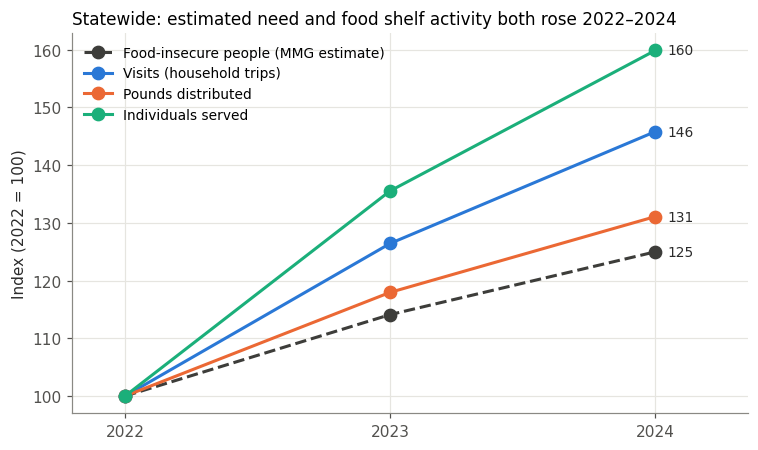

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.2))
years = state_idx.index
ax.plot(years, state_idx["fi_persons"], color=COLOR["need"], lw=2, ls="--", marker="o", ms=8,
        label="Food-insecure people (MMG estimate)")
for m in METRICS:
    ax.plot(years, state_idx[m], color=COLOR[m], lw=2, marker="o", ms=8, label=LABEL[m])
for col, color in [("fi_persons", COLOR["need"])] + [(m, COLOR[m]) for m in METRICS]:
    ax.annotate(f"{state_idx.loc[2024, col]:.0f}", (2024, state_idx.loc[2024, col]),
                xytext=(8, 0), textcoords="offset points", va="center", color="#2b2b2b", fontsize=9)
ax.set_xticks(years)
ax.set_xlim(2021.8, 2024.35)
ax.set_ylabel("Index (2022 = 100)")
ax.set_title("Statewide: estimated need and food shelf activity both rose 2022–2024", loc="left", fontsize=11)
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

**Reading the chart.** Statewide, both stories point the same way: estimated food insecurity rose about 25% from 2022 to 2024, and every food shelf metric rose too. But food shelf activity grew **faster** than estimated need, especially individuals served (~60%). So the *direction* agrees; the *size* of the change does not.

### 6.2 Across counties, by size: totals vs. food-insecure people

Plotted on log scales because counties differ in size by a factor of several hundred. One dot = one county in 2024.

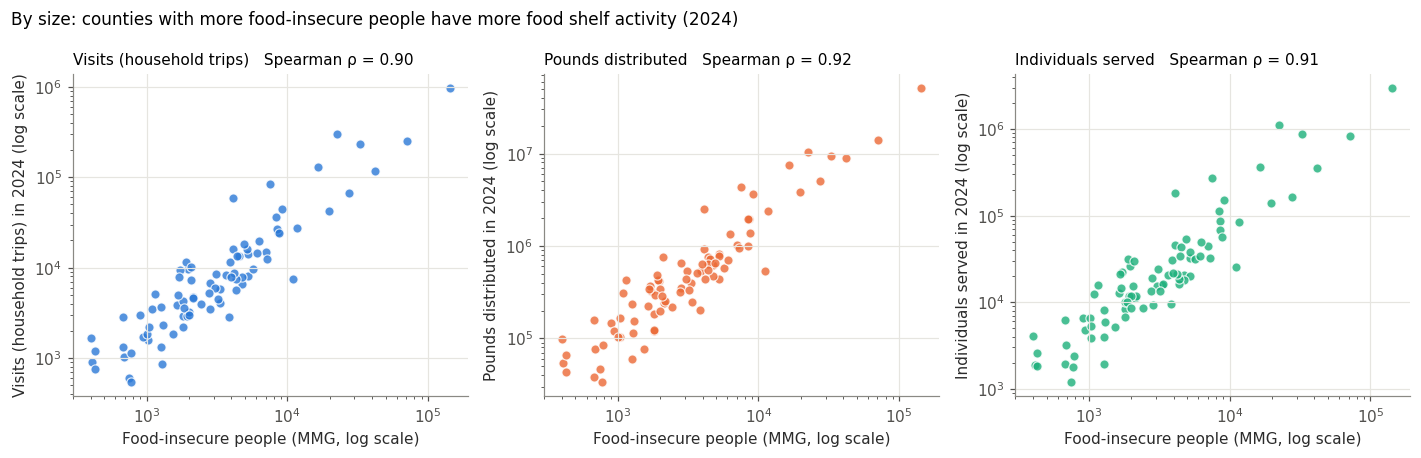

In [21]:
YEAR = 2024
d = comp[comp["year"] == YEAR]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, m in zip(axes, METRICS):
    rho = d["fi_persons"].corr(d[m], method="spearman")
    ax.scatter(d["fi_persons"], d[m], s=36, color=COLOR[m], alpha=0.8, edgecolor="white", linewidth=0.8)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Food-insecure people (MMG, log scale)")
    ax.set_ylabel(f"{LABEL[m]} in {YEAR} (log scale)")
    ax.set_title(f"{LABEL[m]}   Spearman ρ = {rho:.2f}", loc="left", fontsize=10)
fig.suptitle(f"By size: counties with more food-insecure people have more food shelf activity ({YEAR})",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

A strong relationship. But there is a catch: **big counties have more of everything**. Food-insecure people, food shelf visits, and simply residents all scale with population. So a high correlation here might only mean "big counties are big".

A quick test: how well does **plain population** (with no information about food insecurity) rank counties by activity, compared with MMG's food-insecure count?

In [22]:
rows = []
for year, g in comp.groupby("year"):
    for m in METRICS:
        rows.append({"year": year, "metric": m,
                     "rho with fi_persons (MMG)": g["fi_persons"].corr(g[m], method="spearman"),
                     "rho with population only": g["population"].corr(g[m], method="spearman")})
size_tbl = pd.DataFrame(rows).set_index(["year", "metric"]).round(2)
for year, g in comp.groupby("year"):
    print(f"{year}: Spearman rho between fi_persons and population = {g['fi_persons'].corr(g['population'], method='spearman'):.3f}")
size_tbl

2022: Spearman rho between fi_persons and population = 0.991
2023: Spearman rho between fi_persons and population = 0.994
2024: Spearman rho between fi_persons and population = 0.991


rho with fi_persons (MMG)  rho with population only
year metric                                                          
2022 visits                            0.89                      0.88
     pounds                            0.92                      0.91
     individuals                       0.90                      0.89
2023 visits                            0.89                      0.89
     pounds                            0.91                      0.91
     individuals                       0.89                      0.89
2024 visits                            0.90                      0.91
     pounds                            0.92                      0.92
     individuals                       0.91                      0.91

`fi_persons` and population are almost perfectly ranked together (ρ ≈ 0.99), and population alone ranks counties' activity just about as well as MMG does. So the "by size" agreement is real but mostly tells us about **county size**, not about **need**. To learn whether MMG's need signal itself lines up with food shelf use, we need to take size out.

### 6.3 Across counties, by intensity: food-insecurity rate vs. activity per resident

Now both sides are per-person: `fi_rate` (share of residents food insecure) vs. activity per 1,000 residents.

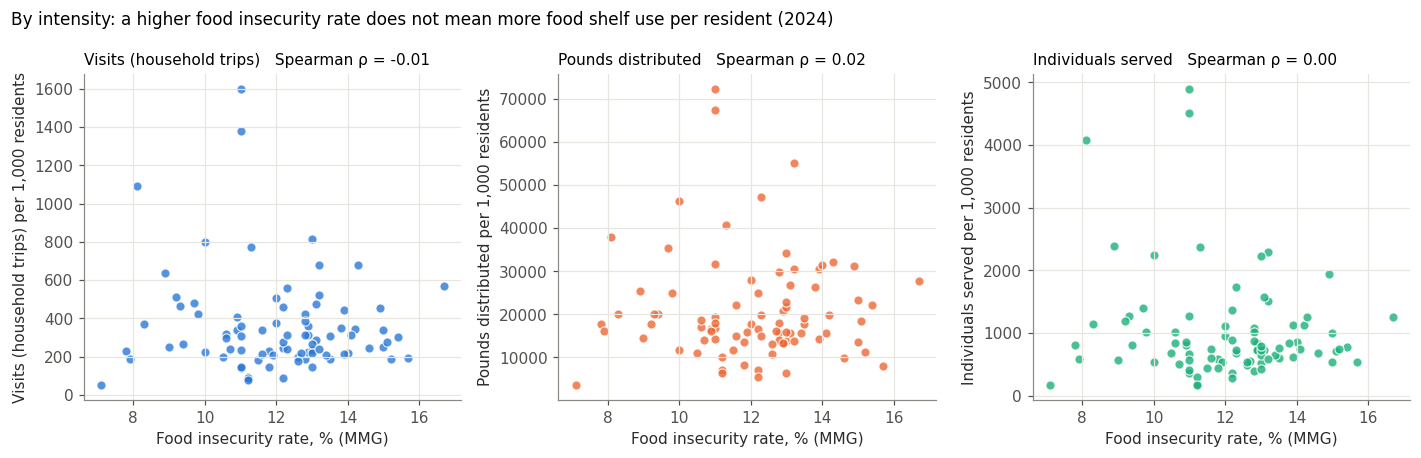

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, m in zip(axes, METRICS):
    col = f"{m}_per_1k"
    rho = d["fi_rate"].corr(d[col], method="spearman")
    ax.scatter(d["fi_rate"] * 100, d[col], s=36, color=COLOR[m], alpha=0.8, edgecolor="white", linewidth=0.8)
    ax.set_xlabel("Food insecurity rate, % (MMG)")
    ax.set_ylabel(f"{LABEL[m]} per 1,000 residents")
    ax.set_title(f"{LABEL[m]}   Spearman ρ = {rho:.2f}", loc="left", fontsize=10)
fig.suptitle(f"By intensity: a higher food insecurity rate does not mean more food shelf use per resident ({YEAR})",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

In [24]:
rows = []
for year, g in comp.groupby("year"):
    for m in METRICS:
        rows.append({"year": year, "metric": m,
                     "rho (fi_rate vs per 1k), all counties": g["fi_rate"].corr(g[f"{m}_per_1k"], method="spearman"),
                     "rho, complete-reporting counties only": g.loc[~g["incomplete"], "fi_rate"].corr(
                         g.loc[~g["incomplete"], f"{m}_per_1k"], method="spearman"),
                     "n (complete only)": int((~g["incomplete"]).sum())})
rate_tbl = pd.DataFrame(rows).set_index(["year", "metric"]).round(2)
rate_tbl

rho (fi_rate vs per 1k), all counties  rho, complete-reporting counties only  n (complete only)
year metric                                                                                                      
2022 visits                                        0.12                                   0.12                 83
     pounds                                        0.20                                   0.20                 83
     individuals                                   0.10                                   0.10                 83
2023 visits                                        0.08                                   0.06                 84
     pounds                                        0.09                                   0.08                 84
     individuals                                   0.06                                   0.03                 84
2024 visits                                       -0.01                                  -0.01                 84
     pounds                                        0.02                                   0.01                 84
     individuals                                   0.00                                  -0.00                 84

Once county size is removed, the relationship is **weak to nonexistent in every year and for every metric** (ρ between about −0.01 and +0.20, and essentially 0 by 2024). Removing the counties with incomplete reporting doesn't change this, so it isn't caused by missing reports.

How big is "close to zero"? With 86 counties, a ρ smaller than about ±0.21 is the kind of value you'd often get by chance alone even if there were no real relationship. These values are all near or inside that range.

### 6.4 Rank agreement: do the same counties land in the same group?

A more intuitive view of the same question: split counties into **five equal groups (quintiles)** by need rate and by activity per resident, then count how often a county lands in the same group on both. If the two measures agreed perfectly, all counties would sit on the diagonal. If they were unrelated, about **20%** would match exactly by chance and about **52%** would be within one group.

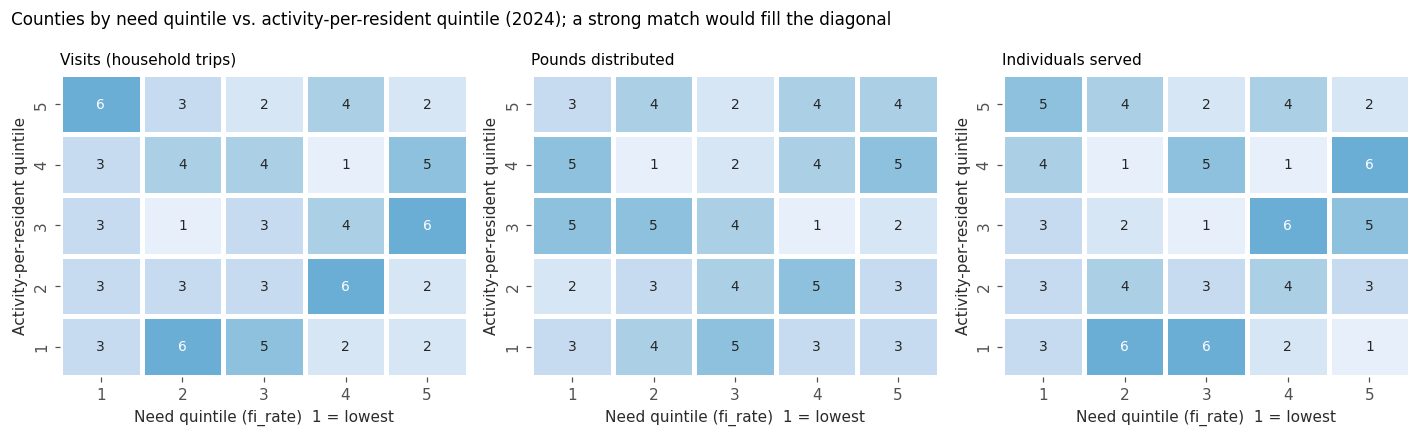

,same quintile,within one quintile
metric,,
visits,14.0,49.0
pounds,21.0,52.0
individuals,13.0,53.0


In [25]:
def quintile(s):
    return pd.qcut(s.rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
agree_rows = []
for ax, m in zip(axes, METRICS):
    q_need = quintile(d["fi_rate"])
    q_act = quintile(d[f"{m}_per_1k"])
    tab = pd.crosstab(q_act, q_need).reindex(index=[5, 4, 3, 2, 1], columns=[1, 2, 3, 4, 5], fill_value=0)
    sns.heatmap(tab, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax, linewidths=2, linecolor="white",
                vmin=0, vmax=12, annot_kws={"fontsize": 9})
    ax.grid(False)
    ax.set_xlabel("Need quintile (fi_rate)  1 = lowest")
    ax.set_ylabel("Activity-per-resident quintile")
    ax.set_title(LABEL[m], loc="left", fontsize=10)
    agree_rows.append({"metric": m,
                       "same quintile": (q_need == q_act).mean(),
                       "within one quintile": ((q_need - q_act).abs() <= 1).mean()})
fig.suptitle(f"Counties by need quintile vs. activity-per-resident quintile ({YEAR}); a strong match would fill the diagonal",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

(pd.DataFrame(agree_rows).set_index("metric") * 100).round(0)  # percent of counties

The counts are spread across the whole grid instead of sitting on the diagonal, and agreement is close to the chance levels (20% / 52%). In terms of **which counties have more need per person**, MMG and food shelf activity rank counties very differently.

### 6.5 Change over time, county by county

Statewide both went up (6.1). Do the counties where need **grew most** also show activity growing most? We compare the % change from 2022 to 2024 in `fi_rate` with the % change in activity per resident. (Grant 2022 is incomplete and inflates Grant's growth; we exclude counties that are flagged incomplete in either year.)

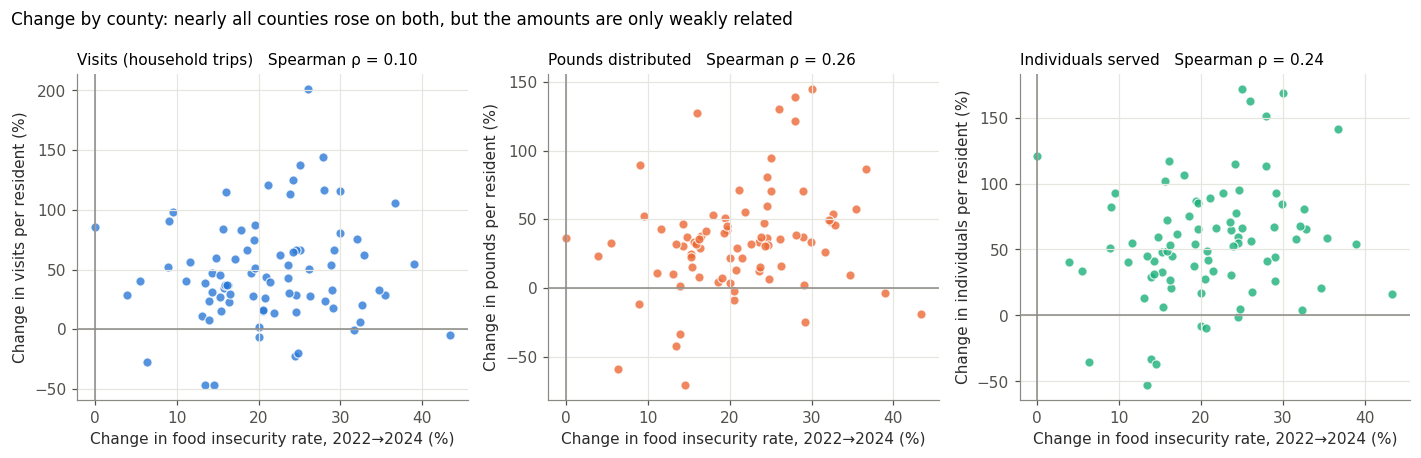

,value
counties,82.000000
share where MMG rate rose,0.987805
share where visits/resident rose,0.902439
share where pounds/resident rose,0.878049
share where individuals/resident rose,0.914634


In [26]:
wide = comp.pivot(index="fips", columns="year",
                  values=["fi_rate"] + [f"{m}_per_1k" for m in METRICS] + ["incomplete"])
keep = ~(wide["incomplete"][2022].astype(bool) | wide["incomplete"][2024].astype(bool))
wide = wide[keep]
chg = pd.DataFrame({"fi_rate": (wide["fi_rate"][2024] / wide["fi_rate"][2022] - 1) * 100})
for m in METRICS:
    chg[m] = (wide[f"{m}_per_1k"][2024] / wide[f"{m}_per_1k"][2022] - 1) * 100

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True)
for ax, m in zip(axes, METRICS):
    rho = chg["fi_rate"].corr(chg[m], method="spearman")
    ax.axhline(0, color="#8a8984", lw=1); ax.axvline(0, color="#8a8984", lw=1)
    ax.scatter(chg["fi_rate"], chg[m], s=36, color=COLOR[m], alpha=0.8, edgecolor="white", linewidth=0.8)
    ax.set_xlabel("Change in food insecurity rate, 2022→2024 (%)")
    ax.set_ylabel(f"Change in {m} per resident (%)")
    ax.set_title(f"{LABEL[m]}   Spearman ρ = {rho:.2f}", loc="left", fontsize=10)
fig.suptitle("Change by county: nearly all counties rose on both, but the amounts are only weakly related", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    "counties": len(chg),
    "share where MMG rate rose": [(chg["fi_rate"] > 0).mean()],
    **{f"share where {m}/resident rose": [(chg[m] > 0).mean()] for m in METRICS},
}).T.rename(columns={0: "value"})
summary

Almost every county saw **both** a rise in estimated food insecurity and a rise in food shelf use per resident, so the direction is shared everywhere. But *how much* each county changed on one side says little about how much it changed on the other: the correlations are weak (ρ ≈ 0.1–0.26), with a lot of scatter.

### 6.6 How much activity is there per food-insecure person?

This ratio is **not** a "gap" or a coverage rate (individuals are repeat counts, and people may use food shelves outside their home county). It is just a way to see how unevenly activity is spread relative to estimated need. If the two datasets told exactly the same story, this ratio would be roughly the same in every county.

In [27]:
ratio_cols = [f"{m}_per_fi" for m in METRICS]
print("Activity per estimated food-insecure person (all comparison county-years):")
display(comp.groupby("year")[ratio_cols].median().round(1).rename(columns=lambda c: "median " + c))
display(comp[ratio_cols].describe(percentiles=[0.1, 0.5, 0.9]).round(1))

Activity per estimated food-insecure person (all comparison county-years):


,median visits_per_fi,median pounds_per_fi,median individuals_per_fi
year,,,
2022,2.0,133.8,4.9
2023,2.3,151.9,5.8
2024,2.2,144.3,6.0


,visits_per_fi,pounds_per_fi,individuals_per_fi
count,258.0,258.0,258.0
mean,2.8,170.1,7.8
std,2.1,99.2,7.0
min,0.5,34.9,1.3
10%,1.1,73.8,3.1
50%,2.2,139.3,5.6
90%,5.1,305.8,14.1
max,14.4,606.9,49.7


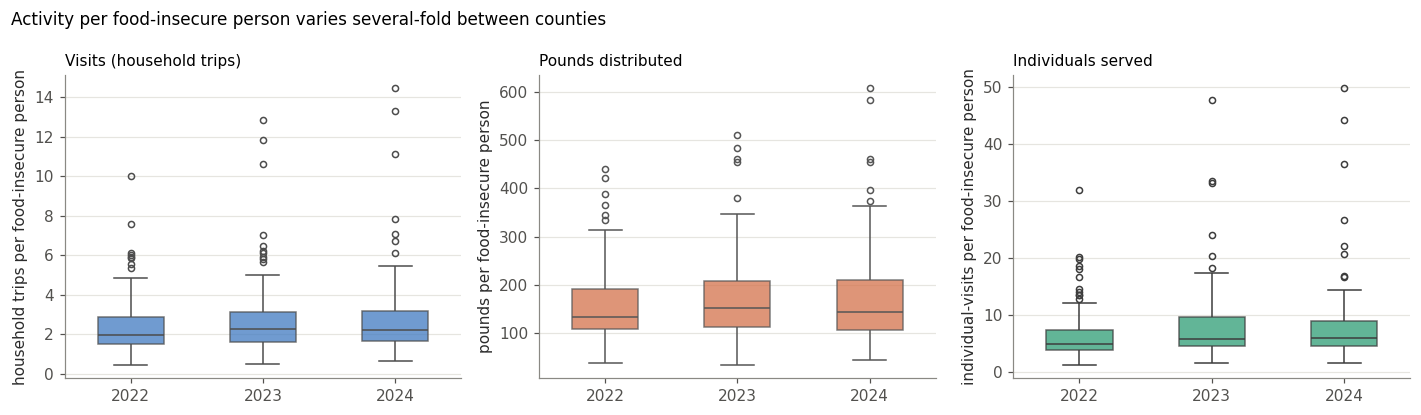

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
units = {"visits": "household trips", "pounds": "pounds", "individuals": "individual-visits"}
for ax, m in zip(axes, METRICS):
    sns.boxplot(data=comp, x="year", y=f"{m}_per_fi", ax=ax, color=COLOR[m], width=0.5,
                fliersize=4, linewidth=1, boxprops={"alpha": 0.75})
    ax.set_xlabel("")
    ax.set_ylabel(f"{units[m]} per food-insecure person")
    ax.set_title(LABEL[m], loc="left", fontsize=10)
fig.suptitle("Activity per food-insecure person varies several-fold between counties", x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

In [29]:
spread = comp.groupby("year")[ratio_cols].quantile(0.9) / comp.groupby("year")[ratio_cols].quantile(0.1)
print("Ratio of 90th to 10th percentile county, by year:")
spread.round(1)

Ratio of 90th to 10th percentile county, by year:


,visits_per_fi,pounds_per_fi,individuals_per_fi
year,,,
2022,4.7,3.7,5.0
2023,4.6,4.1,4.6
2024,4.0,4.0,4.3


In a typical county there are about 2 household visits (and ~140 pounds) per estimated food-insecure person per year, but the **90th-percentile county has roughly 4–5× as much as the 10th-percentile county**, and a few counties sit far above the rest. A spread that large is the per-county version of what 6.3 showed.

### 6.7 Do the three food shelf metrics agree with each other?

Before the next part of Q1 compares each metric to MMG in detail, it helps to know whether the three metrics are even telling the same story **among themselves**.

In [30]:
per1k = [f"{m}_per_1k" for m in METRICS]
inter = comp.groupby("year")[per1k].corr(method="spearman").round(2)
inter

visits_per_1k  pounds_per_1k  individuals_per_1k
year                                                                     
2022 visits_per_1k                1.00           0.79                0.91
     pounds_per_1k                0.79           1.00                0.84
     individuals_per_1k           0.91           0.84                1.00
2023 visits_per_1k                1.00           0.85                0.96
     pounds_per_1k                0.85           1.00                0.87
     individuals_per_1k           0.96           0.87                1.00
2024 visits_per_1k                1.00           0.79                0.92
     pounds_per_1k                0.79           1.00                0.85
     individuals_per_1k           0.92           0.85                1.00

The three metrics agree closely with each other (ρ ≈ 0.8–0.95 per resident): a county busy on visits is usually busy on individuals and pounds too. Pounds agrees a bit less with the head-count metrics, which is expected since pounds per visit can vary by food shelf and food bank. So the three metrics tell **one shared story** of food shelf activity, and it is that shared story that differs from MMG's.

### 6.8 Is the result sensitive to the "Visits" definition or to a single year?

- **Visits definition:** we analyzed both `visits` (households) and `individuals`. They give the same answer, so the unresolved definition question doesn't change this conclusion.
- **Year:** the per-resident correlations in 6.3 are small in all three years.
- **Incomplete reporting:** excluding flagged county-years does not change the conclusion (6.3 table).

## 7. Initial findings

**Short answer: partly.** The two datasets tell the same story about **size** and **direction over time**, but **not** about **where need is most intense**.

1. **Do higher-need counties show higher food shelf activity?**
   *In absolute terms, yes.* Counties with more estimated food-insecure people have more visits, pounds and individuals (Spearman ρ ≈ 0.9 every year). But this is mostly a population effect: population alone ranks counties just as well, and MMG's food-insecure count is almost a fixed share of population.

2. **Once county size is removed, the relationship is weak to nonexistent.** Counties with a higher food insecurity *rate* do **not** have noticeably more food shelf activity *per resident* (ρ between about −0.01 and +0.20, essentially zero by 2024). Need quintiles and activity quintiles match about as often as chance would predict.

3. **Over time, the direction agrees, the size of change does not.** Statewide, estimated food insecurity rose about 25% from 2022 to 2024 while food shelf visits rose ~46%, pounds ~31% and individuals ~60%. Nearly every county rose on both, but the counties with the largest increase in need are only weakly the ones with the largest increase in activity (ρ ≈ 0.1–0.26).

4. **All three metrics tell roughly the same story as each other** (they correlate ~0.8–0.96 per resident) and all three relate to MMG in the same way. Pounds is the least tightly linked to the other two. Which metric tracks MMG *best* is left for the next part of Q1.

5. **Activity relative to need is very uneven.** The 90th-percentile county records about 4–5× more activity per estimated food-insecure person than the 10th-percentile county, and a few are far outliers.

**Overall:** "big counties have more need and more food shelf use" and "need and food shelf use both rose" are true. "Counties where food insecurity is most concentrated are where food shelves are busiest per person" is **not** supported by these data. This is a description of patterns, not a causal claim.

### Things to investigate later (not done here)

- **Which counties break the pattern**, in both directions (lots of activity relative to need, and little activity relative to need). The quintile grid and the per-food-insecure-person ratio make good starting points.
- **Possible reasons the per-person story differs**, e.g.:
  - people crossing county lines to regional food shelf hubs (activity is recorded where the food shelf is, need where people live);
  - access barriers (distance, no vehicle) holding down use in some high-need counties;
  - differences in food shelf supply and capacity, which can drive recorded activity regardless of need;
  - MMG being a model estimate built from county economic indicators, so it may not capture local differences that food shelves see;
  - SNAP coverage and poverty levels (planned for the "explain mismatches" step).
- **Why activity grew faster than estimated need** (e.g. the end of COVID emergency SNAP benefits in early 2023, food price inflation, more people using food shelves who MMG doesn't classify as food insecure). These are hypotheses to test, not findings.

### Data caveats and assumptions

- Only 2022–2024 are compared (the years both datasets cover).
- "Visits" = household trips (`HouseholdsReg`) per the brief; The Food Group's published visits match `IndividualsReg`. Organizers have been asked. Our conclusion holds under either definition.
- `individuals` counts repeat visits, so it can't be compared numerically with `fi_persons`.
- Wilkin County has no food shelf in the data and is excluded from correlations (it is still in the merged table).
- Three county-years have fewer than 12 months reported, and a few have >10% of site-months missing. Totals there are understated. They were flagged, not imputed, and the conclusions are unchanged without them.
- Activity is assigned to the county where the food shelf is located, not where clients live.
- MMG 2024 comes from a newer release than 2022–2023. Small changes between years may partly reflect method revisions.
- Population comes from Census ACS 5-year estimates (only the population column was used).

---

# Part 2: Which metrics have stronger or weaker correlations with Feeding America's need estimates?

Part 1 found that the three food shelf metrics broadly tell one shared story, and that this story matches MMG on **county size** but not on **need per resident**. Now we compare the three metrics directly:

1. How strongly is estimated need associated with **Visits**, **Pounds distributed**, and **Individuals served**?
2. Which relationship is **strongest**, and which is **weakest**?
3. Are the results **consistent across 2022, 2023 and 2024**?

We reuse the merged county-year table `comp` from section 5 (86 counties × 3 years, Wilkin excluded because it has no food shelf). No new data is loaded.

**Still out of scope:** ranking mismatch counties, explaining why particular counties break the pattern, and using poverty / SNAP / vehicle data. Where a single county strongly affects a correlation we **name it and keep it**, and leave the "why" for the next step.

## 8. What exactly are we correlating?

### 8a. Which Feeding America measure?

The MMG file has several columns. Only two describe overall need in a way that matches what food shelves record:

| MMG column | Used? | Why |
|---|---|---|
| `fi_persons` (food-insecure people) | **Yes**, for totals | Same "how much in this county" scale as total visits / pounds / individuals |
| `fi_rate` (share of residents food insecure) | **Yes**, for per-resident comparisons | Already size-free, so it pairs with activity per resident |
| `child_fi_rate`, `fi_children` | No | Children only; the food shelf metrics cover all ages |
| `pct_fi_above/below_snap_threshold` | No | Describes *who* is food insecure (SNAP eligibility), not *how much* need. Relevant to the later explanation step |
| `cost_per_meal`, budget shortfall | No | README: not comparable across years (method changed in 2023) |
| `fi_rate_black`, `fi_rate_hispanic` | No | Mostly blank (suppressed for small groups) |

### 8b. Totals, rates, or both? (the county-size problem)

Big counties have more of *everything*: more residents, more food-insecure people, more visits, more pounds. Part 1 (section 6.2) showed that `fi_persons` and population rank counties almost identically (ρ ≈ 0.99), and that **population alone** ranks food shelf activity as well as MMG does. So a high correlation between **totals** mostly measures county size.

We therefore report **both** levels, but they answer different questions:

| Level | Need | Activity | Question it answers | Role |
|---|---|---|---|---|
| **A. Totals** | `fi_persons` | annual `visits`, `pounds`, `individuals` | Do counties with more food-insecure people have more activity? | context (mostly size) |
| **B. Per resident** | `fi_rate` | activity per 1,000 residents | Where a bigger *share* of people is food insecure, is food shelf use more *intense*? | **main comparison** |

**Which metric is "strongest" is judged mainly on level B**, because level A would mostly be telling us which metric tracks population best.

### 8c. Which population denominator?

For "per 1,000 residents" we use **`population` from `poverty_2022_2024_clean.csv`** (Census ACS 5-year, table S1701), already loaded in section 3. Only that one column is used; no poverty rates enter the analysis. Reasons:

- It is the population column documented in `Data/processed/README.md` as suitable for per-person rates, and it covers all 87 counties × 2022–2024 with no gaps.
- It is joined by FIPS (`county_geoid` → `fips`), and matched 261/261 rows in section 5c.
- **Why not MMG's own implied population** (`fi_persons / fi_rate`)? It agrees with ACS within ~2% (section 5c), but it is *derived from the need estimate itself*. Dividing activity by it would put MMG's numbers on both sides of the correlation. An independent denominator is cleaner.
- Caveat: ACS `year` is the end of a 5-year window (2024 = 2020–2024 data), so population changes slowly. That is fine for a denominator; county populations change little in three years.

### 8d. Pearson and Spearman: why both

- **Pearson's r** asks: *do the points fall close to a straight line?* It uses the actual values, so a few extreme counties can pull it up or down a lot.
- **Spearman's ρ** asks: *do counties keep roughly the same ranking on both measures?* It only uses ranks, so one extreme county cannot dominate it.

Both run from −1 to +1 (0 = no relationship). If they agree, the result is solid. If they disagree, that is a sign a few unusual counties are driving Pearson, and we check which ones (section 13).

We calculate correlations **separately for each year** (86 counties each) instead of pooling all three years. Pooling would count each county three times as if it were three independent counties, which overstates certainty. Comparing the three years side by side also answers question 3 directly.

## 9. Validation before correlating

Checks on the exact rows and columns that go into the correlations.

In [31]:
used_cols = ["fi_persons", "fi_rate", "population"] + METRICS + [f"{m}_per_1k" for m in METRICS]

print("Years:", sorted(comp["year"].unique()))
print("Counties per year:", comp.groupby("year")["fips"].nunique().to_dict())
print("Duplicate county-year rows:", int(comp.duplicated(["fips", "year"]).sum()))
print("Counties in merged table but not in the comparison:",
      sorted(set(df["county"]) - set(comp["county"])))
print("\nMissing values in the columns we correlate:")
print(comp[used_cols].isna().sum().to_string())
print("\nCounty-years with zero recorded activity:", int((comp[METRICS] == 0).any(axis=1).sum()))

Years: [2022, 2023, 2024]
Counties per year: {2022: 86, 2023: 86, 2024: 86}
Duplicate county-year rows: 0
Counties in merged table but not in the comparison: ['Wilkin']

Missing values in the columns we correlate:
fi_persons            0
fi_rate               0
population            0
visits                0
pounds                0
individuals           0
visits_per_1k         0
pounds_per_1k         0
individuals_per_1k    0

County-years with zero recorded activity: 0


In [32]:
# County-years whose annual totals are understated because of missing reports (flag built in section 5d)
comp.loc[comp["incomplete"], ["county", "year", "months_reported", "site_months", "site_months_missing",
                              "share_site_months_missing"]].round(2)

,county,year,months_reported,site_months,site_months_missing,share_site_months_missing
9,Beltrami,2022,12,34,5,0.15
10,Beltrami,2023,12,60,18,0.30
11,Beltrami,2024,12,59,12,0.20
15,Big Stone,2022,12,15,3,0.20
61,Douglas,2023,11,12,0,0.00
75,Grant,2022,9,23,14,0.61
224,Stevens,2024,9,12,3,0.25


- 3 years × 86 counties, no duplicates, no missing values in any column we use.
- **Wilkin** is the only county left out, because it has no food shelf (blank activity, which is not the same as zero activity). Its absence is a finding for the next step, not a data error.
- **7 county-years are flagged incomplete.** Their totals are too low because some sites didn't report. We keep them in the main results (no imputation) and re-run without them in section 14 to check they don't change the answer.

## 10. Correlations, year by year

One function computes Pearson and Spearman (with p-values) for every level × year × metric. We reuse it later for the sensitivity check.

In [33]:
from scipy import stats

# level name -> (need column, activity column pattern)
LEVELS = {
    "Totals":       ("fi_persons", "{m}"),
    "Per resident": ("fi_rate",    "{m}_per_1k"),
}
NICE = {"visits": "Visits", "pounds": "Pounds", "individuals": "Individuals"}


def correlate(data):
    rows = []
    for year, g in data.groupby("year"):
        for level, (need_col, pattern) in LEVELS.items():
            for m in METRICS:
                act_col = pattern.format(m=m)
                pearson_r, pearson_p = stats.pearsonr(g[need_col], g[act_col])
                spearman_r, spearman_p = stats.spearmanr(g[need_col], g[act_col])
                rows.append({"level": level, "year": year, "metric": m, "n": len(g),
                             "pearson": pearson_r, "pearson_p": pearson_p,
                             "spearman": spearman_r, "spearman_p": spearman_p})
    return pd.DataFrame(rows)


def corr_table(corr_long, level):
    # Wide table: rows = method x year, columns = metrics, plus which metric is highest in that row
    t = (corr_long[corr_long["level"] == level]
         .melt(id_vars=["year", "metric"], value_vars=["pearson", "spearman"], var_name="method", value_name="r")
         .pivot_table(index=["method", "year"], columns="metric", values="r")[METRICS])
    t["highest"] = t[METRICS].idxmax(axis=1)
    t["lowest"] = t[METRICS].idxmin(axis=1)
    return t.round(2)


corr = correlate(comp)
corr.round(3).head(6)

,level,year,metric,n,pearson,pearson_p,spearman,spearman_p
0,Totals,2022,visits,86,0.974,0.000,0.891,0.000
1,Totals,2022,pounds,86,0.978,0.000,0.917,0.000
2,Totals,2022,individuals,86,0.969,0.000,0.896,0.000
3,Per resident,2022,visits,86,0.139,0.202,0.120,0.271
4,Per resident,2022,pounds,86,0.317,0.003,0.201,0.064
5,Per resident,2022,individuals,86,0.076,0.488,0.104,0.338


### 10a. Level A: totals (`fi_persons` vs. annual totals)

In [34]:
corr_table(corr, "Totals")

metric         visits  pounds  individuals highest       lowest
method   year                                                  
pearson  2022    0.97    0.98         0.97  pounds  individuals
         2023    0.95    0.98         0.94  pounds  individuals
         2024    0.95    0.97         0.94  pounds  individuals
spearman 2022    0.89    0.92         0.90  pounds       visits
         2023    0.89    0.91         0.89  pounds       visits
         2024    0.90    0.92         0.91  pounds       visits

All three metrics are **strongly and positively** correlated with the number of food-insecure people (Pearson ≈ 0.94–0.98, Spearman ≈ 0.89–0.92) in every year. **Pounds is the highest in every row**, but the gaps between metrics are small (a few hundredths). As explained in 8b, this level mostly reflects county size.

### 10b. Level B: per resident (`fi_rate` vs. activity per 1,000 residents), the main comparison

In [35]:
corr_table(corr, "Per resident")

metric         visits  pounds  individuals highest       lowest
method   year                                                  
pearson  2022    0.14    0.32         0.08  pounds  individuals
         2023    0.05    0.19        -0.03  pounds  individuals
         2024   -0.11   -0.02        -0.15  pounds  individuals
spearman 2022    0.12    0.20         0.10  pounds  individuals
         2023    0.08    0.09         0.06  pounds  individuals
         2024   -0.01    0.02         0.00  pounds       visits

In [36]:
# p-values for the per-resident correlations: how surprising would r be if there were truly no relationship?
(corr[corr["level"] == "Per resident"]
 .pivot_table(index="year", columns="metric", values=["pearson_p", "spearman_p"])
 .reindex(columns=METRICS, level=1)
 .round(3))

pearson_p                    spearman_p                   
metric    visits pounds individuals     visits pounds individuals
year                                                             
2022       0.202  0.003       0.488      0.271  0.064       0.338
2023       0.625  0.072       0.752      0.479  0.401       0.576
2024       0.330  0.821       0.180      0.912  0.887       0.983

Once county size is removed, every correlation is **weak** (all between about −0.15 and +0.32):

- **Pounds** is the highest in every year by both methods, though by 2024 that just means "closest to zero from above".
- **Individuals** is usually the lowest, and Visits sits in between. Visits and Individuals behave almost identically, which makes sense because both count people coming through the door.
- Only one value is clearly distinguishable from "no relationship" (p < 0.05): **Pounds in 2022 (Pearson r ≈ 0.32)**. Its Spearman value for the same year is smaller (≈ 0.20, p ≈ 0.06), a first hint that a few counties are pulling Pearson up (checked in section 13).
- **Over time all three fade toward zero.** By 2024 Spearman is ≈ 0 for every metric, and Pearson is slightly *negative* for Visits and Individuals.

Running nine correlations per method means one p-value below 0.05 could appear by chance, so the 2022 Pounds result alone is not strong evidence.

## 11. One-glance comparison

A compact heatmap is useful here because there are only two levels × two methods × three years × three metrics, and the main message is the contrast between the two panels. Each cell is one correlation between MMG need and one food shelf metric (not a matrix of unrelated variables). Blue = positive, red = negative, white = zero.

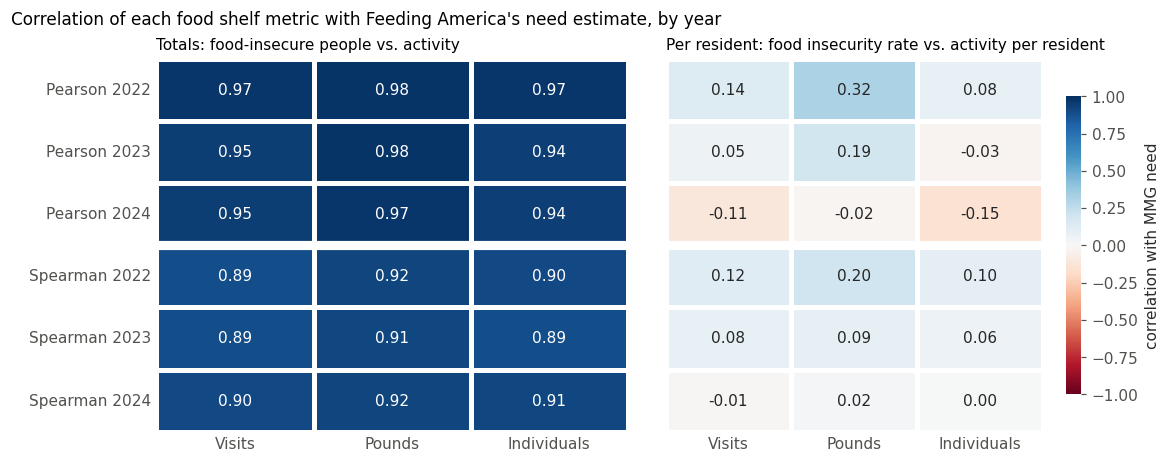

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4), gridspec_kw={"wspace": 0.08})
for ax, level in zip(axes, ["Totals", "Per resident"]):
    t = corr_table(corr, level)[METRICS]
    t.index = [f"{method.capitalize()} {year}" for method, year in t.index]
    t.columns = [NICE[m] for m in t.columns]
    sns.heatmap(t, annot=True, fmt=".2f", cmap="RdBu", vmin=-1, vmax=1, center=0,
                cbar=(level == "Per resident"), cbar_kws={"label": "correlation with MMG need", "shrink": 0.8},
                linewidths=2, linecolor="white", ax=ax, annot_kws={"fontsize": 10},
                yticklabels=(level == "Totals"))
    ax.axhline(3, color="white", lw=6)  # separate Pearson rows from Spearman rows
    ax.grid(False)
    ax.tick_params(length=0)
    need = "food-insecure people" if level == "Totals" else "food insecurity rate"
    ax.set_title(f"{level}: {need} vs. activity" + ("" if level == "Totals" else " per resident"),
                 loc="left", fontsize=10)
fig.suptitle("Correlation of each food shelf metric with Feeding America's need estimate, by year",
             x=0.01, ha="left", fontsize=11)
plt.show()

The left panel is uniformly dark blue: every metric tracks the *number* of food-insecure people closely. The right panel is nearly white: none of the metrics tracks the *rate* of food insecurity. Within each panel, the differences **between** metrics are much smaller than the difference **between** the panels.

## 12. Is the "strongest" metric clearly stronger, or is it within the noise?

Pounds comes out on top in every row, but the gaps are small. To check whether the ranking is reliable we use a **bootstrap**:

1. Draw 86 counties *with replacement* from that year's counties (some appear twice, some not at all).
2. Recompute the Spearman correlation for all three metrics **on the same resampled counties**, so the metrics are compared fairly.
3. Repeat 2,000 times.

The middle 95% of the resampled values gives a **95% interval** for each correlation. For the comparison between metrics, we look at the *difference* (e.g. Pounds − Visits) in each resample: if the interval for the difference includes 0, we can't confidently say one metric is stronger.

We use Spearman here because it is the measure not dominated by single counties. The seed is fixed so the result is reproducible.

In [38]:
rng = np.random.default_rng(2026)
N_BOOT = 2000
PAIRS = [("pounds", "visits"), ("pounds", "individuals"), ("visits", "individuals")]

ci_rows, diff_rows = [], []
for level, (need_col, pattern) in LEVELS.items():
    act_cols = [pattern.format(m=m) for m in METRICS]
    for year, g in comp.groupby("year"):
        data = g[[need_col] + act_cols].reset_index(drop=True)
        observed = pd.Series(data.corr(method="spearman").loc[need_col, act_cols].to_numpy(), index=METRICS)
        n = len(data)
        boot = []
        for _ in range(N_BOOT):
            sample = data.iloc[rng.integers(0, n, n)]
            boot.append(sample.corr(method="spearman").loc[need_col, act_cols].to_numpy())
        boot = pd.DataFrame(boot, columns=METRICS)

        for m in METRICS:
            ci_rows.append({"level": level, "year": year, "metric": m, "spearman": observed[m],
                            "ci_low": boot[m].quantile(0.025), "ci_high": boot[m].quantile(0.975)})
        for a, b in PAIRS:
            diff = boot[a] - boot[b]
            diff_rows.append({"level": level, "year": year, "comparison": f"{NICE[a]} − {NICE[b]}",
                              "observed difference": observed[a] - observed[b],
                              "95% low": diff.quantile(0.025), "95% high": diff.quantile(0.975),
                              "share of resamples > 0": (diff > 0).mean()})

boot_ci = pd.DataFrame(ci_rows)
boot_diff = pd.DataFrame(diff_rows)
boot_ci.round(2)

,level,year,metric,spearman,ci_low,ci_high
0,Totals,2022,visits,0.89,0.82,0.93
1,Totals,2022,pounds,0.92,0.85,0.95
2,Totals,2022,individuals,0.90,0.83,0.94
3,Totals,2023,visits,0.89,0.82,0.93
4,Totals,2023,pounds,0.91,0.84,0.95
5,Totals,2023,individuals,0.89,0.82,0.93
6,Totals,2024,visits,0.90,0.83,0.94
7,Totals,2024,pounds,0.92,0.87,0.95
8,Totals,2024,individuals,0.91,0.84,0.94
9,Per resident,2022,visits,0.12,-0.12,0.34


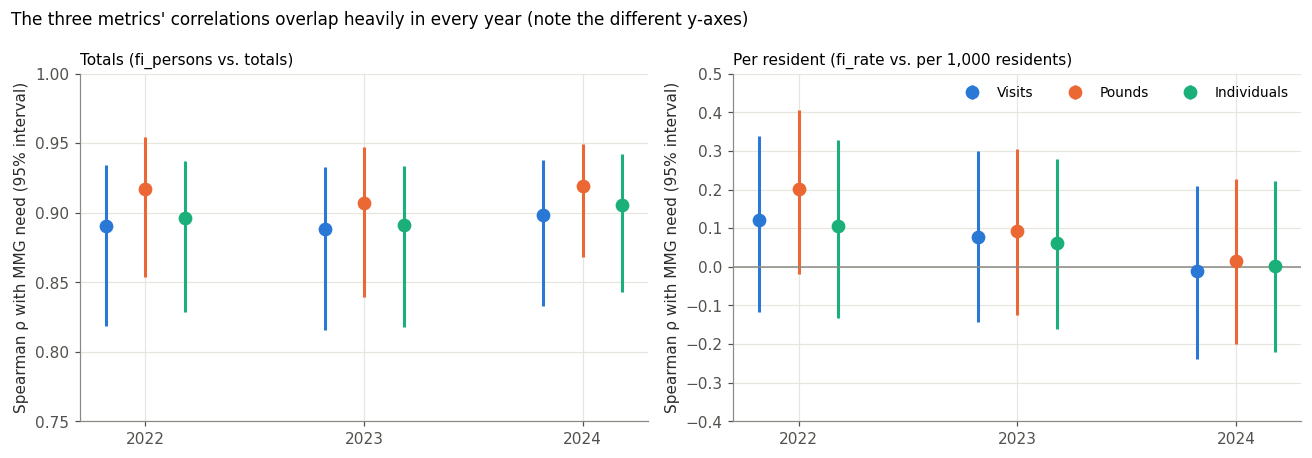

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
offsets = {"visits": -0.18, "pounds": 0, "individuals": 0.18}
for ax, level in zip(axes, ["Totals", "Per resident"]):
    sub = boot_ci[boot_ci["level"] == level]
    for m in METRICS:
        s = sub[sub["metric"] == m]
        x = s["year"] + offsets[m]
        ax.errorbar(x, s["spearman"], yerr=[s["spearman"] - s["ci_low"], s["ci_high"] - s["spearman"]],
                    fmt="o", ms=8, color=COLOR[m], ecolor=COLOR[m], elinewidth=2, capsize=0, label=NICE[m])
    ax.axhline(0, color="#8a8984", lw=1)
    ax.set_xticks([2022, 2023, 2024])
    ax.set_ylabel("Spearman ρ with MMG need (95% interval)")
    need = "fi_persons vs. totals" if level == "Totals" else "fi_rate vs. per 1,000 residents"
    ax.set_title(f"{level} ({need})", loc="left", fontsize=10)
axes[0].set_ylim(0.75, 1.0)
axes[1].set_ylim(-0.4, 0.5)
axes[1].legend(frameon=False, ncol=3, loc="upper right", fontsize=9)
fig.suptitle("The three metrics' correlations overlap heavily in every year (note the different y-axes)",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

In [40]:
boot_diff.round(2)

,level,year,comparison,observed difference,95% low,95% high,share of resamples > 0
0,Totals,2022,Pounds − Visits,0.03,-0.00,0.06,0.97
1,Totals,2022,Pounds − Individuals,0.02,-0.01,0.05,0.94
2,Totals,2022,Visits − Individuals,-0.01,-0.02,0.01,0.26
3,Totals,2023,Pounds − Visits,0.02,-0.01,0.05,0.91
4,Totals,2023,Pounds − Individuals,0.02,-0.01,0.05,0.91
5,Totals,2023,Visits − Individuals,-0.00,-0.03,0.02,0.40
6,Totals,2024,Pounds − Visits,0.02,-0.01,0.05,0.94
7,Totals,2024,Pounds − Individuals,0.01,-0.01,0.05,0.83
8,Totals,2024,Visits − Individuals,-0.01,-0.03,0.02,0.25
9,Per resident,2022,Pounds − Visits,0.08,-0.03,0.20,0.92


How to read the difference table: *"share of resamples > 0"* near 1.0 means the first metric was larger in almost every resample. Near 0.5 means it's a coin flip.

- **Totals:** the intervals sit high (≈ 0.82–0.95) and overlap. Pounds is ahead of the other two in most resamples (83–97%), but the gap is only ~0.01–0.03, which is not meaningful in practice.
- **Per resident:** every interval is wide and includes zero (overall from about −0.25 to +0.4). Pounds is clearly ahead in most resamples only in **2022** (92–96%). In 2023 and 2024 it is only modestly better than a coin flip (57–70%).
- **Visits vs. Individuals** is never clearly separated at either level.

So "Pounds is strongest" is a **consistent but small** pattern, not a clear-cut difference.

## 13. Are a few counties driving the correlations?

**Leave-one-out check:** remove each county in turn, recompute the correlation, and see how far it moves. If removing a single county changes r a lot, that county is *influential*. We **do not** remove it from the analysis. We just record which county it is so the next step can look at it.

In [41]:
loo_rows = []
for level, (need_col, pattern) in LEVELS.items():
    for year, g in comp.groupby("year"):
        for m in METRICS:
            act_col = pattern.format(m=m)
            full_p = g[need_col].corr(g[act_col])
            full_s = g[need_col].corr(g[act_col], method="spearman")
            loo_p = pd.Series({i: g.drop(i)[need_col].corr(g.drop(i)[act_col]) for i in g.index})
            loo_s = pd.Series({i: g.drop(i)[need_col].corr(g.drop(i)[act_col], method="spearman") for i in g.index})
            most = (loo_p - full_p).abs().idxmax()
            loo_rows.append({"level": level, "year": year, "metric": m,
                             "pearson (all)": full_p,
                             "pearson range when 1 county removed": f"{loo_p.min():.2f} to {loo_p.max():.2f}",
                             "most influential county": g.loc[most, "county"],
                             "pearson without it": loo_p[most],
                             "spearman (all)": full_s,
                             "spearman range when 1 county removed": f"{loo_s.min():.2f} to {loo_s.max():.2f}"})
loo = pd.DataFrame(loo_rows)
loo.round(2)

,level,year,metric,pearson (all),pearson range when 1 county removed,most influential county,pearson without it,spearman (all),spearman range when 1 county removed
0,Totals,2022,visits,0.97,0.93 to 0.98,Hennepin,0.93,0.89,0.89 to 0.90
1,Totals,2022,pounds,0.98,0.95 to 0.98,Hennepin,0.95,0.92,0.91 to 0.93
2,Totals,2022,individuals,0.97,0.91 to 0.98,Hennepin,0.91,0.90,0.89 to 0.91
3,Totals,2023,visits,0.95,0.84 to 0.97,Hennepin,0.84,0.89,0.88 to 0.90
4,Totals,2023,pounds,0.98,0.94 to 0.98,Hennepin,0.94,0.91,0.90 to 0.92
5,Totals,2023,individuals,0.94,0.79 to 0.97,Hennepin,0.79,0.89,0.89 to 0.90
6,Totals,2024,visits,0.95,0.82 to 0.96,Hennepin,0.82,0.90,0.89 to 0.91
7,Totals,2024,pounds,0.97,0.92 to 0.98,Hennepin,0.92,0.92,0.92 to 0.93
8,Totals,2024,individuals,0.94,0.78 to 0.96,Hennepin,0.78,0.91,0.90 to 0.91
9,Per resident,2022,visits,0.14,-0.00 to 0.22,Mahnomen,-0.00,0.12,0.09 to 0.16


- **Totals:** Pearson is pulled up by **Hennepin**, which has about twice as many food-insecure people as any other county and sits far out on its own. Removing Hennepin drops Pearson for Visits and Individuals by up to ~0.16 (to 0.82 and 0.78 in 2024), while Pounds stays at 0.92 or higher. Spearman barely moves for any metric (±0.01). So part of Pounds' Pearson lead on totals is that it stays strong *without* Hennepin, while Visits and Individuals lean on it more.
- **Per resident:** **Mahnomen** (the county with the highest food insecurity rate in all three years, 15.7–16.7%) is the most influential county in 2022 and 2023, and Washington / Scott in 2024.
  - The biggest effect is on **Pounds in 2022**: Pearson falls from **0.32 to 0.12 without Mahnomen**. So the one "statistically significant" result in section 10b depends on a single county.
  - Spearman moves much less (at most ±0.04), and Pounds' Spearman value stays the highest of the three with any single county removed (2022: 0.17–0.23 vs. 0.09–0.16 for Visits).

The scatterplots below show the per-resident relationship in 2022, the year with the largest differences between metrics, with the most influential county ringed. The line is the straight-line fit that Pearson measures. (Part 1, section 6.3 shows the same plots for 2024.)

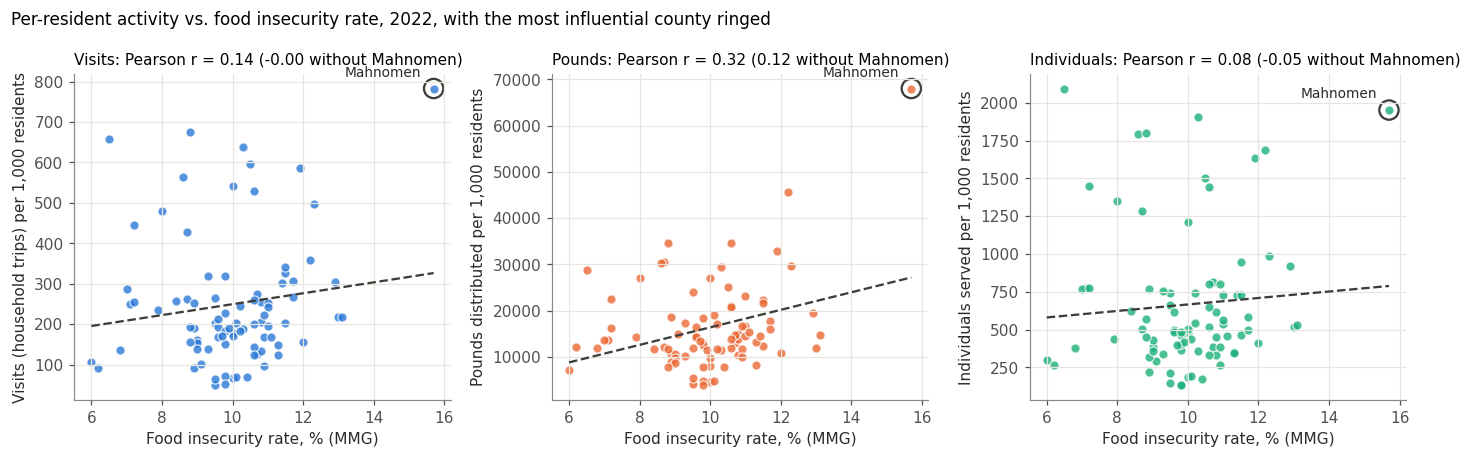

In [42]:
YEAR_CHECK = 2022
d22 = comp[comp["year"] == YEAR_CHECK]
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for ax, m in zip(axes, METRICS):
    col = f"{m}_per_1k"
    ax.scatter(d22["fi_rate"] * 100, d22[col], s=36, color=COLOR[m], alpha=0.8, edgecolor="white", linewidth=0.8)
    slope, intercept = np.polyfit(d22["fi_rate"] * 100, d22[col], 1)
    xs = np.linspace(d22["fi_rate"].min() * 100, d22["fi_rate"].max() * 100, 50)
    ax.plot(xs, intercept + slope * xs, color="#3d3d3a", lw=1.5, ls="--")
    row = loo[(loo["level"] == "Per resident") & (loo["year"] == YEAR_CHECK) & (loo["metric"] == m)].iloc[0]
    infl = d22[d22["county"] == row["most influential county"]].iloc[0]
    ax.scatter(infl["fi_rate"] * 100, infl[col], s=160, facecolor="none", edgecolor="#3d3d3a", linewidth=1.5)
    ax.annotate(infl["county"], (infl["fi_rate"] * 100, infl[col]), xytext=(-8, 8), textcoords="offset points",
                ha="right", fontsize=9, color="#2b2b2b")
    ax.set_xlabel("Food insecurity rate, % (MMG)")
    ax.set_ylabel(f"{LABEL[m]} per 1,000 residents")
    ax.set_title(f"{NICE[m]}: Pearson r = {row['pearson (all)']:.2f} "
                 f"({row['pearson without it']:.2f} without {infl['county']})", loc="left", fontsize=10)
fig.suptitle(f"Per-resident activity vs. food insecurity rate, {YEAR_CHECK}, with the most influential county ringed",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

The clouds of points are wide and flat for every metric, with a handful of counties far above the rest on activity per resident. Mahnomen sits alone in the top-right corner: the highest need rate, and the highest or near-highest activity per resident. That single point tilts every fitted line upward, the Pounds line most of all. *Why* Mahnomen, and the high-activity counties at the top of each plot, look the way they do is a question for the next step.

## 14. Does incomplete reporting change the answer?

Re-run section 10 **without** the 7 county-years flagged incomplete (missing months or more than 10% of site-months unreported), and compare.

In [43]:
corr_complete = correlate(comp[~comp["incomplete"]])
compare = (corr[["level", "year", "metric", "spearman", "pearson"]]
           .merge(corr_complete[["level", "year", "metric", "n", "spearman", "pearson"]],
                  on=["level", "year", "metric"], suffixes=(" (all)", " (complete only)")))
compare["max change"] = np.maximum((compare["spearman (all)"] - compare["spearman (complete only)"]).abs(),
                                   (compare["pearson (all)"] - compare["pearson (complete only)"]).abs())
display(compare.round(2))
print("Largest change in any correlation:", round(compare["max change"].max(), 3))
print("\nHighest / lowest metric per row, complete-reporting counties only:")
pd.concat({"Totals": corr_table(corr_complete, "Totals")[["highest", "lowest"]],
           "Per resident": corr_table(corr_complete, "Per resident")[["highest", "lowest"]]}, axis=1)

,level,year,metric,spearman (all),pearson (all),n,spearman (complete only),pearson (complete only),max change
0,Totals,2022,visits,0.89,0.97,83,0.88,0.97,0.01
1,Totals,2022,pounds,0.92,0.98,83,0.91,0.98,0.01
2,Totals,2022,individuals,0.90,0.97,83,0.89,0.97,0.01
3,Per resident,2022,visits,0.12,0.14,83,0.12,0.14,0.01
4,Per resident,2022,pounds,0.20,0.32,83,0.20,0.33,0.01
5,Per resident,2022,individuals,0.10,0.08,83,0.10,0.07,0.00
6,Totals,2023,visits,0.89,0.95,84,0.89,0.95,0.00
7,Totals,2023,pounds,0.91,0.98,84,0.90,0.98,0.00
8,Totals,2023,individuals,0.89,0.94,84,0.89,0.94,0.00
9,Per resident,2023,visits,0.08,0.05,84,0.06,0.05,0.02


Largest change in any correlation: 0.027

Highest / lowest metric per row, complete-reporting counties only:


Totals              Per resident             
metric        highest       lowest      highest       lowest
method   year                                               
pearson  2022  pounds  individuals       pounds  individuals
         2023  pounds  individuals       pounds  individuals
         2024  pounds  individuals       pounds  individuals
spearman 2022  pounds       visits       pounds  individuals
         2023  pounds       visits       pounds  individuals
         2024  pounds       visits       pounds       visits

Dropping the incomplete county-years changes the correlations only slightly, and the ordering of the metrics stays essentially the same. Missing food shelf reports are **not** what's behind these results.

## 15. Summary: which Food Group metrics have stronger or weaker relationships with Feeding America's estimated need?

**Short answer:** **Pounds distributed** was consistently the metric most strongly associated with Feeding America's need estimates, and **Individuals served** was usually the weakest, with Visits close behind. But the differences between the three metrics are **small**. The bigger story is *which kind* of comparison you make.

| | Visits | Pounds | Individuals |
|---|---|---|---|
| **Totals** (`fi_persons` vs. annual totals), Spearman 2022 / 2023 / 2024 | 0.89 / 0.89 / 0.90 | **0.92 / 0.91 / 0.92** | 0.90 / 0.89 / 0.91 |
| **Per resident** (`fi_rate` vs. per 1,000 residents), Spearman 2022 / 2023 / 2024 | 0.12 / 0.08 / −0.01 | **0.20 / 0.09 / 0.02** | 0.10 / 0.06 / 0.00 |
| **Per resident**, Pearson 2022 / 2023 / 2024 | 0.14 / 0.05 / −0.11 | **0.32 / 0.19 / −0.02** | 0.08 / −0.03 / −0.15 |

*(Values from sections 10a and 10b.)*

- **Strongest:** **Pounds** had the highest correlation in every year, for both methods and at both levels.
- **Weakest:** **Individuals** was lowest in 8 of the 12 year × method × level comparisons. Visits was lowest in the other 4 (the Spearman totals rows, by ~0.01). Visits and Individuals are practically tied, which fits since both count people rather than food.
- **Strength and direction:**
  - *Totals:* strong and positive for all three (≈ 0.9). This mainly says that bigger counties have both more estimated need and more food shelf activity.
  - *Per resident:* weak for all three (between about −0.15 and +0.32), and not reliably different from zero. The one exception is Pounds in 2022 (Pearson r = 0.32, p = 0.003), and that depends on Mahnomen: it drops to 0.12 without that one county.
- **Consistency across years:**
  - The *ordering* (Pounds on top) held in all three years.
  - The *strength* of the per-resident relationship faded each year, reaching about zero for every metric by 2024.
  - The totals correlations stayed steady around 0.9.
- **Totals vs. per resident tell different stories.** Totals say "all three metrics line up with need". Per-resident rates say "none of them line up with how *concentrated* need is". Judging metrics on totals alone would mostly reward whichever metric tracks population best.
- **How confident are we in the ranking?** Bootstrap intervals for the three metrics overlap heavily. Pounds' lead is a consistent but small pattern (clearest in 2022), not a decisive difference. Visits vs. Individuals can't be separated.

**Caveats**
- These are associations, not causes. A higher correlation for Pounds doesn't mean pounds respond to need. One possibility to check (not tested here) is that pounds partly reflect how food banks *allocate* food across counties, which may itself be informed by need estimates, while visits and individuals reflect who actually comes in.
- A few counties have outsized influence on Pearson: Hennepin on totals, and Mahnomen (2022–23) and Washington/Scott (2024) on per-resident values. They were kept, not removed. Spearman, which resists single counties, gives the same ordering of metrics.
- `individuals` counts repeat visits, and "Visits" uses the brief's household definition (the organizers' published "visits" match `individuals`). Both are analyzed, so the conclusion holds under either definition.
- MMG figures are model estimates, the 2024 MMG comes from a newer release, and activity is recorded where the food shelf is rather than where clients live.
- Excluding the 7 county-years with incomplete reporting does not change the conclusions.

**Next step (not done here):** identify the counties where food shelf activity and estimated need diverge most, starting from the per-resident comparison and the influential counties flagged in section 13. Then examine possible explanations (poverty, SNAP, vehicle access, cross-county use of regional food shelves).

---

# Part 3: Which counties break the pattern?

Parts 1 and 2 looked at the **overall** relationship between Feeding America's estimated need and food shelf activity. Now we switch from "how strong is the relationship?" to:

> **Which individual counties have food shelf activity that is unusually high, or unusually low, compared with what their estimated need would suggest?**

We look for both directions separately, because they are different stories:
- **Lower activity than expected:** fewer visits / pounds / individuals than counties with similar estimated need.
- **Higher activity than expected:** more activity than counties with similar estimated need.

**What this part does NOT do:** explain *why*. We deliberately do **not** use poverty, SNAP, vehicle access, rurality or any other county characteristic here, either to pick the counties or to describe them. If we used the explanation to choose the counties, we would just find what we expected. Picking the counties first, from need and activity alone, keeps Stage 4 honest.

The only extra information used is **food shelf reporting quality** (missing reports, corrected typos, flagged spikes), so we don't mistake a data problem for a real mismatch.

## 16. Defining a "mismatch"

### 16a. What should "expected activity" mean?

To say a county is "lower than expected", we need a clear expected value. We considered three reasonable definitions. All use only MMG need, food shelf activity, and (for one) population.

| | Method | Expected activity is... | Problem |
|---|---|---|---|
| **A** | **Regression of log(activity) on log(food-insecure people)**, fitted separately for each year and metric | what counties with a **similar number of food-insecure people** typically record | none serious |
| B | Regression of log(activity per resident) on food insecurity rate | what counties with a similar **rate** typically record per resident | Part 2 showed the rate barely predicts activity per resident (ρ ≈ 0), so "expected" ends up nearly the same for every county, regardless of need |
| C | Same activity per food-insecure person as the state median | state-median activity × food-insecure people (strict proportionality) | assumes activity grows exactly in proportion to need, which the data contradict (see 17a), so big counties look "high" just for being big |

**We use Method A as the main definition** and keep B and C as **robustness checks** (section 17b). Reasons:
- It uses the need measure directly (number of food-insecure people) and lets the data decide how activity scales with need.
- It is **size-neutral**: a county isn't flagged just for being large or small (checked in 17b). The prompt for this part, and Part 1's finding that size dominates totals, both make this the key requirement.
- It works on the **log scale**, so "twice as much as expected" and "half as much as expected" are equally large gaps in opposite directions, and Hennepin doesn't dominate the fit.

### 16b. The gap measure

For each county, year and metric:

$$\text{gap} = \log_2\left(\frac{\text{observed activity}}{\text{expected activity}}\right)$$

| gap | means |
|---|---|
| 0 | exactly as expected |
| **+1** | **2× the expected activity** |
| **−1** | **half the expected activity** |
| +2 / −2 | 4× / one quarter |

### 16c. When is a gap big enough to flag?

A county-year is **flagged** for a metric when activity is **at least twice** or **at most half** of what's expected (|gap| ≥ 1). We chose a "factor of two" cutoff because it is easy to explain to judges and big enough to matter in practice. In section 18 we check how many county-years this flags (roughly the most extreme fifth).

### 16d. Persistent vs. one-year

For each county and metric we look across 2022, 2023 and 2024:

| Pattern | Rule |
|---|---|
| **Persistent** high / low | flagged in the **same direction in at least 2 of 3 years**, and never flagged in the opposite direction |
| **One-year** high / low | flagged in exactly 1 year |
| **Changes direction** | flagged high in one year and low in another |
| Not flagged | never reaches the cutoff |

### 16e. Across metrics

A county that is persistently low (or high) on **all three** metrics is a strong, general mismatch between need and food shelf use. A county that is unusual **only on pounds** may reflect how much food is given per visit rather than how many people come. We record which metrics are persistent for each county.

### 16f. Reporting quality

Before believing a flag, we check whether a data problem could have produced it:
- **Possible false "low":** the county-year has missing months or more than 10% of site-months unreported (`incomplete`, from section 5d). For Visits, also a typo that was removed and set to missing during cleaning (`flag_typo_fixed`).
- **Possible false "high":** 20% or more of that metric in that county-year comes from rows the cleaning flagged as unusual spikes or summed duplicates (`flag_outlier`, `flag_dup_summed`), which were kept in the data.

Flags with a reporting concern are **kept and shown**, but they don't count towards "persistent" unless the county still has at least 2 **clean** flagged years.

## 17. Expected activity and gaps (Method A)

We start from `comp` (86 counties × 3 years; Wilkin has no food shelf and is handled separately at the end). For each year and metric we fit a straight line on the log scale and compare each county with the line.

In [44]:
keep_cols = (["fips", "county", "year", "fi_rate", "fi_persons", "population"] + METRICS
             + ["months_reported", "site_months", "site_months_missing", "share_site_months_missing", "incomplete"])
mm = comp[keep_cols].copy().reset_index(drop=True)
assert (mm[METRICS] > 0).all().all(), "log scale needs positive activity"

fit_rows = []
for year, g in mm.groupby("year"):
    x = np.log2(g["fi_persons"])
    for m in METRICS:
        y = np.log2(g[m])
        slope, intercept = np.polyfit(x, y, 1)
        line = intercept + slope * x
        mm.loc[g.index, f"{m}_expected"] = 2 ** line
        mm.loc[g.index, f"{m}_gap"] = y - line          # log2(observed / expected)
        fit_rows.append({"year": year, "metric": m, "slope": slope,
                         "R²": np.corrcoef(x, y)[0, 1] ** 2, "spread of gaps (SD)": (y - line).std()})
fits = pd.DataFrame(fit_rows)
fits.round(2)

,year,metric,slope,R²,spread of gaps (SD)
0,2022,visits,1.20,0.85,0.82
1,2022,pounds,1.18,0.88,0.70
2,2022,individuals,1.25,0.85,0.84
3,2023,visits,1.18,0.83,0.87
4,2023,pounds,1.15,0.86,0.75
5,2023,individuals,1.22,0.84,0.87
6,2024,visits,1.18,0.84,0.84
7,2024,pounds,1.17,0.87,0.75
8,2024,individuals,1.24,0.85,0.86


**How to read this.**
- The **slope is about 1.15–1.25** in every year and for every metric. When a county has twice as many food-insecure people, its food shelf activity is typically about 2.3 times higher, not just 2 times. In other words, larger counties tend to record somewhat **more activity per food-insecure person**. Method A treats that as part of the normal pattern, so no county is flagged just for being big.
- **R² ≈ 0.83–0.88:** the number of food-insecure people accounts for most of the variation in totals. As Part 1 showed, this is largely county size.
- **Spread of gaps ≈ 0.7–0.87** (log2 units): a typical county is within about 1.6–1.8× of its expected activity. Pounds has the smallest spread, consistent with Part 2, where pounds tracked need slightly best.

### 17b. Robustness: do Methods B and C find the same counties?

We compute the other two gap definitions and compare them with Method A:
- **Size bias:** the correlation between the gap and county size (log food-insecure people). A good mismatch measure should be close to 0, so it doesn't just pick out big or small counties.
- **Agreement:** the rank correlation between each method's gaps and Method A's.

In [45]:
for m in METRICS:
    # Method B: log2(activity per resident) vs. food insecurity rate
    for year, g in mm.groupby("year"):
        y = np.log2(g[m] / g["population"] * 1000)
        slope, intercept = np.polyfit(g["fi_rate"], y, 1)
        mm.loc[g.index, f"{m}_gap_B"] = y - (intercept + slope * g["fi_rate"])
    # Method C: activity per food-insecure person vs. that year's state median
    ratio = np.log2(mm[m] / mm["fi_persons"])
    mm[f"{m}_gap_C"] = ratio - ratio.groupby(mm["year"]).transform("median")

log_size = np.log(mm["fi_persons"])
rob_rows = []
for m in METRICS:
    rob_rows.append({"metric": m,
                     "size bias A": mm[f"{m}_gap"].corr(log_size, method="spearman"),
                     "size bias B": mm[f"{m}_gap_B"].corr(log_size, method="spearman"),
                     "size bias C": mm[f"{m}_gap_C"].corr(log_size, method="spearman"),
                     "agreement A–B": mm[f"{m}_gap"].corr(mm[f"{m}_gap_B"], method="spearman"),
                     "agreement A–C": mm[f"{m}_gap"].corr(mm[f"{m}_gap_C"], method="spearman")})
pd.DataFrame(rob_rows).set_index("metric").round(2)

,size bias A,size bias B,size bias C,agreement A–B,agreement A–C
metric,,,,,
visits,-0.06,0.24,0.27,0.91,0.92
pounds,-0.04,0.28,0.30,0.89,0.91
individuals,-0.09,0.30,0.34,0.86,0.88


- **Method A has essentially no size bias** (−0.04 to −0.09).
- **Methods B and C lean towards size** (+0.24 to +0.34). With them, big counties tend to look "high" and small counties "low" just because of their size. That is why A is the main method.
- Even so, the three methods **rank counties similarly** (agreement 0.86–0.92). The choice of method mostly matters for counties near the cutoff.
- **Side effect to keep in mind:** because B and C lean towards size, a *small* county that is "high" under A is less likely to also be flagged high under B or C. So the method-agreement check used later is stricter for small high-activity counties. We keep this in mind when building the shortlist.

## 18. Flag each county-year

Flag = **+1** if activity is at least 2× expected (gap ≥ 1), **−1** if at most half (gap ≤ −1), **0** otherwise. We do the same for Methods B and C, to use in the robustness column later.

In [46]:
THRESHOLD = 1.0   # log2 units: 1 = a factor of two

def flag(gap):
    return np.select([gap >= THRESHOLD, gap <= -THRESHOLD], [1, -1], default=0)

for m in METRICS:
    for suffix in ["", "_B", "_C"]:
        mm[f"{m}_flag{suffix}"] = flag(mm[f"{m}_gap{suffix}"])

flag_counts = pd.DataFrame({
    m: {"higher than expected (≥2×)": int((mm[f"{m}_flag"] == 1).sum()),
        "lower than expected (≤½)": int((mm[f"{m}_flag"] == -1).sum()),
        "share of county-years flagged": (mm[f"{m}_flag"] != 0).mean()}
    for m in METRICS})
flag_counts.round(2)

,visits,pounds,individuals
higher than expected (≥2×),34.00,27.00,39.00
lower than expected (≤½),24.00,22.00,23.00
share of county-years flagged,0.22,0.19,0.24


The factor-of-two cutoff flags **19–24% of county-years** per metric, so roughly the most extreme fifth, as intended. There are **more "higher" flags (27–39) than "lower" flags (22–24)**: a few counties sit very far above expected, while the low side is more compressed. Pounds has the fewest flags, matching its smaller spread.

## 19. Reporting-quality check

We go back to the site-level file **only for its data-quality flags**. We use the same filter as the county file (meal programs excluded, 2022–2024), so totals match.

In [47]:
site = pd.read_csv(PROCESSED / "foodshelf_site_month.csv", dtype={"fips": str})
site = site[(site["site_group"] != "meal") & site["year"].between(2022, 2024)].copy()

# Activity that comes from rows the cleaning flagged as spikes (kept) or summed duplicates
suspect = site["flag_outlier"] | site["flag_dup_summed"]
for m in METRICS:
    site[f"{m}_suspect"] = site[m].where(suspect, 0)

quality = (site.groupby(["fips", "year"])
               .agg(typo_fixed_rows=("flag_typo_fixed", "sum"),
                    **{f"{m}_suspect": (f"{m}_suspect", "sum") for m in METRICS},
                    **{f"{m}_site_sum": (m, "sum") for m in METRICS})
               .reset_index())
for m in METRICS:
    quality[f"{m}_share_suspect"] = quality[f"{m}_suspect"] / quality[f"{m}_site_sum"]

# Sanity check: site sums must equal the county totals we analyzed
check = mm.merge(quality, on=["fips", "year"], how="left", validate="one_to_one")
print("Max difference site sum vs. county total:",
      max((check[m] - check[f"{m}_site_sum"]).abs().max() for m in METRICS))

mm = mm.merge(quality[["fips", "year", "typo_fixed_rows"] + [f"{m}_share_suspect" for m in METRICS]],
              on=["fips", "year"], how="left", validate="one_to_one")
mm["typo_fixed_rows"] = mm["typo_fixed_rows"].fillna(0).astype(int)
print("County-years with a removed visits typo:", mm.loc[mm["typo_fixed_rows"] > 0, ["county", "year"]].values.tolist())
print("County-years with >=20% of any metric from flagged rows:")
mm.loc[(mm[[f"{m}_share_suspect" for m in METRICS]] >= 0.2).any(axis=1),
       ["county", "year"] + [f"{m}_share_suspect" for m in METRICS]].round(2)

Max difference site sum vs. county total: 2.3283064365386963e-10


County-years with a removed visits typo: [['Dakota', 2024], ['Hennepin', 2024], ['Polk', 2023], ['Waseca', 2023]]
County-years with >=20% of any metric from flagged rows:


,county,year,visits_share_suspect,pounds_share_suspect,individuals_share_suspect
98,Kanabec,2024,0.28,0.34,0.25


In [48]:
SUSPECT_SHARE = 0.20
for m in METRICS:
    low_concern = mm["incomplete"] | ((m == "visits") & (mm["typo_fixed_rows"] > 0))
    high_concern = mm[f"{m}_share_suspect"] >= SUSPECT_SHARE
    mm[f"{m}_report_concern"] = ((mm[f"{m}_flag"] == -1) & low_concern) | ((mm[f"{m}_flag"] == 1) & high_concern)

concern_list = []
for m in METRICS:
    rows = mm[mm[f"{m}_report_concern"]]
    for _, r in rows.iterrows():
        concern_list.append({"county": r["county"], "year": r["year"], "metric": m,
                             "flag": "higher" if r[f"{m}_flag"] == 1 else "lower", "gap": r[f"{m}_gap"],
                             "months_reported": r["months_reported"],
                             "share_site_months_missing": r["share_site_months_missing"],
                             "share from flagged rows": r[f"{m}_share_suspect"]})
print("Flagged county-year-metrics with a reporting concern:")
pd.DataFrame(concern_list).round(2)

Flagged county-year-metrics with a reporting concern:


,county,year,metric,flag,gap,months_reported,share_site_months_missing,share from flagged rows
0,Douglas,2023,visits,lower,-1.26,11,0.00,0.0
1,Grant,2022,visits,lower,-1.27,9,0.61,0.0
2,Stevens,2024,pounds,lower,-1.43,9,0.25,0.0
3,Douglas,2023,individuals,lower,-1.05,11,0.00,0.0
4,Grant,2022,individuals,lower,-1.22,9,0.61,0.0


**What the reporting check found**
- **Five flagged results have a reporting concern, and all five are "lower than expected" flags in county-years with missing reports:**
  - **Grant 2022** (Visits, Individuals): only 9 of 12 months reported, 61% of site-months missing.
  - **Stevens 2024** (Pounds): 9 months reported.
  - **Douglas 2023** (Visits, Individuals): 11 months reported.
- **The four removed visits typos** (Dakota and Hennepin 2024, Polk and Waseca 2023) did **not** produce any low flag.
- **On the high side,** only Kanabec 2024 gets ≥20% of its activity from rows flagged as spikes or summed duplicates, and Kanabec is not flagged high. So **no "higher than expected" result is driven by flagged data**.

These flags are kept and marked †, but they don't count towards persistence (next section).

## 20. Persistent or one-year? (per county and metric)

We reshape to one row per **county × metric** and count the flagged years in each direction, using the rules in 16d. `clean_*` counts only flagged years **without** a reporting concern.

In [49]:
long = pd.concat([
    mm[["fips", "county", "year", f"{m}_gap", f"{m}_flag", f"{m}_flag_B", f"{m}_flag_C", f"{m}_report_concern"]]
      .rename(columns={f"{m}_gap": "gap", f"{m}_flag": "flag", f"{m}_flag_B": "flag_B",
                       f"{m}_flag_C": "flag_C", f"{m}_report_concern": "concern"})
      .assign(metric=m)
    for m in METRICS], ignore_index=True)

def classify(years_high, years_low):
    if years_high >= 1 and years_low >= 1:
        return "changes direction"
    if years_high >= 2:
        return "persistent high"
    if years_low >= 2:
        return "persistent low"
    if years_high == 1:
        return "one-year high"
    if years_low == 1:
        return "one-year low"
    return "not flagged"

per = (long.groupby(["fips", "county", "metric"])
           .apply(lambda g: pd.Series({
               "years_high": int((g["flag"] == 1).sum()),
               "years_low": int((g["flag"] == -1).sum()),
               "clean_years_high": int(((g["flag"] == 1) & ~g["concern"]).sum()),
               "clean_years_low": int(((g["flag"] == -1) & ~g["concern"]).sum()),
               "mean_gap": g["gap"].mean(),
               "gap_2022": g.loc[g["year"] == 2022, "gap"].iloc[0],
               "gap_2023": g.loc[g["year"] == 2023, "gap"].iloc[0],
               "gap_2024": g.loc[g["year"] == 2024, "gap"].iloc[0],
               "years_high_B": int((g["flag_B"] == 1).sum()), "years_low_B": int((g["flag_B"] == -1).sum()),
               "years_high_C": int((g["flag_C"] == 1).sum()), "years_low_C": int((g["flag_C"] == -1).sum()),
           }), include_groups=False)
           .reset_index())

per["pattern"] = [classify(h, l) for h, l in zip(per["years_high"], per["years_low"])]
per["pattern_clean"] = [classify(h, l) for h, l in zip(per["clean_years_high"], per["clean_years_low"])]
per["reporting_sensitive"] = per["pattern"].str.startswith("persistent") & ~per["pattern_clean"].str.startswith("persistent")
# How many of the three methods (A, B, C) agree that the pattern is persistent in the same direction?
direction = np.where(per["pattern"] == "persistent high", 1, np.where(per["pattern"] == "persistent low", -1, 0))
per["methods_agree"] = np.where(
    direction == 1, 1 + (per["years_high_B"] >= 2).astype(int) + (per["years_high_C"] >= 2).astype(int),
    np.where(direction == -1, 1 + (per["years_low_B"] >= 2).astype(int) + (per["years_low_C"] >= 2).astype(int), 0))

pd.crosstab(per["pattern"], per["metric"]).reindex(columns=METRICS)

metric,visits,pounds,individuals
pattern,,,
not flagged,59,61,55
one-year high,3,5,5
one-year low,4,3,5
persistent high,12,9,14
persistent low,8,8,7


For each metric, most counties (55–61 of 86) are **never flagged**. Between 7 and 14 counties per metric are **persistent** in each direction, and 7–10 are **one-year** flags. **No county changes direction** on any metric: none is flagged high in one year and low in another.

The table counts patterns using all flagged years. The lists below also show the version that counts only clean years (`clean_years_*`), and the cross-county summary in section 21 uses the clean version.

### 20a. Persistent mismatches, metric by metric

Each list is sorted by the average gap over the three years. `×` columns convert the average gap back into "times the expected activity".

In [50]:
show_cols = ["county", "gap_2022", "gap_2023", "gap_2024", "mean_gap", "times_expected",
             "clean_years_high", "clean_years_low", "reporting_sensitive", "methods_agree"]
per["times_expected"] = 2 ** per["mean_gap"]
for m in METRICS:
    for direction_name in ["persistent low", "persistent high"]:
        t = per[(per["metric"] == m) & (per["pattern"] == direction_name)].sort_values("mean_gap")
        print(f"\n{LABEL[m]}: {direction_name} ({len(t)} counties)")
        print(t[show_cols].round(2).to_string(index=False) if len(t) else "  none")


Visits (household trips): persistent low (8 counties)
       county  gap_2022  gap_2023  gap_2024  mean_gap  times_expected  clean_years_high  clean_years_low  reporting_sensitive  methods_agree
     Nicollet     -2.19     -1.83     -1.76     -1.93            0.26               0.0              3.0                False              3
         Pope     -1.76     -1.81     -1.63     -1.73            0.30               0.0              3.0                False              3
       Norman     -1.23     -1.43     -1.41     -1.36            0.39               0.0              3.0                False              3
Lac qui Parle     -1.17     -1.29     -1.22     -1.23            0.43               0.0              3.0                False              3
       Benton     -1.82     -1.01     -0.78     -1.20            0.43               0.0              2.0                False              1
       Roseau     -1.46     -1.29     -0.84     -1.19            0.44               0.0            

**Reading the lists** (× = activity as a multiple of expected, averaged over 3 years):

| | Lower than expected (persistent) | Higher than expected (persistent) |
|---|---|---|
| **Visits** | Nicollet (0.26×), Pope, Norman, Lac qui Parle, Benton, Roseau, Brown; *Douglas, reporting-sensitive (see below)* | Steele (4.6×), Washington, Rice, Renville, Cook, Mahnomen, Koochiching, Dodge, Olmsted, Kittson, Houston, Mille Lacs |
| **Pounds** | Nicollet (0.32×), Norman, Benton, Lincoln, Roseau, Lac qui Parle, Nobles, Chippewa | Steele (3.2×), Rice, Mahnomen, Kittson, Pipestone, Washington, Cook, Jackson, Renville |
| **Individuals** | Pope (0.29×), Nicollet, Lac qui Parle, Benton, Brown, Norman, Roseau | Steele (4.8×), Washington, Rice, Renville, Cook, Mahnomen, Pipestone, Dodge, Anoka, Olmsted, Watonwan, Jackson, Kittson, Mille Lacs |

**Patterns over time worth noting (description only):**
- **Steady:** Nicollet, Pope, Lac qui Parle and Norman are low by almost the same amount every year. Washington and Renville are consistently high.
- **Growing:** Steele (visits 3.5× → 4.8× → 5.7×) and Rice (2.4× → 3.9× → 4.0×) move further above expected each year.
- **Fading:** Mille Lacs and Mahnomen were well above expected in 2022–2023 but much closer to expected in 2024. Benton was far below expected in 2022 (0.3×) and less so by 2024 (0.5–0.6×).
- **Recent:** Nobles and Chippewa (pounds) are flagged only in 2023–2024.
- **Douglas (visits)** sits at about half of expected every year (0.47–0.51×), but one of its two flagged years (2023) is missing a month of reports, and 2024 just misses the cutoff. It is labeled **reporting-sensitive** rather than persistent.

### 20b. One-year anomalies and direction changes

These counties crossed the cutoff in only one year, or in opposite directions in different years. They are less convincing as mismatches. They're listed so nothing is hidden.

In [51]:
one_year = per[per["pattern"].isin(["one-year high", "one-year low", "changes direction"])]
one_year_tbl = (one_year.assign(entry=lambda d: d["metric"] + " (" + d["pattern"].str.replace("one-year ", "") + ")")
                        .groupby("county")["entry"].apply(", ".join).rename("one-year or mixed flags").to_frame())
print(f"{one_year['county'].nunique()} counties have at least one one-year or mixed flag; "
      f"{(per['pattern'] == 'changes direction').sum()} county-metrics change direction.")
one_year_tbl

15 counties have at least one one-year or mixed flag; 0 county-metrics change direction.


,one-year or mixed flags
county,
Blue Earth,"individuals (high), pounds (high)"
Douglas,individuals (low)
Grant,"individuals (low), visits (low)"
Houston,individuals (high)
Itasca,"individuals (high), pounds (high)"
Koochiching,"individuals (high), pounds (high)"
Lincoln,visits (high)
Nobles,"individuals (low), visits (low)"
Olmsted,pounds (high)


- **No county changes direction** within a metric.
- **Several one-year flags belong to counties that are persistent on another metric** (e.g. Koochiching, Olmsted, Pipestone, Houston, Nobles). They add a little support to those counties but aren't counted as persistence.
- **One-year-only counties** (no persistent flag on any metric):
  - Low: **Scott** (all three metrics, 2024 only), **Todd** (2022), **Grant** (2022, reporting concern), **Stevens** (2024, reporting concern), **Swift** (pounds, 2024), **Douglas** (after removing its reporting-affected year).
  - High: **Wabasha** (all three metrics, 2024 only), **Blue Earth**, **Itasca**.

  Scott and Wabasha are worth watching: a one-year jump on all three metrics at once could be a real change, or a reporting change at a site. 2025 data would show whether it lasts.
- **Lincoln is unusual across metrics:** persistently *low* on pounds, but *high* on visits in 2022. That is a pounds-per-visit pattern rather than a general need mismatch.

## 21. Cross-metric consistency (one row per county)

Now we combine the three metrics for each county:
- `metrics_persistent_low` / `metrics_persistent_high`: how many of the three metrics are persistent in that direction (counting only clean years).
- `consistency`: a plain-language label (e.g. "all 3 metrics", "pounds only").
- `mean_gap_all`: the average gap over all 3 metrics × 3 years. It's a simple summary of how big the mismatch is (log2 scale; +1 = 2× expected).
- `need_rate_vs_state`: whether the county's food insecurity **rate** is above or below the state median, as **context only**. This is MMG's own need measure, not an explanatory variable, and it was not used to select counties.

In [52]:
state_median_rate = mm.groupby("year")["fi_rate"].median()
mm["need_rate_vs_state"] = np.where(mm["fi_rate"] > mm["year"].map(state_median_rate), "above median", "at/below median")

def metric_list(sub):
    return ", ".join(sub["metric"]) if len(sub) else ""

rows = []
for (fips, county), g in per.groupby(["fips", "county"]):
    low = g[g["pattern_clean"] == "persistent low"]
    high = g[g["pattern_clean"] == "persistent high"]
    n_low, n_high = len(low), len(high)
    if n_low and n_high:
        direction, metrics = "mixed", metric_list(pd.concat([low, high]))
    elif n_low:
        direction, metrics = "lower than expected", metric_list(low)
    elif n_high:
        direction, metrics = "higher than expected", metric_list(high)
    else:
        direction, metrics = "", ""
    n = max(n_low, n_high)
    consistency = {3: "all 3 metrics", 2: f"2 metrics ({metrics})", 1: f"{metrics} only"}.get(n, "")
    need_years = mm.loc[mm["fips"] == fips, "need_rate_vs_state"]
    rows.append({"fips": fips, "county": county, "direction": direction, "consistency": consistency,
                 "metrics_persistent_low": n_low, "metrics_persistent_high": n_high,
                 "metrics_reporting_sensitive": int(g["reporting_sensitive"].sum()),
                 "min_methods_agree": int(g.loc[g["pattern_clean"].str.startswith("persistent"), "methods_agree"].min())
                                      if (n_low or n_high) else 0,
                 "mean_gap_all": g["mean_gap"].mean(),
                 "mean_fi_rate": mm.loc[mm["fips"] == fips, "fi_rate"].mean(),
                 "need_rate_vs_state": need_years.mode().iloc[0],
                 "one_year_or_mixed_flags": int(g["pattern"].isin(["one-year high", "one-year low", "changes direction"]).sum())})
county_summary = pd.DataFrame(rows)
county_summary["times_expected_all"] = 2 ** county_summary["mean_gap_all"]

persistent_any = county_summary[county_summary["direction"] != ""].sort_values("mean_gap_all")
print(f"{len(persistent_any)} counties have a persistent mismatch on at least one metric")
persistent_any[["county", "direction", "consistency", "mean_gap_all", "times_expected_all",
                "need_rate_vs_state", "metrics_reporting_sensitive", "min_methods_agree"]].round(2)

26 counties have a persistent mismatch on at least one metric


,county,direction,consistency,mean_gap_all,times_expected_all,need_rate_vs_state,metrics_reporting_sensitive,min_methods_agree
51,Nicollet,lower than expected,all 3 metrics,-1.76,0.29,at/below median,0,3
60,Pope,lower than expected,"2 metrics (individuals, visits)",-1.38,0.39,at/below median,0,3
36,Lac qui Parle,lower than expected,all 3 metrics,-1.29,0.41,at/below median,0,3
4,Benton,lower than expected,all 3 metrics,-1.26,0.42,above median,0,1
53,Norman,lower than expected,all 3 metrics,-1.26,0.42,above median,0,3
67,Roseau,lower than expected,all 3 metrics,-1.11,0.46,at/below median,0,3
52,Nobles,lower than expected,pounds only,-0.94,0.52,above median,0,1
7,Brown,lower than expected,"2 metrics (individuals, visits)",-0.79,0.58,at/below median,0,3
11,Chippewa,lower than expected,pounds only,-0.61,0.65,above median,0,2
40,Lincoln,lower than expected,pounds only,-0.48,0.72,at/below median,0,3


**26 counties** have a persistent mismatch on at least one metric: **10 lower** than expected and **16 higher**. **None is mixed** (low on one metric and persistently high on another).

| Consistency | Lower than expected | Higher than expected |
|---|---|---|
| **All 3 metrics** | Nicollet, Lac qui Parle, Benton, Norman, Roseau | Steele, Washington, Rice, Renville, Mahnomen, Cook, Kittson |
| **2 metrics** | Pope, Brown (visits + individuals) | Mille Lacs, Dodge, Olmsted (visits + individuals); Jackson, Pipestone (individuals + pounds) |
| **1 metric** | Nobles, Chippewa, Lincoln (**pounds only**) | Houston, Koochiching (visits only); Watonwan, Anoka (individuals only) |

**Pounds-only mismatches are all on the low side.** In those three counties, roughly the expected number of visits and people are recorded, but much less food is handed out than expected. That points to something about **food distributed per visit** rather than how many people come, which is a different question from need vs. demand.

## 22. Heatmap: counties × metric × year

Every county with a persistent mismatch on at least one metric, plus any whose persistence disappears once reporting concerns are removed. Each cell is the **gap** (log2 of observed ÷ expected):
- **Blue** = more activity than expected, **red** = less, white = as expected.
- The number in each cell is the multiple of expected activity (e.g. 0.4× or 2.5×).
- A **†** marks a flagged cell with a reporting concern.

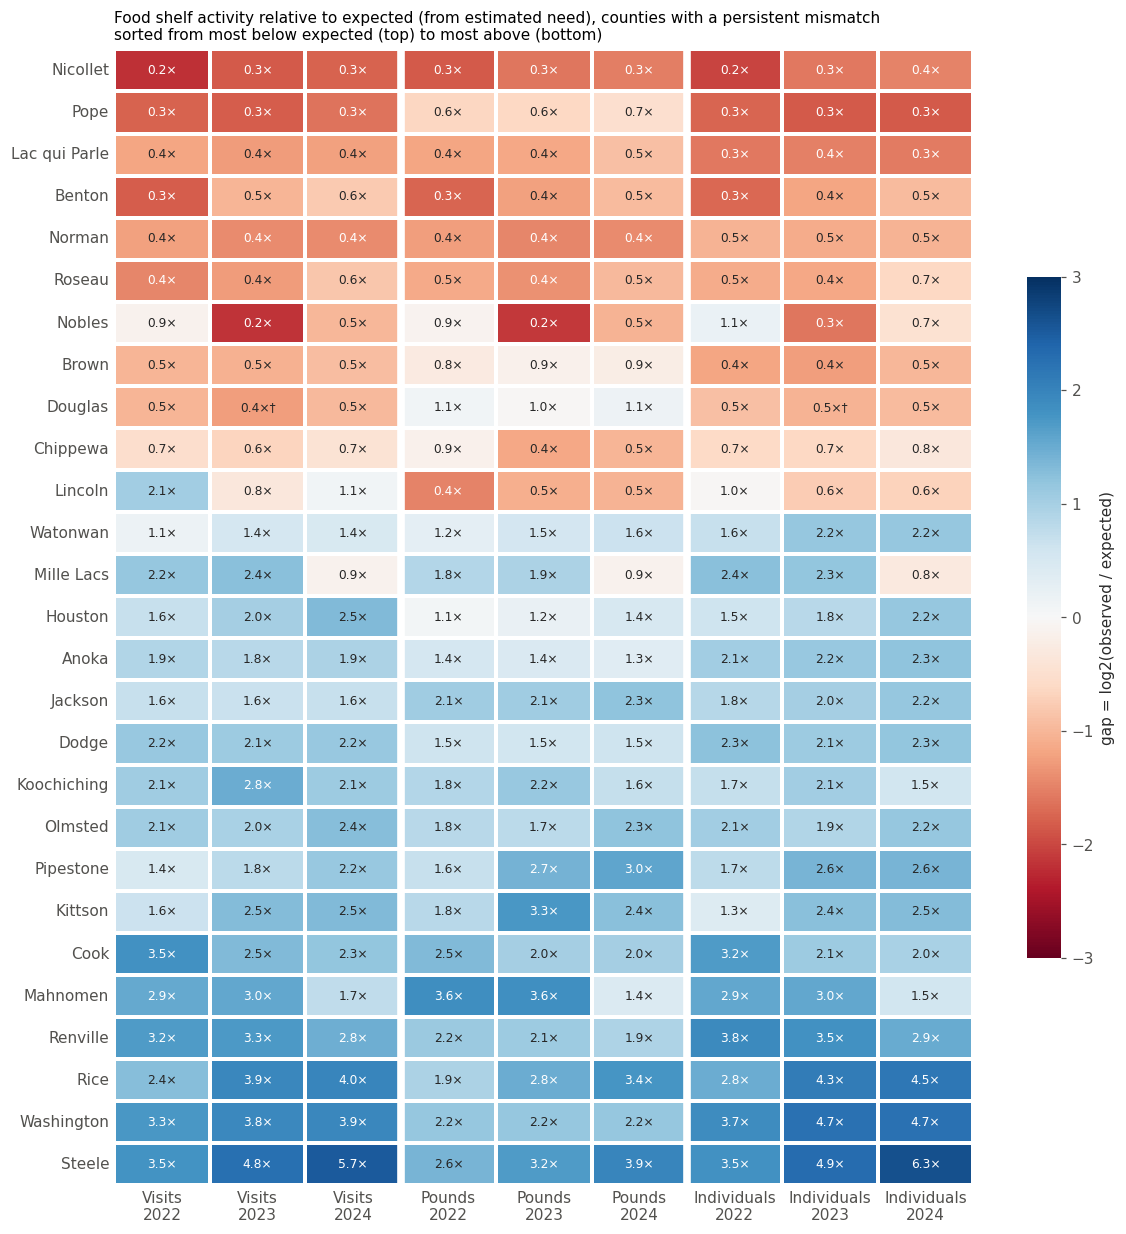

In [53]:
heat_counties = sorted(set(persistent_any["county"]) | set(per.loc[per["reporting_sensitive"], "county"]))
heat_long = long[long["county"].isin(heat_counties)].copy()
heat_long["col"] = heat_long["metric"].map(NICE) + "\n" + heat_long["year"].astype(str)
col_order = [f"{NICE[m]}\n{y}" for m in METRICS for y in [2022, 2023, 2024]]
order = (county_summary.set_index("county").loc[heat_counties, "mean_gap_all"].sort_values().index)

gap_mat = heat_long.pivot(index="county", columns="col", values="gap").loc[order, col_order]
lab = heat_long.assign(lab=lambda d: (2 ** d["gap"]).map(lambda v: f"{v:.1f}×") + np.where(d["concern"], "†", ""))
lab_mat = lab.pivot(index="county", columns="col", values="lab").loc[order, col_order]

fig, ax = plt.subplots(figsize=(11, 0.36 * len(order) + 1.6))
sns.heatmap(gap_mat, cmap="RdBu", center=0, vmin=-3, vmax=3, annot=lab_mat, fmt="", annot_kws={"fontsize": 8},
            linewidths=1.5, linecolor="white", cbar_kws={"label": "gap = log2(observed / expected)", "shrink": 0.6}, ax=ax)
for x in [3, 6]:
    ax.axvline(x, color="white", lw=5)
ax.grid(False); ax.tick_params(length=0)
ax.set_xlabel(""); ax.set_ylabel("")
ax.set_title("Food shelf activity relative to expected (from estimated need), counties with a persistent mismatch\n"
             "sorted from most below expected (top) to most above (bottom)", loc="left", fontsize=10)
plt.tight_layout()
plt.show()

**How to read it:** each row is a county. Red rows (top) are below expected and blue rows (bottom) above. Reading across a row shows whether the mismatch holds across all three metrics and all three years.
- **The low side is remarkably stable:** Nicollet, Pope, Lac qui Parle and Norman are at roughly 0.2–0.5× in nearly every cell.
- **Pope** is very low on visits and individuals (0.3×) but less so on pounds (0.6–0.7×, not flagged): few visitors, but a closer-to-expected amount of food.
- **The high side has the most extreme values** and some are **growing**: Steele reaches 5.7× on visits and 6.3× on individuals in 2024.
- **Mahnomen and Mille Lacs fade in 2024** (lighter cells in each metric's last column).
- **Douglas** shows the only † (reporting concern) among these counties, in 2023.

## 23. Shortlist for Stage 4

We want a short list of counties where the evidence is convincing, not just the biggest single numbers. A county makes the shortlist if it meets **all** of these:

1. **Persistent in at least 2 of the 3 metrics, in the same direction**, counting only clean (no reporting concern) years. This means it's a general need-vs-activity mismatch, not something about one metric.
2. **The same direction holds under at least one alternative method** (B or C) for every one of those metrics, so the result doesn't depend on our choice of method.
3. **Large:** the average gap across all metrics and years is at least a factor of 2 (|mean gap| ≥ 1).

Then, within each direction, counties are ordered by the size of the average gap.

In [54]:
shortlist = county_summary[
    (county_summary[["metrics_persistent_low", "metrics_persistent_high"]].max(axis=1) >= 2)
    & (county_summary["direction"] != "mixed")
    & (county_summary["min_methods_agree"] >= 2)
    & (county_summary["mean_gap_all"].abs() >= 1)
].copy()
shortlist["order"] = np.where(shortlist["direction"] == "lower than expected", shortlist["mean_gap_all"], -shortlist["mean_gap_all"])
shortlist = shortlist.sort_values(["direction", "order"], ascending=[False, True]).drop(columns="order")
county_summary["shortlist"] = county_summary["fips"].isin(shortlist["fips"])

print("Shortlist size:", len(shortlist), "|", shortlist["direction"].value_counts().to_dict())
shortlist[["county", "direction", "consistency", "mean_gap_all", "times_expected_all", "mean_fi_rate",
           "need_rate_vs_state", "min_methods_agree", "one_year_or_mixed_flags"]].round(3)

Shortlist size: 12 | {'higher than expected': 7, 'lower than expected': 5}


,county,direction,consistency,mean_gap_all,times_expected_all,mean_fi_rate,need_rate_vs_state,min_methods_agree,one_year_or_mixed_flags
51,Nicollet,lower than expected,all 3 metrics,-1.764,0.294,0.104,at/below median,3,0
60,Pope,lower than expected,"2 metrics (individuals, visits)",-1.376,0.385,0.106,at/below median,3,0
36,Lac qui Parle,lower than expected,all 3 metrics,-1.285,0.410,0.104,at/below median,3,0
53,Norman,lower than expected,all 3 metrics,-1.264,0.416,0.112,above median,3,0
67,Roseau,lower than expected,all 3 metrics,-1.107,0.464,0.107,at/below median,3,0
73,Steele,higher than expected,all 3 metrics,2.046,4.131,0.097,at/below median,3,0
81,Washington,higher than expected,all 3 metrics,1.718,3.289,0.074,at/below median,3,0
65,Rice,higher than expected,all 3 metrics,1.685,3.215,0.098,at/below median,3,0
64,Renville,higher than expected,all 3 metrics,1.474,2.778,0.116,above median,2,0
43,Mahnomen,higher than expected,all 3 metrics,1.301,2.464,0.163,above median,3,0


In [55]:
# Who just missed the shortlist? (persistent on >= 2 metrics, but failed the method or size test)
near = county_summary[
    (county_summary[["metrics_persistent_low", "metrics_persistent_high"]].max(axis=1) >= 2)
    & ~county_summary["shortlist"]]
county_summary["priority"] = np.select([county_summary["shortlist"], county_summary["fips"].isin(near["fips"])],
                                       ["shortlist", "second tier"], default="")
near[["county", "direction", "consistency", "mean_gap_all", "times_expected_all", "min_methods_agree"]].round(2)

,county,direction,consistency,mean_gap_all,times_expected_all,min_methods_agree
4,Benton,lower than expected,all 3 metrics,-1.26,0.42,1
7,Brown,lower than expected,"2 metrics (individuals, visits)",-0.79,0.58,3
15,Cook,higher than expected,all 3 metrics,1.27,2.41,1
19,Dodge,higher than expected,"2 metrics (individuals, visits)",0.96,1.95,2
31,Jackson,higher than expected,"2 metrics (individuals, pounds)",0.93,1.91,1
34,Kittson,higher than expected,all 3 metrics,1.11,2.16,1
47,Mille Lacs,higher than expected,"2 metrics (individuals, visits)",0.68,1.60,3


In [56]:
# Context only (NOT used for selection): where do the shortlisted counties sit on MMG's need RATE?
(shortlist.groupby(["direction", "need_rate_vs_state"])["county"].apply(", ".join)
          .unstack(fill_value="—").rename_axis(columns="food insecurity rate vs. state median"))

food insecurity rate vs. state median,above median,at/below median
direction,,
higher than expected,"Renville, Mahnomen, Pipestone","Steele, Washington, Rice, Olmsted"
lower than expected,Norman,"Nicollet, Pope, Lac qui Parle, Roseau"


**Shortlist: 12 counties** (5 lower than expected, 7 higher). None is reporting-sensitive, and all are persistent on at least 2 metrics with the result holding under at least one other method.

| Direction | County | Consistent on | Avg. multiple of expected |
|---|---|---|---|
| **Lower than expected** | Nicollet | all 3 metrics | 0.29× |
| | Pope | visits, individuals | 0.39× |
| | Lac qui Parle | all 3 | 0.41× |
| | Norman | all 3 | 0.42× |
| | Roseau | all 3 | 0.46× |
| **Higher than expected** | Steele | all 3 | 4.1× |
| | Washington | all 3 | 3.3× |
| | Rice | all 3 | 3.2× |
| | Renville | all 3 | 2.8× |
| | Mahnomen | all 3 | 2.5× (fading in 2024) |
| | Pipestone | individuals, pounds | 2.1× |
| | Olmsted | visits, individuals | 2.0× |

**Second tier** (persistent on ≥2 metrics but failed one shortlist test). These are worth a look in Stage 4 if time allows:
- **Benton** (low, all 3 metrics), **Cook**, **Kittson** (high, all 3) and **Jackson** (high, 2): the result **depends on the method**. They are clear under Method A, but the size-leaning Methods B/C don't put them past the cutoff. Cook, Kittson and Jackson are small counties, the case where B/C are least favorable to "high" (section 17b).
- **Brown** (low), **Dodge** and **Mille Lacs** (high): consistent, but the average mismatch is under a factor of 2 (and Mille Lacs faded in 2024).

**Need level, as context only.** The table above splits the shortlist by MMG's need **rate**. It wasn't used for selection.
- **Higher than expected, need rate at or below the state median:** Steele, Washington, Rice, Olmsted. These match the brief's "lower need / higher activity" type.
- **Higher than expected, above-median need rate:** Mahnomen, Renville, Pipestone. High estimated need, and *even more* activity than counties with a similar food-insecure count.
- **Lower than expected:** only **Norman** has an above-median need rate (the classic "high need / low activity" case). Nicollet, Pope, Lac qui Parle and Roseau have **moderate** need rates. They are "low activity *relative to their food-insecure population*", not "highest-need counties".

So the "high need / low activity" story is narrower than one might expect. Stage 4 should keep that distinction.

### 23a. Where the shortlisted counties sit

The same totals scatterplots as Part 1 (log scales, 2024). The dark line is **expected activity** (Method A fit), and the dotted lines mark **2× and ½×** expected. Only shortlisted counties are labeled.

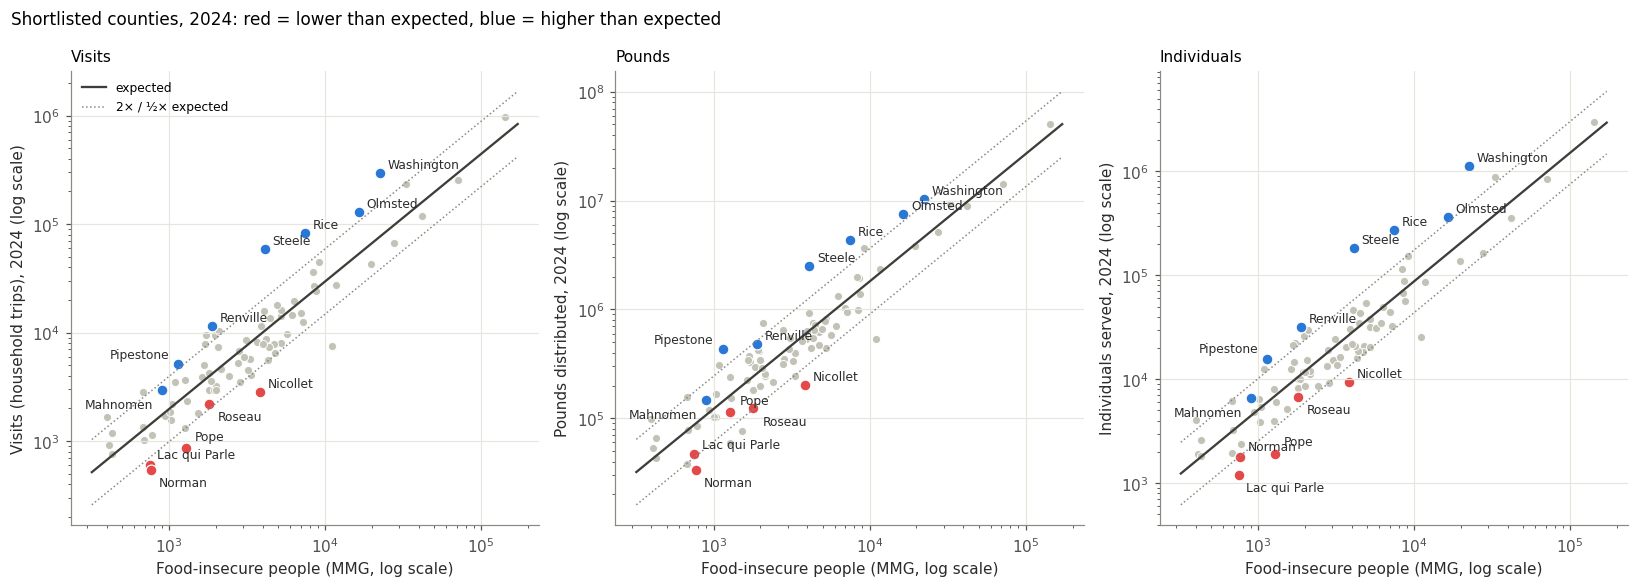

In [57]:
YEAR_SHOW = 2024
# Small manual label offsets (points) so neighbouring labels don't overlap: (dx, dy, alignment)
# Norman and Lac qui Parle almost overlap: put the label of whichever point is lower in that panel underneath it.
NUDGE = {"Roseau": (6, -11, "left"),
         "Pope": (6, 5, "left"), "Mahnomen": (-6, -12, "right"), "Pipestone": (-6, 4, "right")}
d_show = mm[mm["year"] == YEAR_SHOW]
low_names = set(shortlist.loc[shortlist["direction"] == "lower than expected", "county"])
high_names = set(shortlist.loc[shortlist["direction"] == "higher than expected", "county"])

fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))
for ax, m in zip(axes, METRICS):
    fit = fits[(fits["year"] == YEAR_SHOW) & (fits["metric"] == m)].iloc[0]
    xs = np.linspace(d_show["fi_persons"].min() * 0.8, d_show["fi_persons"].max() * 1.2, 100)
    expected_line = d_show[f"{m}_expected"].iloc[0] / d_show["fi_persons"].iloc[0] ** fit["slope"] * xs ** fit["slope"]
    ax.plot(xs, expected_line, color="#3d3d3a", lw=1.5, label="expected")
    ax.plot(xs, expected_line * 2, color="#8a8984", lw=1, ls=":", label="2× / ½× expected")
    ax.plot(xs, expected_line / 2, color="#8a8984", lw=1, ls=":")
    other = ~d_show["county"].isin(low_names | high_names)
    ax.scatter(d_show.loc[other, "fi_persons"], d_show.loc[other, m], s=28, color="#c3c2b7", edgecolor="white", linewidth=0.6)
    for names, marker_color in [(low_names, "#e34948"), (high_names, "#2a78d6")]:
        sel = d_show[d_show["county"].isin(names)]
        ax.scatter(sel["fi_persons"], sel[m], s=50, color=marker_color, edgecolor="white", linewidth=0.8)
        for _, r in sel.iterrows():
            dx, dy, ha = NUDGE.get(r["county"], (5, 3, "left"))
            if r["county"] in ("Norman", "Lac qui Parle"):
                other = "Lac qui Parle" if r["county"] == "Norman" else "Norman"
                dy = 4 if r[m] > d_show.loc[d_show["county"] == other, m].iloc[0] else -11
            ax.annotate(r["county"], (r["fi_persons"], r[m]), xytext=(dx, dy), textcoords="offset points",
                        ha=ha, fontsize=8, color="#2b2b2b")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Food-insecure people (MMG, log scale)")
    ax.set_ylabel(f"{LABEL[m]}, {YEAR_SHOW} (log scale)")
    ax.set_title(NICE[m], loc="left", fontsize=10)
axes[0].legend(frameon=False, fontsize=8, loc="upper left")
fig.suptitle(f"Shortlisted counties, {YEAR_SHOW}: red = lower than expected, blue = higher than expected",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

The shortlisted counties sit on or beyond the dotted 2× / ½× lines across all three metrics, so they are not borderline cases. They are **not just the biggest or smallest counties**:
- **Lower group:** small to mid-size, from about 750 food-insecure people (Lac qui Parle, Norman) to 3,800 (Nicollet).
- **Higher group:** from Mahnomen (~900) to Washington (~22,000).
- **2024 is shown,** so Mahnomen, which faded that year, sits closer to the line than it did in 2022–2023.

## 24. Save the mismatch tables for Stage 4

Two new files in `Data/processed/`. The existing cleaned files are not touched.

| File | One row = | Contents |
|---|---|---|
| `q1_county_year_mismatch.csv` | county × year (86 × 3, plus Wilkin) | need, activity, expected activity, gap, flag and reporting concern for each metric |
| `q1_county_mismatch_summary.csv` | county (87) | persistence per metric, cross-metric consistency, direction, size of mismatch, reporting sensitivity, method agreement, shortlist flag |

Wilkin (no food shelf in the data) is included with blank gaps and a note, so it isn't silently missing.

In [58]:
year_cols = (["fips", "county", "year", "fi_rate", "fi_persons", "population", "need_rate_vs_state",
              "months_reported", "site_months", "site_months_missing", "share_site_months_missing", "incomplete",
              "typo_fixed_rows"]
             + [f"{m}{s}" for m in METRICS for s in ["", "_expected", "_gap", "_flag", "_report_concern",
                                                     "_share_suspect", "_gap_B", "_gap_C"]])
wilkin = df.loc[df["visits"].isna(), ["fips", "county", "year", "fi_rate", "fi_persons", "population"]]
county_year_out = (pd.concat([mm[year_cols], wilkin], ignore_index=True)
                     .assign(note=lambda d: np.where(d["visits"].isna(), "no food shelf in data; not scored", ""))
                     .sort_values(["county", "year"]))

pattern_wide = per.pivot(index="fips", columns="metric", values="pattern_clean").add_suffix("_pattern")
gap_wide = per.pivot(index="fips", columns="metric", values="mean_gap").add_suffix("_mean_gap")
summary_out = (county_summary.merge(pattern_wide, on="fips").merge(gap_wide, on="fips"))
wilkin_row = (df[df["county"] == "Wilkin"].groupby(["fips", "county"], as_index=False)["fi_rate"].mean()
                .rename(columns={"fi_rate": "mean_fi_rate"})
                .assign(direction="not scored (no food shelf in data)", shortlist=False))
summary_out = pd.concat([summary_out, wilkin_row], ignore_index=True).sort_values("county")
count_cols = ["metrics_persistent_low", "metrics_persistent_high", "metrics_reporting_sensitive",
              "min_methods_agree", "one_year_or_mixed_flags"]
summary_out[count_cols] = summary_out[count_cols].astype("Int64")   # whole numbers; blank for Wilkin

county_year_out.to_csv(PROCESSED / "q1_county_year_mismatch.csv", index=False)
summary_out.to_csv(PROCESSED / "q1_county_mismatch_summary.csv", index=False)
print("q1_county_year_mismatch.csv:", county_year_out.shape)
print("q1_county_mismatch_summary.csv:", summary_out.shape)

q1_county_year_mismatch.csv: (261, 38)
q1_county_mismatch_summary.csv: (87, 21)


## 25. Summary: counties where need and food shelf activity break down

**How a mismatch was defined.**
- **Expected activity:** what counties with a similar *number of food-insecure people* (MMG) typically record. It comes from a log-scale regression fitted separately for each year and metric (Method A).
- **Flagged:** a county-year whose activity is at least **2×** or at most **½** of expected.
- **Persistent:** flagged in the same direction in **at least 2 of 3 years**, counting only years without a reporting concern.
- **Why this method:** it uses only need and activity, it is size-neutral (unlike the per-resident and per-food-insecure-person versions, which favor big counties), and two alternative methods were used as robustness checks.

**1. Lower activity than expected (persistent).**
- Visits: Nicollet, Pope, Norman, Lac qui Parle, Benton, Roseau, Brown
- Pounds: Nicollet, Norman, Benton, Lincoln, Roseau, Lac qui Parle, Nobles, Chippewa
- Individuals: Pope, Nicollet, Lac qui Parle, Benton, Brown, Norman, Roseau

**2. Higher activity than expected (persistent).**
- Visits: Steele, Washington, Rice, Renville, Cook, Mahnomen, Koochiching, Dodge, Olmsted, Kittson, Houston, Mille Lacs
- Pounds: Steele, Rice, Mahnomen, Kittson, Pipestone, Washington, Cook, Jackson, Renville
- Individuals: Steele, Washington, Rice, Renville, Cook, Mahnomen, Pipestone, Dodge, Anoka, Olmsted, Watonwan, Jackson, Kittson, Mille Lacs

**3–5. By metric:** see section 20a. The lists overlap heavily. Visits and Individuals flag nearly the same counties.

**6. Across multiple metrics.**
- **All three:** lower — Nicollet, Lac qui Parle, Benton, Norman, Roseau; higher — Steele, Washington, Rice, Renville, Mahnomen, Cook, Kittson.
- **Two:** Pope, Brown (low); Mille Lacs, Dodge, Olmsted, Jackson, Pipestone (high).
- **Pounds only:** Nobles, Chippewa, Lincoln, all low. This is a food-per-visit pattern rather than a general need mismatch.

**7. Persistent across 2022–2024.**
- **Flagged all 3 years on at least one metric:** Nicollet, Pope, Lac qui Parle, Norman, Lincoln (low); Steele, Washington, Rice, Renville, Dodge, Koochiching, Cook, Jackson, Anoka (high).
- **Changing over time:** Steele and Rice are growing. Mahnomen, Mille Lacs and Benton are fading.

**8. One-year only.** Scott (low on all metrics, 2024), Wabasha (high on all metrics, 2024), Todd, Swift, Blue Earth, Itasca, plus Grant and Stevens (both with reporting concerns). No county flips direction.

**9. Reporting quality.** All five flagged results with a reporting concern are "lower" flags in county-years with missing months (Grant 2022, Stevens 2024, Douglas 2023).
- **Douglas** is the only county whose classification changes: its visits look persistently low, but one of the two flagged years is incomplete, so it is labeled reporting-sensitive, not persistent.
- **No "higher" flag** is driven by flagged spikes or summed duplicates.
- **No shortlisted county** has a reporting concern.

### Shortlist for Stage 4

| Lower than expected | Higher than expected |
|---|---|
| Nicollet, Pope, Lac qui Parle, Norman, Roseau | Steele, Washington, Rice, Renville, Mahnomen, Pipestone, Olmsted |

**Second tier:** Benton, Cook, Kittson, Jackson (method-dependent); Brown, Dodge, Mille Lacs (smaller gap). Wilkin is a separate case: it has no food shelf in the data, so it could not be scored.

### Things to keep in mind before explaining these counties
- **"Expected" is relative to other Minnesota counties,** not an absolute standard. "Higher than expected" does not mean "over-served", and "lower" does not mean "under-served".
- **Need was measured as the number of food-insecure people.** By MMG's need *rate*, only Norman among the low counties is above the state median. The "high need / low activity" story is narrower than "low activity relative to need".
- **Activity is recorded where the food shelf is, not where clients live.** Some high and low counties may be linked (e.g. neighbors), so Stage 4 should look at geography before treating each county independently.
- **The ×2 cutoff is a judgment call.** The continuous gaps are saved, so the shortlist can be checked with a different cutoff.
- **MMG figures are model estimates,** and MMG 2024 comes from a newer release. Part of any mismatch could come from the estimate rather than from the food shelves.
- **These are associations.** Nothing here says *why* a county differs. That is Stage 4, which should use the saved tables (`q1_county_year_mismatch.csv`, `q1_county_mismatch_summary.csv`) rather than re-deriving the list.

---

# Part 4: What county characteristics might help explain the mismatches?

Part 3 identified counties where food shelf activity is persistently **higher** or **lower** than expected from Feeding America's estimated number of food-insecure people. Now we ask:

> **Do characteristics of those counties offer plausible explanations for why need estimates and food shelf activity don't line up?**

This is an **investigation, not a proof**. With 86 counties and observational data, we can find **associations** and patterns that are **consistent with** an explanation, never causes. We also expect that **different counties may mismatch for different reasons**, so "no single explanation" is an acceptable answer.

**Approach**
1. Choose a small set of interpretable county characteristics (section 26) and check whether SNAP can be joined correctly (section 27).
2. Build and validate the county characteristic table (section 28).
3. Profile the Part 3 shortlist against the state (section 29).
4. Compare the "lower than expected" and "higher than expected" groups with all other counties (section 30).
5. Check, across all 86 counties, whether the size of the mismatch is associated with each characteristic (sections 31–32).
6. Split each mismatch into "number of sites" vs. "activity per site" (section 33).
7. Separate likely data-quality mismatches from substantive ones (section 34).
8. Final county profiles with cautious possible explanations (section 35), then the full Q1 synthesis.

## 26. Which characteristics, and why

We keep the list short. Each variable has a clear reason for possibly affecting food shelf use *beyond* what MMG's need estimate captures:

| Characteristic | Source | Calculation | Why it might matter |
|---|---|---|---|
| **Food-shelf sites per 10,000 residents** | `foodshelf_county_month.csv` | average monthly `n_sites` (all non-meal sites operating that month, **whether or not they reported**) ÷ ACS population × 10,000 | Availability: more places to get food may mean more recorded activity |
| **Visits per reporting site-month** | `foodshelf_county_month.csv` | annual visits ÷ site-months that reported | Not an explanation by itself. It tells us whether a county's activity comes from *many* sites or *busy* sites (section 33) |
| **Poverty rate** (%) | `poverty_2022_2024_clean.csv` (ACS S1701) | as published | Economic hardship that MMG's model may not fully capture |
| **No-vehicle households** (%) | `vehicle_access_2022_2024_clean.csv` (ACS B08201) | as published, with its margin of error | One possible access barrier. Not the same as "no transportation" |
| **Rurality** | MMG `rucc_2023` / `rural` | RUCC 1–3 metro, 4–9 nonmetro | Distance and service patterns differ between metro and rural areas |
| **Food-insecure people above the SNAP income limit** (%) | MMG `pct_fi_above_snap_threshold` | as published | People who can't get SNAP may rely more on food shelves |
| **SNAP participation rate** (%) | `snap_2022_2024_clean.csv` | average monthly SNAP people ÷ ACS population × 100, **only where the agency matches one county** (section 27) | More need met by SNAP might mean less food shelf use, or SNAP enrollment might track the same hardship |

**Deliberately not used:**
- **Distance to the nearest food shelf.** The cleaned data has no site locations (no addresses or coordinates). Building it would need geocoding `Organization.xlsx`, which is beyond the cleaned data available to us. It is noted as a gap.
- **Other poverty variants** (deep poverty, below-185%, child/senior poverty). They correlate strongly with the poverty rate and would add columns without adding new information.
- **`limited_vehicle_rate`.** It overlaps heavily with no-vehicle households and is dominated by one-car households, which are common and not necessarily a barrier.

**Time handling.** ACS values are **5-year estimates** (the "2024" value covers 2020–2024), so the three years overlap heavily. We treat all characteristics as **stable county traits** and average 2022–2024, rather than interpreting year-to-year changes. The Part 3 mismatch is also summarized as a 3-year average gap (`mean_gap_all`), with its persistence information kept alongside.

## 27. Can SNAP be joined to counties correctly?

The README warns that SNAP is reported by **county agency**, not by county, and that `county_code` is the state's own numbering, **not FIPS**. We check the structure before using it.

In [59]:
snap = pd.read_csv(PROCESSED / "snap_2022_2024_clean.csv")
print("SNAP rows:", snap.shape, "| years:", sorted(snap["year"].unique()),
      "| months per year:", snap.groupby("year")["month"].nunique().to_dict())
print("Duplicate agency-year-month rows:", int(snap.duplicated(["county_code", "year", "month"]).sum()))

# Match agency names to official county names (uppercase) -> FIPS. We never treat county_code as FIPS.
county_names = mmg[["fips", "county"]].drop_duplicates().assign(agency=lambda d: d["county"].str.upper())
agencies = snap[["county_code", "county"]].drop_duplicates().rename(columns={"county": "agency"})
agency_map = agencies.merge(county_names, on="agency", how="left", validate="one_to_one")

print(f"\nAgencies: {len(agencies)} | matched one-to-one to a single county: {agency_map['fips'].notna().sum()}")
print("Agencies that are NOT a single county:", agency_map.loc[agency_map["fips"].isna(), "agency"].tolist())
print("Counties with no agency of their own:", sorted(set(county_names["county"]) - set(agency_map["county"].dropna())))

SNAP rows: (3132, 7) | years: [2022, 2023, 2024] | months per year: {2022: 12, 2023: 12, 2024: 12}
Duplicate agency-year-month rows: 0

Agencies: 87 | matched one-to-one to a single county: 82
Agencies that are NOT a single county: ['WPHS', 'MNPRAIRIE', 'MILLE-LACS-BAND TRIBE', 'WHITE EARTH NATION', 'RED LAKE INDIAN RESV']
Counties with no agency of their own: ['Dodge', 'Grant', 'Pope', 'Steele', 'Waseca']


Three kinds of agency need different handling:

| Agency type | Agencies | Decision |
|---|---|---|
| **Single county** | 82 agencies named after one county | Join by name → FIPS (checked one-to-one above). Usable. |
| **Combined counties** | `MNPRAIRIE` = Dodge + Steele + Waseca; `WPHS` = Grant + Pope | We **cannot** split the totals between counties. We compute a **regional** rate (agency total ÷ combined population), show it only in profiles **labeled as regional**, and leave these 5 counties out of all county-level SNAP statistics. |
| **Tribal nations** | White Earth Nation, Red Lake, Mille Lacs Band | Their cases are counted separately from the county agencies, and their service areas overlap several counties, so they can't be assigned to one county. As a result, **county-agency SNAP counts are too low** in counties overlapping these reservations. |

**Which counties overlap the tribal service areas?** The SNAP file doesn't say, so we use the reservations' main counties: **White Earth** — Mahnomen, Becker, Clearwater; **Red Lake** — Beltrami, Clearwater; **Mille Lacs Band** — Mille Lacs, Pine, Aitkin. This list is outside knowledge, not from the data, so we treat it cautiously: these 7 counties are **excluded from SNAP statistics** rather than corrected. The check below supports the concern.

In [60]:
TRIBAL_OVERLAP = ["Mahnomen", "Becker", "Clearwater", "Beltrami", "Mille Lacs", "Pine", "Aitkin"]
COMBINED_AGENCY = {"MNPRAIRIE": ["Dodge", "Steele", "Waseca"], "WPHS": ["Grant", "Pope"]}

pov_full = (pd.read_csv(PROCESSED / "poverty_2022_2024_clean.csv", dtype={"county_geoid": str})
              .rename(columns={"county_geoid": "fips"}))

# Average monthly SNAP participants per agency-year
snap_year = snap.groupby(["county", "year"], as_index=False)["snap_people"].mean().rename(columns={"county": "agency"})

# County-level rate: single-county agencies only
snap_county = (snap_year.merge(agency_map.dropna(subset=["fips"])[["agency", "fips"]], on="agency", how="inner")
                        .merge(pov_full[["fips", "year", "population", "poverty_rate"]], on=["fips", "year"],
                               how="left", validate="one_to_one"))
snap_county["snap_rate"] = snap_county["snap_people"] / snap_county["population"] * 100
snap_county = snap_county.merge(county_names[["fips", "county"]], on="fips")

# Regional rates for the two combined agencies (shown in profiles only, clearly labeled)
regional_rows = []
for agency, members in COMBINED_AGENCY.items():
    member_pop = (pov_full[pov_full["county"].isin([m.upper() for m in members])]
                  .groupby("year")["population"].sum())
    people = snap_year[snap_year["agency"] == agency].set_index("year")["snap_people"]
    rate = (people / member_pop * 100).mean()
    for m in members:
        regional_rows.append({"county": m, "snap_rate_regional": rate, "snap_region": f"{agency} ({' + '.join(members)})"})
snap_regional = pd.DataFrame(regional_rows)

# Evidence check: SNAP participation relative to poverty, tribal-overlap counties vs. the rest
chk = snap_county.groupby("county")[["snap_rate", "poverty_rate"]].mean()
chk["snap_per_poverty_point"] = chk["snap_rate"] / chk["poverty_rate"]
chk["group"] = np.where(chk.index.isin(TRIBAL_OVERLAP), "tribal overlap", "other single-county agencies")
display(chk.groupby("group")["snap_per_poverty_point"].median().round(2).rename("median SNAP rate ÷ poverty rate").to_frame())
chk.loc[TRIBAL_OVERLAP, ["snap_rate", "poverty_rate", "snap_per_poverty_point"]].round(2)

,median SNAP rate ÷ poverty rate
group,
other single-county agencies,0.75
tribal overlap,0.64


,snap_rate,poverty_rate,snap_per_poverty_point
county,,,
Mahnomen,5.49,19.93,0.28
Becker,6.46,11.60,0.56
Clearwater,8.38,11.70,0.72
Beltrami,8.97,16.07,0.56
Mille Lacs,8.78,10.63,0.83
Pine,10.11,10.73,0.94
Aitkin,8.10,12.60,0.64


**SNAP decision**
- **82 single-county agencies** join cleanly by name. The check above confirms the tribal concern: in the tribal-overlap counties, SNAP participation is lower relative to poverty (median ratio 0.64 vs. 0.75 elsewhere).
- **Mahnomen** stands out most: it has 19.9% poverty but only 5.5% SNAP participation (ratio 0.28). That fits with much of its SNAP caseload being handled by White Earth Nation and so missing from the county count.
- **The effect is not uniform:** Mille Lacs and Pine look normal. To stay consistent, and because the overlap list comes from outside knowledge, **all 7 are excluded** rather than selectively corrected.

**Result:** county-level SNAP participation is used for **74 counties**.
- **Steele and Pope** (both shortlisted) only get **regional** rates (MNPRAIRIE and WPHS), shown in their profiles and labeled.
- **Mahnomen's SNAP is not usable.**
- SNAP is therefore a **partial** variable. It is used in comparisons only where valid, and it is left out of the regression.

## 28. Build and validate the county characteristic table

Every join is on **FIPS + year** with `validate="one_to_one"` so a many-to-many join would raise an error. We check row counts after each step.

In [61]:
veh = (pd.read_csv(PROCESSED / "vehicle_access_2022_2024_clean.csv", dtype={"county_geoid": str})
         .rename(columns={"county_geoid": "fips"}))
for name, d in [("poverty", pov_full), ("vehicle access", veh), ("MMG", mmg)]:
    print(f"{name:15s} rows={len(d)} years={sorted(d['year'].unique())} counties={d['fips'].nunique()} "
          f"duplicate county-years={int(d.duplicated(['fips', 'year']).sum())}")

sites_cy = (fs_month[fs_month["year"].between(2022, 2024)]
            .groupby(["fips", "year"], as_index=False)
            .agg(avg_sites=("n_sites", "mean"), avg_sites_reported=("n_sites_reported", "mean")))

chars_cy = (pov_full[["fips", "year", "population", "poverty_rate"]]
            .merge(veh[["fips", "year", "no_vehicle_rate", "no_vehicle_rate_moe"]], on=["fips", "year"], how="left", validate="one_to_one")
            .merge(mmg[["fips", "year", "rucc_2023", "rural", "pct_fi_above_snap_threshold"]], on=["fips", "year"], how="left", validate="one_to_one")
            .merge(sites_cy, on=["fips", "year"], how="left", validate="one_to_one")
            .merge(snap_county[["fips", "year", "snap_rate"]], on=["fips", "year"], how="left", validate="one_to_one"))
chars_cy["sites_per_10k"] = chars_cy["avg_sites"] / chars_cy["population"] * 10_000
chars_cy["pct_fi_above_snap_threshold"] = chars_cy["pct_fi_above_snap_threshold"] * 100   # to percent

print("\nCounty-year rows:", len(chars_cy), "| counties:", chars_cy["fips"].nunique(),
      "| duplicate county-years:", int(chars_cy.duplicated(["fips", "year"]).sum()))
print("Missing values:\n", chars_cy.isna().sum()[lambda s: s > 0].to_string())

poverty         rows=261 years=[2022, 2023, 2024] counties=87 duplicate county-years=0
vehicle access  rows=261 years=[2022, 2023, 2024] counties=87 duplicate county-years=0
MMG             rows=261 years=[2022, 2023, 2024] counties=87 duplicate county-years=0

County-year rows: 261 | counties: 87 | duplicate county-years: 0
Missing values:
 snap_rate    15


In [62]:
# Activity per reporting site-month, from the Part 3 county-year table (activity / site-months that reported)
mm["reported_site_months"] = mm["site_months"] - mm["site_months_missing"]
mm["visits_per_site_month"] = mm["visits"] / mm["reported_site_months"]

# Average 2022-2024 into stable county characteristics (ACS windows overlap, so we don't read year-to-year changes)
chars = (chars_cy.groupby("fips", as_index=False)
         .agg(population=("population", "mean"), poverty_rate=("poverty_rate", "mean"),
              no_vehicle_rate=("no_vehicle_rate", "mean"), no_vehicle_rate_moe=("no_vehicle_rate_moe", "mean"),
              rucc_2023=("rucc_2023", "first"), rural=("rural", "first"),
              pct_fi_above_snap_threshold=("pct_fi_above_snap_threshold", "mean"),
              avg_sites=("avg_sites", "mean"), avg_sites_reported=("avg_sites_reported", "mean"),
              sites_per_10k=("sites_per_10k", "mean"), snap_rate=("snap_rate", "mean"))
         .merge(mm.groupby("fips", as_index=False)["visits_per_site_month"].mean(), on="fips", how="left", validate="one_to_one"))

# SNAP: exclude tribal-overlap counties from county-level SNAP (combined-agency counties are already blank)
chars = chars.merge(county_names[["fips", "county"]], on="fips", validate="one_to_one")
chars["snap_status"] = np.select(
    [chars["county"].isin(TRIBAL_OVERLAP), chars["county"].isin(snap_regional["county"]), chars["snap_rate"].notna()],
    ["excluded: tribal agency overlap (understated)", "regional only: combined agency", "county agency"], default="missing")
chars.loc[chars["county"].isin(TRIBAL_OVERLAP), "snap_rate"] = np.nan
chars = chars.merge(snap_regional, on="county", how="left", validate="one_to_one")

# Join to the Part 3 county summary (86 scored counties; Wilkin has no food shelf and was not scored)
gaps_wide = per.pivot(index="fips", columns="metric", values="mean_gap").add_suffix("_mean_gap").reset_index()
prof = (county_summary[["fips", "county", "direction", "consistency", "mean_gap_all", "times_expected_all",
                        "need_rate_vs_state", "mean_fi_rate", "metrics_reporting_sensitive", "priority"]]
        .merge(gaps_wide, on="fips", how="left", validate="one_to_one")
        .merge(chars.drop(columns="county"), on="fips", how="left", validate="one_to_one"))
prof["direction"] = prof["direction"].replace("", "no persistent mismatch")

print("Profile table:", prof.shape, "| counties:", prof["fips"].nunique())
print("Counties in characteristics but not scored in Part 3:", sorted(set(chars["county"]) - set(prof["county"])))
print("SNAP status:", prof["snap_status"].value_counts().to_dict())
print("Missing values in characteristics:\n", prof[["poverty_rate", "no_vehicle_rate", "rucc_2023", "sites_per_10k",
      "visits_per_site_month", "pct_fi_above_snap_threshold", "snap_rate"]].isna().sum().to_string())

Profile table: (86, 28) | counties: 86
Counties in characteristics but not scored in Part 3: ['Wilkin']
SNAP status: {'county agency': 74, 'excluded: tribal agency overlap (understated)': 7, 'regional only: combined agency': 5}
Missing values in characteristics:
 poverty_rate                    0
no_vehicle_rate                 0
rucc_2023                       0
sites_per_10k                   0
visits_per_site_month           0
pct_fi_above_snap_threshold     0
snap_rate                      12


**Validation**
- Every source has 261 rows (87 counties × 3 years) with no duplicate county-years.
- Every join is one-to-one, and the characteristic table keeps all 261 rows.
- The only missing values are SNAP for the 5 combined-agency counties (15 county-years), which is intentional.
- The profile table has the 86 counties scored in Part 3. Wilkin (no food shelf) is kept in the saved file but has no mismatch score.
- `n_sites` counts sites that **existed** each month, whether or not they reported. So "sites per 10k" measures **availability**, not reporting quality, which stays in Part 3's flags.

## 29. Profile of the shortlisted counties vs. the state

For each shortlisted (and second-tier) county, every characteristic is shown as a **percentile among Minnesota's 86 scored counties** (50 = state median). The cell text shows the actual value.
- **Purple** = high relative to other counties, **orange** = low. These colors are neutral: neither direction is "good" or "bad".
- **RUCC:** a higher percentile = more rural.

State medians (86 counties):
Sites per 10k residents               1.19
Visits per site-month               175.68
Poverty rate %                        9.98
No-vehicle households %               5.10
RUCC (higher = more rural)            6.00
Food-insecure above SNAP limit %     32.72
SNAP participation %                  7.11


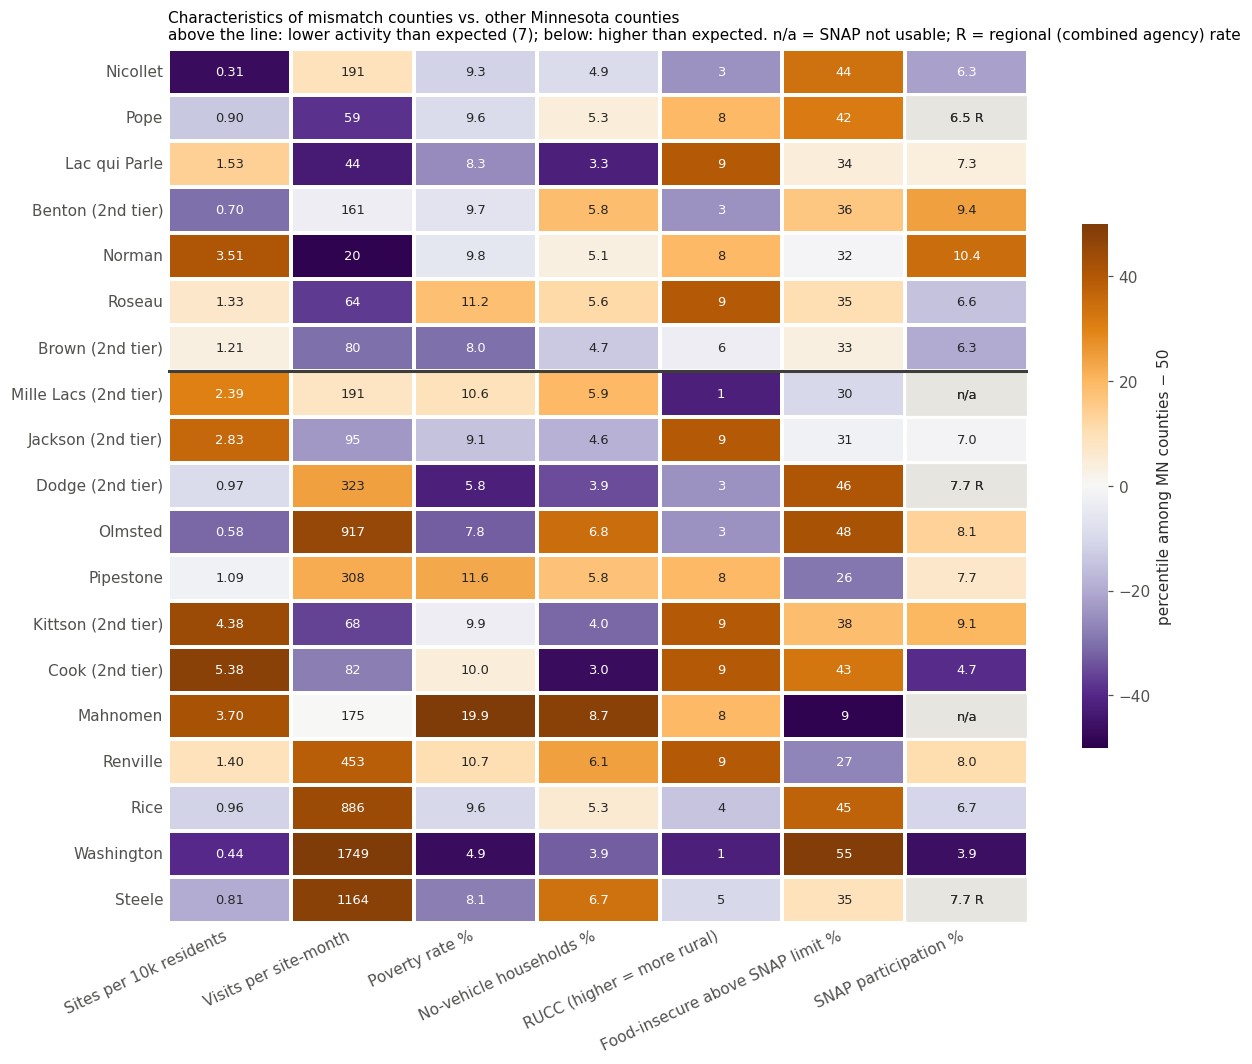

In [63]:
CHAR = {  # column -> short label for tables/plots
    "sites_per_10k": "Sites per 10k residents",
    "visits_per_site_month": "Visits per site-month",
    "poverty_rate": "Poverty rate %",
    "no_vehicle_rate": "No-vehicle households %",
    "rucc_2023": "RUCC (higher = more rural)",
    "pct_fi_above_snap_threshold": "Food-insecure above SNAP limit %",
    "snap_rate": "SNAP participation %",
}
state_median = prof[list(CHAR)].median()
print("State medians (86 counties):")
print(state_median.round(2).rename(index=CHAR).to_string())

pct = prof[list(CHAR)].rank(pct=True) * 100
focus = prof[prof["priority"].isin(["shortlist", "second tier"])].copy()
focus["order"] = focus["mean_gap_all"]
focus = focus.sort_values("order")
labels = [f"{c}{'' if p == 'shortlist' else ' (2nd tier)'}" for c, p in zip(focus["county"], focus["priority"])]

pct_mat = pct.loc[focus.index, list(CHAR)].set_axis(labels).rename(columns=CHAR)
val_fmt = {"sites_per_10k": "{:.2f}", "visits_per_site_month": "{:.0f}", "poverty_rate": "{:.1f}",
           "no_vehicle_rate": "{:.1f}", "rucc_2023": "{:.0f}", "pct_fi_above_snap_threshold": "{:.0f}", "snap_rate": "{:.1f}"}
ann = focus[list(CHAR)].apply(lambda col: col.map(lambda v: "n/a" if pd.isna(v) else val_fmt[col.name].format(v)))
for i, (_, r) in enumerate(focus.iterrows()):  # show the regional SNAP rate, marked "R"
    if pd.notna(r["snap_rate_regional"]):
        ann.iloc[i, list(CHAR).index("snap_rate")] = f"{r['snap_rate_regional']:.1f} R"
ann = ann.set_axis(labels).rename(columns=CHAR)

fig, ax = plt.subplots(figsize=(11.5, 0.42 * len(focus) + 1.8))
missing = pct_mat.isna()
sns.heatmap((pct_mat - 50).fillna(0), cmap="PuOr_r", center=0, vmin=-50, vmax=50, annot=ann, fmt="", annot_kws={"fontsize": 8.5},
            linewidths=1.5, linecolor="white", cbar_kws={"label": "percentile among MN counties − 50", "shrink": 0.6}, ax=ax)
# Cells without a county-level value (SNAP not usable / regional only): grey, with their label
from matplotlib.patches import Rectangle
for (i, j) in zip(*np.where(missing.to_numpy())):
    ax.add_patch(Rectangle((j, i), 1, 1, facecolor="#e6e5e0", edgecolor="white", lw=1.5))
    ax.text(j + 0.5, i + 0.5, ann.iloc[i, j], ha="center", va="center", fontsize=8.5, color="#2b2b2b")
n_low = int((focus["mean_gap_all"] < 0).sum())
ax.axhline(n_low, color="#3d3d3a", lw=2)
ax.grid(False); ax.tick_params(length=0); ax.set_xlabel(""); ax.set_ylabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.set_title("Characteristics of mismatch counties vs. other Minnesota counties\n"
             f"above the line: lower activity than expected ({n_low}); below: higher than expected. "
             "n/a = SNAP not usable; R = regional (combined agency) rate", loc="left", fontsize=10)
plt.tight_layout()
plt.show()

In [64]:
# Vehicle access: is each county's difference from the state median larger than its margin of error?
veh_check = focus[["county", "direction", "no_vehicle_rate", "no_vehicle_rate_moe"]].copy()
veh_check["diff_from_state_median"] = veh_check["no_vehicle_rate"] - state_median["no_vehicle_rate"]
veh_check["clearly_different"] = veh_check["diff_from_state_median"].abs() > veh_check["no_vehicle_rate_moe"]
veh_check.round(2)

,county,direction,no_vehicle_rate,no_vehicle_rate_moe,diff_from_state_median,clearly_different
51,Nicollet,lower than expected,4.89,1.20,-0.21,False
60,Pope,lower than expected,5.30,1.50,0.20,False
36,Lac qui Parle,lower than expected,3.29,1.00,-1.81,True
4,Benton,lower than expected,5.79,1.28,0.70,False
53,Norman,lower than expected,5.14,1.75,0.04,False
67,Roseau,lower than expected,5.62,1.50,0.53,False
7,Brown,lower than expected,4.73,0.96,-0.36,False
47,Mille Lacs,higher than expected,5.92,1.12,0.82,False
31,Jackson,higher than expected,4.58,1.41,-0.52,False
19,Dodge,higher than expected,3.90,1.18,-1.20,True


**What the profile shows**
- **Lower-than-expected counties don't share a hardship profile.**
  - Poverty and no-vehicle rates are near the state median for almost all of them, and their vehicle differences are **within the margin of error**.
  - The one exception, Lac qui Parle, has *fewer* car-less households than typical, the opposite of a vehicle-barrier story.
  - What most of them share is **quiet sites**: Norman, Lac qui Parle, Pope and Roseau are in the bottom 15% for visits per site-month. Nicollet and Benton instead have **few sites**.
- **Higher-than-expected counties fall into two distinct profiles:**
  - **Few but very busy sites:** Washington, Steele, Rice and Olmsted (plus Renville, Pipestone and Dodge). These are mostly metro or regional-center counties with low-to-median poverty and a **high share of food-insecure people above the SNAP income limit** (45–55% in Washington, Olmsted, Rice and Dodge).
  - **Many sites for a small population:** Cook, Kittson, Jackson, Mahnomen and Mille Lacs, mostly small rural counties.
- **Mahnomen is the hardship outlier:** the highest poverty (19.9%) and no-vehicle rate (8.7%) of these counties, and it still records **more** activity than expected. Limited vehicle access does not go with low activity here.

## 30. Do the mismatch groups differ systematically?

We compare three groups from Part 3: counties persistently **lower** than expected (10), **higher** than expected (16), and those with **no persistent mismatch** (60). For each characteristic we show the group median, plus a **Mann-Whitney test** asking whether each mismatch group's values tend to be higher or lower than the no-mismatch group's. It's a rank-based test, suitable for small groups and skewed data.

With groups this small, a non-significant result does **not** prove "no difference", and with 14 tests one p < 0.05 could appear by chance. We read these as supporting evidence, not verdicts.

In [65]:
from scipy.stats import mannwhitneyu

GROUPS = ["lower than expected", "no persistent mismatch", "higher than expected"]
group_tbl = prof.groupby("direction")[list(CHAR)].median().reindex(GROUPS).T.rename(index=CHAR)
group_tbl["n (low / none / high)"] = [
    "/".join(str(int(prof.loc[prof["direction"] == g, c].notna().sum())) for g in GROUPS) for c in CHAR]
for g, short in [("lower than expected", "p: low vs none"), ("higher than expected", "p: high vs none")]:
    ps = []
    for c in CHAR:
        a = prof.loc[prof["direction"] == g, c].dropna()
        b = prof.loc[prof["direction"] == "no persistent mismatch", c].dropna()
        ps.append(mannwhitneyu(a, b, alternative="two-sided").pvalue)
    group_tbl[short] = ps
group_tbl.round(3)

direction,lower than expected,no persistent mismatch,higher than expected,n (low / none / high),p: low vs none,p: high vs none
Sites per 10k residents,1.054,1.186,1.247,10/60/16,0.706,0.390
Visits per site-month,94.245,176.829,311.861,10/60/16,0.026,0.076
Poverty rate %,9.717,10.000,9.750,10/60/16,0.933,0.296
No-vehicle households %,5.218,5.058,5.547,10/60/16,0.973,0.814
RUCC (higher = more rural),7.500,6.000,6.000,10/60/16,0.171,0.908
Food-insecure above SNAP limit %,33.400,30.867,36.667,10/60/16,0.731,0.154
SNAP participation %,7.272,7.123,6.832,9/53/12,0.795,0.275


In [66]:
print("Rural (RUCC 4-9) share by group:")
rural_tbl = pd.crosstab(prof["direction"], prof["rural"].map({True: "rural", False: "metro"})).reindex(GROUPS)
rural_tbl["% rural"] = (rural_tbl["rural"] / rural_tbl.sum(axis=1) * 100).round(0)
rural_tbl

Rural (RUCC 4-9) share by group:


rural,metro,rural,% rural
direction,,,
lower than expected,2,8,80.0
no persistent mismatch,19,41,68.0
higher than expected,6,10,62.0


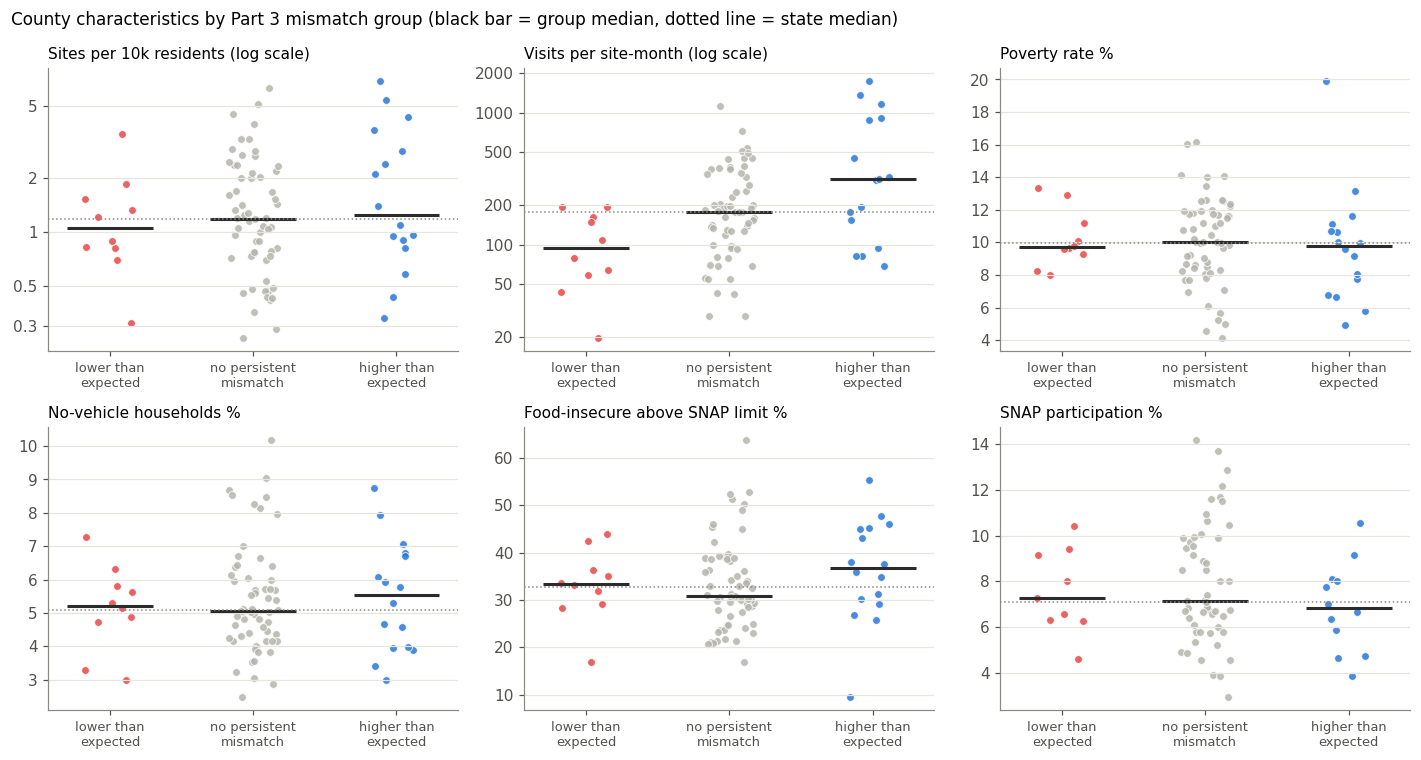

In [67]:
LOG_TICKS = {"sites_per_10k": [0.3, 0.5, 1, 2, 5], "visits_per_site_month": [20, 50, 100, 200, 500, 1000, 2000]}
GROUP_COLOR = {"lower than expected": "#e34948", "no persistent mismatch": "#b5b4ac", "higher than expected": "#2a78d6"}
plot_chars = ["sites_per_10k", "visits_per_site_month", "poverty_rate", "no_vehicle_rate",
              "pct_fi_above_snap_threshold", "snap_rate"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.flat, plot_chars):
    for i, g in enumerate(GROUPS):
        vals = prof.loc[prof["direction"] == g, c].dropna()
        jitter = np.random.default_rng(i).uniform(-0.18, 0.18, len(vals))
        ax.scatter(np.full(len(vals), i) + jitter, vals, s=26, color=GROUP_COLOR[g], alpha=0.85, edgecolor="white", linewidth=0.6)
        ax.hlines(vals.median(), i - 0.3, i + 0.3, color="#2b2b2b", lw=2)
    ax.axhline(state_median[c], color="#8a8984", lw=1, ls=":")
    if c in ("sites_per_10k", "visits_per_site_month"):
        ax.set_yscale("log")
        ax.set_yticks(LOG_TICKS[c]); ax.set_yticklabels([f"{t:g}" for t in LOG_TICKS[c]]); ax.minorticks_off()
    ax.set_xticks(range(3)); ax.set_xticklabels(["lower than\nexpected", "no persistent\nmismatch", "higher than\nexpected"], fontsize=8.5)
    ax.set_title(CHAR[c] + (" (log scale)" if c in ("sites_per_10k", "visits_per_site_month") else ""), loc="left", fontsize=10)
    ax.grid(axis="x", visible=False)
fig.suptitle("County characteristics by Part 3 mismatch group (black bar = group median, dotted line = state median)",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

**Group comparison**
- **Poverty, no-vehicle households and SNAP participation have almost identical medians** in all three groups. These characteristics do **not** separate the mismatch groups.
- **Rurality:** the lower group is a little more rural (80% vs. 68% of other counties), but the difference is not statistically clear (RUCC p ≈ 0.17). The higher group is not more metro either (62% rural). So "rural = low activity" is **not supported**.
- **Food-insecure above the SNAP limit** is somewhat higher in the higher group (median 37% vs. 31%), but not clearly so (p ≈ 0.15).
- **Visits per site-month separates the groups most clearly:** median 94 (lower) vs. 177 (no mismatch) vs. 312 (higher); lower vs. no mismatch p ≈ 0.03. Lower-than-expected counties tend to have **quiet** sites. Note this measure is partly built from activity, so it describes *where* the mismatch shows up rather than explaining it.
- **Site density medians are similar across groups** (1.05 / 1.19 / 1.25), and the groups overlap heavily. Its link to the mismatch shows up more in the continuous analysis below.

## 31. Across all counties: is the size of the mismatch associated with each characteristic?

Instead of three groups, we now use every county's **continuous** mismatch: the average gap from Part 3 (log2 of observed ÷ expected; positive = more activity than expected). We use Spearman correlations, which resist outliers (Part 2, section 8d), for the overall gap and for each metric separately.

In [68]:
gap_cols = {"mean_gap_all": "All metrics", "visits_mean_gap": "Visits", "pounds_mean_gap": "Pounds", "individuals_mean_gap": "Individuals"}
assoc_rows = []
for c in CHAR:
    row = {"characteristic": CHAR[c]}
    for gcol, glabel in gap_cols.items():
        sub = prof[[c, gcol]].dropna()
        rho, p = stats.spearmanr(sub[c], sub[gcol])
        row[glabel] = rho
        if gcol == "mean_gap_all":
            row["p (all metrics)"], row["n"] = p, len(sub)
    assoc_rows.append(row)
assoc = pd.DataFrame(assoc_rows).set_index("characteristic")
assoc.round(2)

,All metrics,p (all metrics),n,Visits,Pounds,Individuals
characteristic,,,,,,
Sites per 10k residents,0.25,0.02,86,0.26,0.19,0.23
Visits per site-month,0.23,0.03,86,0.25,0.22,0.25
Poverty rate %,-0.16,0.14,86,-0.16,-0.19,-0.14
No-vehicle households %,-0.09,0.40,86,-0.10,-0.12,-0.07
RUCC (higher = more rural),-0.03,0.80,86,-0.05,-0.02,-0.03
Food-insecure above SNAP limit %,0.12,0.26,86,0.10,0.18,0.11
SNAP participation %,-0.06,0.62,74,-0.07,-0.10,-0.05


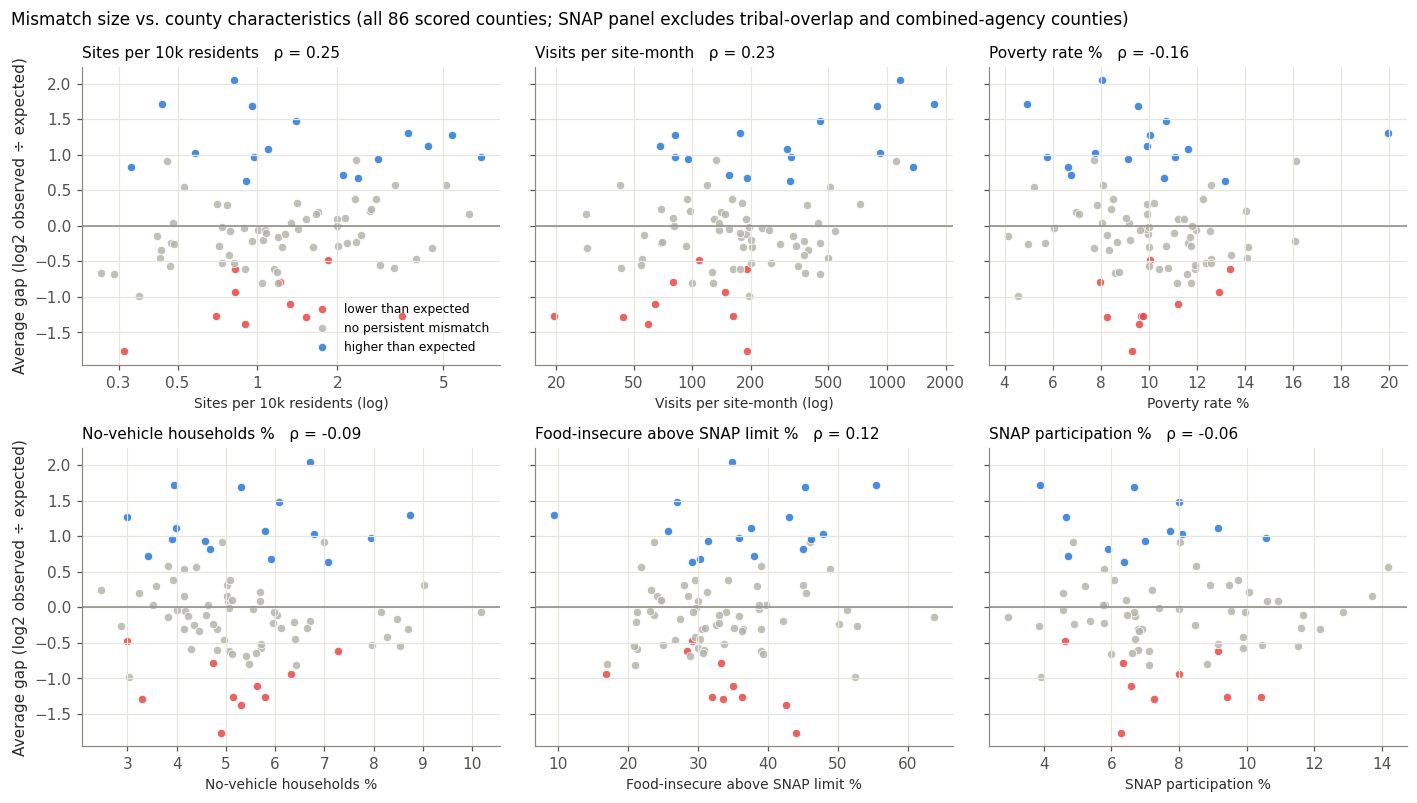

In [69]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.4), sharey=True)
for ax, c in zip(axes.flat, plot_chars):
    for g in GROUPS:
        sub = prof[prof["direction"] == g]
        ax.scatter(sub[c], sub["mean_gap_all"], s=30, color=GROUP_COLOR[g], alpha=0.85, edgecolor="white",
                   linewidth=0.6, label=g)
    ax.axhline(0, color="#8a8984", lw=1)
    if c in ("sites_per_10k", "visits_per_site_month"):
        ax.set_xscale("log")
        ax.set_xticks(LOG_TICKS[c]); ax.set_xticklabels([f"{t:g}" for t in LOG_TICKS[c]]); ax.minorticks_off()
    rho = assoc.loc[CHAR[c], "All metrics"]
    ax.set_title(f"{CHAR[c]}   ρ = {rho:.2f}", loc="left", fontsize=10)
    ax.set_xlabel(CHAR[c] + (" (log)" if c in ("sites_per_10k", "visits_per_site_month") else ""), fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("Average gap (log2 observed ÷ expected)")
axes[0, 0].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("Mismatch size vs. county characteristics (all 86 scored counties; SNAP panel excludes tribal-overlap and combined-agency counties)",
             x=0.01, ha="left", fontsize=11)
plt.tight_layout()
plt.show()

**All associations are weak.**
- **Strongest:** sites per 10,000 residents (ρ = +0.25, p ≈ 0.02) and visits per site-month (ρ = +0.23).
  - Counties with **more food shelf sites per resident** tend to record somewhat more activity than MMG's estimate suggests.
  - These two measures are strongly *negatively* related to each other (ρ ≈ −0.8): counties tend to have either many small sites or a few large ones. **Both extremes** show up among the higher-than-expected counties, which is why each correlation is only modest.
- **Poverty:** ρ = −0.16, not significant. If anything, poorer counties record slightly *less* activity than MMG implies. This is the opposite of "higher hardship → more activity than expected".
- **No-vehicle households, rurality and SNAP participation:** essentially zero (|ρ| ≤ 0.09).
- **By metric:** the pattern is the same for visits, pounds and individuals. Pounds has slightly stronger links with poverty (−0.19) and the above-SNAP-limit share (+0.18).

The scatterplots confirm there is no hidden curved pattern: the clouds are wide for every characteristic, and both mismatch groups are spread across the full range of poverty, vehicle access and SNAP.

## 32. A simple regression check

The characteristics are related to each other (e.g. poorer counties tend to be more rural). A single **linear regression** shows each characteristic's association with the mismatch **while holding the others constant**. It adds that one thing over the correlations above; it is not a predictive model.

- **Outcome:** `mean_gap_all`.
- **Predictors:** standardized (z-scores, so a coefficient is the change in gap per 1 standard deviation) — site density (log2, because a few tiny counties have very high values), poverty rate, no-vehicle rate, and share of food-insecure above the SNAP limit — plus a rural indicator.
- **Standard errors:** robust (HC3), which don't assume equal scatter everywhere.
- **SNAP is left out** of the regression, because including it would drop the 12 tribal-overlap and combined-agency counties.
- **`visits_per_site_month` is left out** because it is built from activity itself (it's part of the outcome, not an explanation).

In [70]:
import statsmodels.formula.api as smf

reg = prof.copy()
reg["log2_sites_per_10k"] = np.log2(reg["sites_per_10k"])
reg["rural_flag"] = reg["rural"].astype(int)
preds = ["log2_sites_per_10k", "poverty_rate", "no_vehicle_rate", "pct_fi_above_snap_threshold"]
for v in preds:
    reg[f"{v}_z"] = (reg[v] - reg[v].mean()) / reg[v].std()

print("Correlation among predictors (Spearman):")
display(reg[preds + ["rural_flag"]].corr(method="spearman").round(2))

model = smf.ols("mean_gap_all ~ log2_sites_per_10k_z + poverty_rate_z + no_vehicle_rate_z"
                " + pct_fi_above_snap_threshold_z + rural_flag", data=reg).fit(cov_type="HC3")
coef_tbl = pd.DataFrame({"coefficient": model.params, "95% low": model.conf_int()[0],
                         "95% high": model.conf_int()[1], "p": model.pvalues}).round(3)
print(f"n = {int(model.nobs)} counties | R² = {model.rsquared:.2f} | adjusted R² = {model.rsquared_adj:.2f}")
coef_tbl

Correlation among predictors (Spearman):


,log2_sites_per_10k,poverty_rate,no_vehicle_rate,pct_fi_above_snap_threshold,rural_flag
log2_sites_per_10k,1.00,0.16,-0.14,-0.33,0.38
poverty_rate,0.16,1.00,0.66,-0.66,0.31
no_vehicle_rate,-0.14,0.66,1.00,-0.39,0.04
pct_fi_above_snap_threshold,-0.33,-0.66,-0.39,1.00,-0.56
rural_flag,0.38,0.31,0.04,-0.56,1.00


n = 86 counties | R² = 0.11 | adjusted R² = 0.05


,coefficient,95% low,95% high,p
Intercept,0.027,-0.349,0.402,0.890
log2_sites_per_10k_z,0.254,0.092,0.416,0.002
poverty_rate_z,-0.015,-0.364,0.335,0.935
no_vehicle_rate_z,0.094,-0.128,0.316,0.408
pct_fi_above_snap_threshold_z,0.194,-0.084,0.471,0.171
rural_flag,-0.039,-0.547,0.470,0.881


**Regression result**
- **Together the characteristics explain little:** R² = 0.11 (adjusted 0.05). Most of the variation in mismatches is **not** captured by these county characteristics.
- **Site density is the only clear association** when the others are held constant: +0.25 per standard deviation (95% CI 0.09 to 0.42, p ≈ 0.002). That is roughly **1.2× more activity relative to expected** for each standard deviation more sites per resident.
- **Poverty, no-vehicle households and rurality** are close to zero with wide intervals. The share of food-insecure above the SNAP limit is positive (+0.19) but not clearly different from zero.
- **Caveat:** poverty, vehicle access and the SNAP-limit share are moderately correlated with each other (|ρ| ≈ 0.4–0.66), so their separate coefficients are imprecise. The overall conclusion, that hardship measures add little, does not depend on that.

## 33. Many sites, or busy sites?

A county's total activity is roughly **(number of sites) × (activity per site)**. For each shortlisted county we check which part is unusual. If a county is high because it has many sites, that points to **availability**. If it is high with few sites, its sites are **unusually busy**, which is consistent with large or regional sites (possibly drawing people from outside the county, which the data can't confirm).

In [71]:
decomp = focus[["county", "priority", "direction", "times_expected_all", "sites_per_10k", "visits_per_site_month"]].copy()
decomp["sites_per_10k_pctile"] = pct.loc[focus.index, "sites_per_10k"].round(0)
decomp["visits_per_site_pctile"] = pct.loc[focus.index, "visits_per_site_month"].round(0)

def driver(r):
    many, few = r["sites_per_10k_pctile"] >= 60, r["sites_per_10k_pctile"] <= 40
    busy, quiet = r["visits_per_site_pctile"] >= 60, r["visits_per_site_pctile"] <= 40
    if r["direction"] == "higher than expected":
        return "busy sites" if busy and not many else "many sites" if many and not busy else "both" if many and busy else "neither stands out"
    return "few sites" if few and not quiet else "quiet sites" if quiet and not few else "both" if few and quiet else "neither stands out"

decomp["main_driver"] = decomp.apply(driver, axis=1)
print("Percentile >= 60 counts as 'many'/'busy', <= 40 as 'few'/'quiet'.")
decomp.round(2)

Percentile >= 60 counts as 'many'/'busy', <= 40 as 'few'/'quiet'.


,county,priority,direction,times_expected_all,sites_per_10k,visits_per_site_month,sites_per_10k_pctile,visits_per_site_pctile,main_driver
51,Nicollet,shortlist,lower than expected,0.29,0.31,191.19,3.0,59.0,few sites
60,Pope,shortlist,lower than expected,0.39,0.90,59.06,36.0,12.0,both
36,Lac qui Parle,shortlist,lower than expected,0.41,1.53,43.97,64.0,7.0,quiet sites
4,Benton,second tier,lower than expected,0.42,0.70,160.95,20.0,47.0,few sites
53,Norman,shortlist,lower than expected,0.42,3.51,19.60,91.0,1.0,quiet sites
67,Roseau,shortlist,lower than expected,0.46,1.33,64.07,57.0,13.0,quiet sites
7,Brown,second tier,lower than expected,0.58,1.21,79.60,53.0,20.0,quiet sites
47,Mille Lacs,second tier,higher than expected,1.60,2.39,191.17,80.0,58.0,many sites
31,Jackson,second tier,higher than expected,1.91,2.83,94.64,86.0,27.0,many sites
19,Dodge,second tier,higher than expected,1.95,0.97,322.53,41.0,74.0,busy sites


**Many sites or busy sites?**
- **Lower-than-expected counties mostly have quiet sites, not missing sites.** Lac qui Parle, Norman, Roseau and Brown have a normal or above-normal number of sites, but each site records little activity. Norman has the 91st percentile for sites per resident but the 1st for visits per site.
- **Only Nicollet and Benton fit "few sites"**, with sites that are about as busy as typical.
- **Higher-than-expected shortlist counties are mostly busy-site counties:** Washington (busiest sites in Minnesota, ~1,750 visits per site-month), Steele, Rice, Olmsted, Renville, Pipestone (and Dodge).
- **"Many sites" fits the small rural counties:** Cook, Kittson, Jackson and Mille Lacs (all second tier), plus Mahnomen.

### 33a. A neighbor check for the two "few sites" counties

If a county has few sites, its residents might use food shelves in a neighboring county, where activity would then look *higher* than expected. The data records where food shelves are, not where clients live, so this **cannot be tested directly**. As a rough check we look at the regional center next to each "few sites" county.

The neighbor pairs are general geographic knowledge, not something in the data: Nicollet borders **Blue Earth** (Mankato), and Benton borders **Stearns** (St. Cloud).

In [72]:
pairs = {"Nicollet": "Blue Earth", "Benton": "Stearns"}
nb_rows = []
for county, neighbour in pairs.items():
    for c in (county, neighbour):
        r = prof[prof["county"] == c].iloc[0]
        nb_rows.append({"pair": f"{county} / {neighbour}", "county": c, "direction (Part 3)": r["direction"],
                        "activity vs expected": round(r["times_expected_all"], 2),
                        "sites per 10k": round(r["sites_per_10k"], 2),
                        "visits per site-month": round(r["visits_per_site_month"], 0)})
pd.DataFrame(nb_rows)

,pair,county,direction (Part 3),activity vs expected,sites per 10k,visits per site-month
0,Nicollet / Blue Earth,Nicollet,lower than expected,0.29,0.31,191.0
1,Nicollet / Blue Earth,Blue Earth,no persistent mismatch,1.89,0.46,1113.0
2,Benton / Stearns,Benton,lower than expected,0.42,0.70,161.0
3,Benton / Stearns,Stearns,no persistent mismatch,0.70,0.74,252.0


- **Nicollet / Blue Earth: consistent with cross-county use.** Blue Earth records **1.9× its expected activity** from very few, very busy sites (~1,100 visits per site-month), right next to Nicollet's very low activity. That fits Nicollet residents using Mankato-area food shelves, but it can't be confirmed without client residence data.
- **Benton / Stearns: not consistent.** Stearns is itself *below* expected (0.7×), so Benton's low activity isn't matched by a busy neighbor.

So cross-county use is a **plausible explanation for some counties, not a general one**. It is the top question to check with The Food Group, for example using client ZIP codes.

## 34. Data-quality vs. substantive mismatches

Before explaining any county, we separate:
- **A. Likely substantive mismatch:** persistent in clean (fully reported) years. All shortlisted counties are in this group (Part 3, section 23).
- **B. Possible data-quality mismatch:** the low activity coincides with missing food shelf reports. These are **not** explained with county characteristics.

In [73]:
dq = (mm[["county", "year", "months_reported", "share_site_months_missing", "incomplete"] + [f"{m}_flag" for m in METRICS]
         + [f"{m}_report_concern" for m in METRICS]])
dq_counties = sorted(set(dq.loc[dq[[f"{m}_report_concern" for m in METRICS]].any(axis=1), "county"])
                     | set(per.loc[per["reporting_sensitive"], "county"]))
print("Category B (possible data-quality mismatch):", dq_counties)
display(dq[dq["county"].isin(dq_counties)].round(2))

print("Reporting completeness of the shortlisted / second-tier counties (2022-2024):")
(mm[mm["county"].isin(focus["county"])].groupby("county")
   .agg(min_months_reported=("months_reported", "min"), max_share_site_months_missing=("share_site_months_missing", "max"))
   .round(2).sort_values("max_share_site_months_missing", ascending=False).head(8))

Category B (possible data-quality mismatch): ['Douglas', 'Grant', 'Stevens']


,county,year,months_reported,share_site_months_missing,incomplete,visits_flag,pounds_flag,individuals_flag,visits_report_concern,pounds_report_concern,individuals_report_concern
60,Douglas,2022,12,0.00,False,-1,0,0,False,False,False
61,Douglas,2023,11,0.00,True,-1,0,-1,True,False,True
62,Douglas,2024,12,0.00,False,0,0,0,False,False,False
75,Grant,2022,9,0.61,True,-1,0,-1,True,False,True
76,Grant,2023,12,0.00,False,0,0,0,False,False,False
77,Grant,2024,12,0.00,False,0,0,0,False,False,False
222,Stevens,2022,12,0.00,False,0,0,0,False,False,False
223,Stevens,2023,12,0.00,False,0,0,0,False,False,False
224,Stevens,2024,9,0.25,True,0,-1,0,False,True,False


Reporting completeness of the shortlisted / second-tier counties (2022-2024):


,min_months_reported,max_share_site_months_missing
county,,
Olmsted,12,0.08
Mille Lacs,12,0.06
Jackson,12,0.04
Mahnomen,12,0.04
Norman,12,0.04
Washington,12,0.01
Pipestone,12,0.00
Steele,12,0.00


- **Category B (possible data-quality mismatch): Douglas, Grant, Stevens.** In each, the lower-than-expected flag falls in a year with missing reports (Douglas 2023, Grant 2022 with 61% of site-months missing, Stevens 2024). We do **not** explain these counties with characteristics. Their apparent low activity may be partly or wholly a reporting gap.
- **Category A (likely substantive): all shortlisted and second-tier counties.** Every one reported all 12 months in every year, and at most 8% of site-months are missing (Olmsted). Their mismatches are not explained by missing reports.

## 35. Final county profiles

One row per shortlisted / second-tier county, plus the data-quality cases. "Possible explanation" summarizes what the evidence above is **consistent with**. It is written cautiously and is a starting point for discussion with The Food Group, not a conclusion.

In [74]:
EXPLANATION = {
    # Lower than expected
    "Nicollet": "Among the fewest food-shelf sites per resident in Minnesota (3rd percentile), with typical activity per site: low activity is consistent with limited local availability. Neighboring Blue Earth (Mankato) records far more activity than expected from very busy sites, so some residents may use food shelves there (not testable without client residence). Not explained by poverty or vehicle access (both near the state median).",
    "Pope": "Below-median site density and very quiet sites; poverty and vehicle access near the median. Limited availability may partly explain the low head counts. Pounds are closer to expected (0.6-0.7x) than visits, i.e. fewer visits but larger distributions. Does not appear to be explained by hardship or vehicle access.",
    "Lac qui Parle": "Above-median site density, among the lowest no-vehicle rates and below-median poverty: none of the characteristics examined points to an access or hardship barrier. Low activity comes from very quiet sites. Unexplained by these data; worth discussing with The Food Group (e.g. how small sites record visits, or whether MMG overstates need here).",
    "Norman": "Many sites per resident (91st percentile) but the quietest sites in the state, so this is not a site-availability shortfall. Poverty and vehicle access near the median. High SNAP participation (10.4%, top quartile) is consistent with more need being met through SNAP, but SNAP shows no association with mismatches statewide, so this is weak support. The only low-activity county with an above-median food insecurity rate.",
    "Roseau": "Site density near the median with quiet sites; remote rural county (RUCC 9). Slightly above-median poverty and below-median SNAP participation would, if anything, point to more food-shelf use. Does not appear to be explained by availability, poverty, vehicle access or SNAP.",
    "Benton": "Few sites per resident (20th percentile) with typical activity per site: consistent with limited local availability, like Nicollet. Unlike Nicollet, its regional-center neighbor (Stearns, St. Cloud) is not above expected, so a cross-county explanation is not supported. Second tier: the mismatch depends on the method (Part 3).",
    "Brown": "Typical site density, quiet sites, below-median poverty. No characteristic examined stands out. Second tier (smaller gap).",
    # Higher than expected
    "Steele": "Few but very busy sites (98th percentile activity per site), with activity rising each year. Regional center (Owatonna). Consistent with one or more large distribution sites possibly serving people beyond the county. Not explained by poverty (below median). SNAP is available only for the 3-county MNPRAIRIE region.",
    "Washington": "Among the fewest sites per resident but the busiest sites in Minnesota (~1,750 visits per site-month). Lowest poverty and SNAP participation on the shortlist, and the highest share of food-insecure people above the SNAP income limit (55%). Consistent with food shelves serving food-insecure residents who do not qualify for SNAP, and with large metro sites possibly drawing from neighboring counties.",
    "Rice": "Below-median site density with very busy sites (94th percentile) and an above-median share of food-insecure people above the SNAP limit (45%). Same pattern as Washington and Steele: activity concentrated in large sites. Poverty near the median, so not explained by hardship.",
    "Olmsted": "Few sites (19th percentile) that are very busy (95th percentile); metro (Rochester), below-median poverty, high share of food-insecure above the SNAP limit (48%). Same busy-regional-site pattern as Washington, Rice and Steele.",
    "Renville": "Rural (RUCC 9) with slightly above-median site density and busy sites (88th percentile); poverty slightly above median. More sites and busier sites both contribute; no single characteristic stands out.",
    "Mahnomen": "Highest poverty (19.9%) and no-vehicle rate (8.7%) of these counties, many sites (92nd percentile), and only 9% of food-insecure people above the SNAP limit. High activity despite limited household vehicle access is consistent with very high hardship plus good site availability, and possibly with MMG understating need here (a hypothesis). SNAP not usable (White Earth Nation agency). Gap narrowed in 2024.",
    "Pipestone": "Above-median poverty (11.6%) with busy sites (72nd percentile) and median site density. Higher economic hardship could partly explain more activity than the need estimate suggests.",
    "Cook": "Very small, remote county with the highest site density of this group (98th percentile): consistent with availability, i.e. many sites for few people. Not explained by vehicle access (lowest no-vehicle rate). Second tier: method-dependent.",
    "Kittson": "Very small rural county with many sites per resident (94th percentile): consistent with availability. Second tier: method-dependent.",
    "Jackson": "Rural county with many sites per resident (86th percentile): consistent with availability. Second tier: method-dependent.",
    "Dodge": "Busy sites (74th percentile), low poverty, high share of food-insecure above the SNAP limit (46%): similar to neighboring Steele (same MNPRAIRIE agency). Second tier (smaller gap).",
    "Mille Lacs": "Many sites per resident (80th percentile): consistent with availability. SNAP not usable (Mille Lacs Band agency). Gap faded in 2024. Second tier (smaller gap).",
    # Data-quality cases
    "Douglas": "Possible data-quality case: the lower-than-expected visits partly coincide with an incomplete reporting year (2023). Douglas also has very low site density (0.26 per 10k), so a real availability effect cannot be ruled out, but it is not interpreted here.",
    "Grant": "Possible data-quality case: low visits and individuals only in 2022, when 61% of site-months were unreported. Not interpreted.",
    "Stevens": "Possible data-quality case: low pounds only in 2024, with 3 months unreported. Not interpreted.",
}

def pattern_text(fips):
    p = per[per["fips"] == fips].set_index("metric")
    parts = [f"{NICE[m]}: {p.loc[m, 'pattern_clean']}" for m in METRICS if p.loc[m, "pattern_clean"] != "not flagged"]
    return "; ".join(parts) if parts else "no persistent flag"

def snap_text(r):
    if pd.notna(r["snap_rate"]):
        return f"{r['snap_rate']:.1f}%"
    if pd.notna(r["snap_rate_regional"]):
        return f"{r['snap_rate_regional']:.1f}% (regional: {r['snap_region'].split(' ')[0]})"
    return "not usable (tribal agency overlap)" if r["snap_status"].startswith("excluded") else "n/a"

prof_focus = prof[prof["priority"].isin(["shortlist", "second tier"]) | prof["county"].isin(dq_counties)].copy()
prof_focus["data_category"] = np.where(prof_focus["county"].isin(dq_counties), "B: possible data-quality", "A: likely substantive")
final_profile = pd.DataFrame({
    "County": prof_focus["county"],
    "Priority": prof_focus["priority"].replace("", "—"),
    "Direction": prof_focus["direction"],
    "Metrics / persistence": prof_focus["fips"].map(pattern_text),
    "Activity vs expected": prof_focus["times_expected_all"].map(lambda v: f"{v:.2f}×"),
    "Poverty %": prof_focus["poverty_rate"].round(1),
    "Metro/rural (RUCC)": prof_focus["rural"].map({True: "rural", False: "metro"}) + " (" + prof_focus["rucc_2023"].astype(int).astype(str) + ")",
    "No-vehicle % (±MOE)": prof_focus["no_vehicle_rate"].map("{:.1f}".format) + " ±" + prof_focus["no_vehicle_rate_moe"].map("{:.1f}".format),
    "Sites per 10k": prof_focus["sites_per_10k"].round(2),
    "Visits per site-month": prof_focus["visits_per_site_month"].round(0),
    "FI above SNAP limit %": prof_focus["pct_fi_above_snap_threshold"].round(0),
    "SNAP participation": prof_focus.apply(snap_text, axis=1),
    "Data category": prof_focus["data_category"],
    "Possible explanation": prof_focus["county"].map(EXPLANATION),
}).sort_values(["Data category", "Priority", "Direction"]).reset_index(drop=True)
print("State medians: poverty {:.1f}% | no-vehicle {:.1f}% | sites/10k {:.2f} | visits/site-month {:.0f} | FI above SNAP limit {:.0f}% | SNAP {:.1f}%"
      .format(*state_median[["poverty_rate", "no_vehicle_rate", "sites_per_10k", "visits_per_site_month",
                             "pct_fi_above_snap_threshold", "snap_rate"]]))
with pd.option_context("display.max_colwidth", 400):
    display(final_profile)

State medians: poverty 10.0% | no-vehicle 5.1% | sites/10k 1.19 | visits/site-month 176 | FI above SNAP limit 33% | SNAP 7.1%


,County,Priority,Direction,Metrics / persistence,Activity vs expected,Poverty %,Metro/rural (RUCC),No-vehicle % (±MOE),Sites per 10k,Visits per site-month,FI above SNAP limit %,SNAP participation,Data category,Possible explanation
0,Cook,second tier,higher than expected,Visits: persistent high; Pounds: persistent high; Individuals: persistent high,2.41×,10.0,rural (9),3.0 ±1.4,5.38,82.0,43.0,4.7%,A: likely substantive,"Very small, remote county with the highest site density of this group (98th percentile): consistent with availability, i.e. many sites for few people. Not explained by vehicle access (lowest no-vehicle rate). Second tier: method-dependent."
1,Dodge,second tier,higher than expected,Visits: persistent high; Individuals: persistent high,1.95×,5.8,metro (3),3.9 ±1.2,0.97,323.0,46.0,7.7% (regional: MNPRAIRIE),A: likely substantive,"Busy sites (74th percentile), low poverty, high share of food-insecure above the SNAP limit (46%): similar to neighboring Steele (same MNPRAIRIE agency). Second tier (smaller gap)."
2,Jackson,second tier,higher than expected,Pounds: persistent high; Individuals: persistent high,1.91×,9.1,rural (9),4.6 ±1.4,2.83,95.0,31.0,7.0%,A: likely substantive,Rural county with many sites per resident (86th percentile): consistent with availability. Second tier: method-dependent.
3,Kittson,second tier,higher than expected,Visits: persistent high; Pounds: persistent high; Individuals: persistent high,2.16×,9.9,rural (9),4.0 ±1.8,4.38,68.0,38.0,9.1%,A: likely substantive,Very small rural county with many sites per resident (94th percentile): consistent with availability. Second tier: method-dependent.
4,Mille Lacs,second tier,higher than expected,Visits: persistent high; Individuals: persistent high,1.60×,10.6,metro (1),5.9 ±1.1,2.39,191.0,30.0,not usable (tribal agency overlap),A: likely substantive,Many sites per resident (80th percentile): consistent with availability. SNAP not usable (Mille Lacs Band agency). Gap faded in 2024. Second tier (smaller gap).
5,Benton,second tier,lower than expected,Visits: persistent low; Pounds: persistent low; Individuals: persistent low,0.42×,9.7,metro (3),5.8 ±1.3,0.70,161.0,36.0,9.4%,A: likely substantive,"Few sites per resident (20th percentile) with typical activity per site: consistent with limited local availability, like Nicollet. Unlike Nicollet, its regional-center neighbor (Stearns, St. Cloud) is not above expected, so a cross-county explanation is not supported. Second tier: the mismatch depends on the method (Part 3)."
6,Brown,second tier,lower than expected,Visits: persistent low; Individuals: persistent low,0.58×,8.0,rural (6),4.7 ±1.0,1.21,80.0,33.0,6.3%,A: likely substantive,"Typical site density, quiet sites, below-median poverty. No characteristic examined stands out. Second tier (smaller gap)."
7,Mahnomen,shortlist,higher than expected,Visits: persistent high; Pounds: persistent high; Individuals: persistent high,2.46×,19.9,rural (8),8.7 ±1.4,3.70,175.0,9.0,not usable (tribal agency overlap),A: likely substantive,"Highest poverty (19.9%) and no-vehicle rate (8.7%) of these counties, many sites (92nd percentile), and only 9% of food-insecure people above the SNAP limit. High activity despite limited household vehicle access is consistent with very high hardship plus good site availability, and possibly with MMG understating need here (a hypothesis). SNAP not usable (White Earth Nation agency). Gap narrow..."
8,Olmsted,shortlist,higher than expected,Visits: persistent high; Pounds: one-year high; Individuals: persistent high,2.04×,7.8,metro (3),6.8 ±0.8,0.58,917.0,48.0,8.1%,A: likely substantive,"Few sites (19th percentile) that are very busy (95th percentile); metro (Rochester), below-median poverty, high share of food-insecure above the SNAP limit (48%). Same busy-regional-site pattern as Washington, Rice and Steele."
9,Pipestone,shortlist,higher than expected,Visits: one-year high; Pounds: persistent high; Individuals: persistent high,2.11×,11.6,ru

### 35a. Save the county profile table

`Data/processed/q1_county_profiles.csv` has one row per county (all 87): the Part 3 mismatch information, the characteristics used here, SNAP status, data category, and the possible explanation for the focus counties. Existing cleaned files are not modified.

In [75]:
profiles_out = prof.copy()
profiles_out["pattern_by_metric"] = profiles_out["fips"].map(pattern_text)
profiles_out["data_category"] = np.where(profiles_out["county"].isin(dq_counties), "B: possible data-quality",
                                         np.where(profiles_out["direction"] != "no persistent mismatch", "A: likely substantive", ""))
profiles_out["possible_explanation"] = profiles_out["county"].map(EXPLANATION).fillna("")
wilkin_profile = (chars[chars["county"] == "Wilkin"]
                  .assign(direction="not scored (no food shelf in data)", priority="", data_category="", possible_explanation=""))
profiles_out = pd.concat([profiles_out, wilkin_profile], ignore_index=True).sort_values("county")
assert profiles_out["fips"].is_unique and len(profiles_out) == 87
profiles_out.to_csv(PROCESSED / "q1_county_profiles.csv", index=False)
print("q1_county_profiles.csv:", profiles_out.shape)

q1_county_profiles.csv: (87, 31)


## 36. Summary: what county characteristics might explain the mismatches?

**Short answer:** there is **no single explanation**. The hardship and access measures we tested (poverty, vehicle access, rurality, SNAP) show **little or no association** with where food shelf activity departs from Feeding America's estimates. The clearest patterns concern the **food shelf network itself**: how many sites a county has, and how busy they are.

**Explanations with some support**
- **Food-shelf availability (sites per resident):** the only characteristic associated with the mismatch across all counties (ρ = +0.25; regression +0.25 per SD, p ≈ 0.002). It fits the "many sites" small rural counties above expected (Cook, Kittson, Jackson, Mahnomen, Mille Lacs) and the "few sites" counties below expected (Nicollet, Benton). Even so, the characteristics together explain only ~11% of the variation.
- **Busy, concentrated sites in regional centers:** the largest above-expected counties (Washington, Steele, Rice, Olmsted) have *few* sites per resident but some of the busiest sites in the state. This is consistent with large distribution sites possibly serving people from outside the county. The Nicollet / Blue Earth pair supports this idea; Benton / Stearns doesn't.
- **SNAP-ineligible food insecurity:** those same counties have a high share of food-insecure people above the SNAP income limit (45–55%). That is consistent with food shelves filling a gap for people who can't get SNAP, but the association is not statistically clear across all counties.

**Explanations that are weak or unsupported**
- **Poverty:** the mismatch groups have nearly identical median poverty, and the association is slightly negative and not significant. MMG's model already uses economic indicators, so poverty adds little beyond it.
- **Limited vehicle access:** no association. The lower-than-expected counties are within the margin of error of the state median. Mahnomen, with the highest no-vehicle rate, records *more* activity than expected.
- **Rurality:** lower-than-expected counties are slightly more rural (80% vs. 68%), but this isn't statistically clear, and the higher group is mostly rural too.
- **SNAP participation:** no association where it can be measured (ρ = −0.06). Its usefulness is limited by agency structure (12 counties excluded).

**Counties with distinctive stories:** Washington (busiest sites in the state, highest share of SNAP-ineligible food insecurity), Steele (few sites, extreme and growing activity), Nicollet (fewest sites, next to busy Blue Earth), Norman (many sites, but the quietest in the state) and Mahnomen (highest hardship and more activity than expected).

**Still unexplained:** Lac qui Parle, Norman and Roseau. They have normal or many sites, no unusual hardship or access barrier, and quiet sites. These are good questions for The Food Group: recording practices at small sites, cross-border use, or MMG possibly overstating need there.

**Data quality:** Douglas, Grant and Stevens are possible data-quality mismatches (missing reports) and are not interpreted. All shortlisted counties have complete reporting.

**Limitations:** associations only, not causes. 86 counties, with characteristics treated as stable (ACS 5-year estimates). No distance-to-food-shelf measure (site locations aren't in the cleaned data). No client-residence data to test cross-county use. SNAP is partial. MMG need figures are model estimates.

---

# 37. Question 1: final synthesis

**1. Do Feeding America's estimates and food shelf activity tell the same story?**
**Partly.**
- They agree on **size**: counties with more food-insecure people have more visits, pounds and individuals (ρ ≈ 0.9), but this is mostly population.
- They agree on **direction over time**: statewide, estimated need rose 25% from 2022 to 2024, while visits rose 46% and individuals 60%.
- They **disagree on intensity**: counties where a larger *share* of people is food insecure do **not** have more food shelf use per resident (ρ ≈ 0 to 0.2, falling to ≈ 0 by 2024).

**2. Which metrics track need most closely?**
**Pounds distributed** was consistently the most strongly associated with estimated need, and **individuals served** the weakest, with visits nearly tied with individuals. The differences are **small** and fall within statistical noise. The one statistically significant per-resident result (pounds, 2022) depends on a single county (Mahnomen).

**3. Where does the relationship break down?**
Defined as activity at least 2× or at most ½ of what counties with similar need record, persistent across years and metrics:
- **Lower than expected:** Nicollet, Pope, Lac qui Parle, Norman, Roseau. These are stable every year.
- **Higher than expected:** Steele, Washington, Rice, Renville, Mahnomen, Pipestone, Olmsted. Steele and Rice are growing.
- **Second tier:** Benton, Cook, Kittson, Jackson, Brown, Dodge, Mille Lacs.
- **Possible data-quality cases:** Douglas, Grant, Stevens.

**4. What might explain the mismatches?**
**No single factor.**
- Poverty, vehicle access, rurality and SNAP participation show little association with the mismatches.
- The clearest signals come from the **food shelf network**:
  - counties with **more sites per resident** tend to record more activity than estimated need suggests;
  - the biggest above-expected counties are **regional centers with a few very busy sites**, consistent with people possibly crossing county lines and with high **SNAP-ineligible** food insecurity.
- Several low-activity counties remain **unexplained** by the data available.

**Key takeaway for The Food Group:** county need estimates alone are a weak guide to where food shelf activity concentrates. *Where* food shelves are and *how large* they are shapes recorded activity at least as much as estimated need.

**Suggested next steps**
1. Collect **client ZIP codes or county of residence** to measure cross-county use directly.
2. **Geocode sites** to add distance-to-nearest-food-shelf.
3. Review **recording practices** at quiet sites in Lac qui Parle, Norman and Roseau.
4. Prefer **per-resident and site-level** views over raw county totals when allocating resources.

### Appendix: merged county-year table (first rows)

The merged table is kept in memory as `df` for the next parts of Q1. We do not write it to `Data/processed/`.

In [76]:
df.sort_values(["year", "county"]).head(10)

,fips,county,year,fi_rate,fi_persons,rural,visits,pounds,individuals,months_reported,site_months,site_months_missing,share_site_months_missing,population,visits_per_1k,visits_per_fi,pounds_per_1k,pounds_per_fi,individuals_per_1k,individuals_per_fi,incomplete
0,27001,Aitkin,2022,0.130,2060.0,True,3403.0,185596.0,8041.0,12,73,1,0.013699,15627,217.764126,1.651942,11876.623792,90.095146,514.558137,3.903398,False
3,27003,Anoka,2022,0.072,26300.0,False,160898.0,8124274.0,521833.0,12,138,0,0.000000,360581,446.218741,6.117795,22531.065142,308.907757,1447.200490,19.841559,False
6,27005,Becker,2022,0.107,3780.0,True,4316.0,451677.0,13260.0,12,12,0,0.000000,34515,125.047081,1.141799,13086.397219,119.491270,384.180791,3.507937,False
9,27007,Beltrami,2022,0.129,5960.0,True,13462.0,863518.0,40851.0,12,34,5,0.147059,44355,303.505805,2.258725,19468.335024,144.885570,921.001015,6.854195,True
12,27009,Benton,2022,0.100,4140.0,False,2655.0,190013.0,7667.0,12,30,0,0.000000,40545,65.482797,0.641304,4686.471821,45.896860,189.098532,1.851932,False
15,27011,Big Stone,2022,0.108,560.0,True,665.0,52175.0,1655.0,12,15,3,0.200000,4994,133.159792,1.187500,10447.537044,93.169643,331.397677,2.955357,True
18,27013,Blue Earth,2022,0.106,7350.0,False,34634.0,2272308.0,94440.0,12,36,0,0.000000,65569,528.206927,4.712109,34655.218167,309.157551,1440.314783,12.848980,False
21,27015,Brown,2022,0.089,2310.0,True,2294.0,265428.0,5378.0,12,36,0,0.000000,24810,92.462717,0.993074,10698.428053,114.903896,216.767432,2.328139,False
24,27017,Carlton,2022,0.115,4200.0,False,7032.0,429289.0,15979.0,12,48,0,0.000000,34539,203.595935,1.674286,12429.109123,102.211667,462.636440,3.804524,False
27,27019,Carver,2022,0.060,6470.0,False,11239.0,770589.0,31770.0,12,48,0,0.000000,106049,105.979311,1.737094,7266.348575,119.101855,299.578497,4.910355,False
